In [2]:
pip install tqdm

Note: you may need to restart the kernel to use updated packages.


In [3]:
pip install lxml

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.2/5.2 MB 92.3 MB/s  0:00:00
Note: you may need to restart the kernel to use updated packages.


In [6]:
pip install gensim

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.8/27.8 MB 94.9 MB/s  0:00:00m eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2/2 [gensim]2m1/2 [gensim]
Note: you may need to restart the kernel to use updated packages.


In [19]:
pip install torch

  Using cached torch-2.10.0-cp313-cp313-manylinux_2_28_x86_64.whl.metadata (31 kB)
  Using cached cuda_bindings-12.9.4-cp313-cp313-manylinux_2_24_x86_64.manylinux_2_28_x86_64.whl.metadata (2.6 kB)
  Using cached nvidia_cudnn_cu12-9.10.2.21-py3-none-manylinux_2_27_x86_64.whl.metadata (1.8 kB)
  Using cached nvidia_cufft_cu12-11.3.3.83-py3-none-manylinux2014_x86_64.manylinux_2_17_x86_64.whl.metadata (1.7 kB)
  Using cached nvidia_cusolver_cu12-11.7.3.90-py3-none-manylinux_2_27_x86_64.whl.metadata (1.8 kB)
  Using cached nvidia_cusparse_cu12-12.5.8.93-py3-none-manylinux2014_x86_64.manylinux_2_17_x86_64.whl.metadata (1.8 kB)
Using cached torch-2.10.0-cp313-cp313-manylinux_2_28_x86_64.whl (915.7 MB)
Using cached cuda_bindings-12.9.4-cp313-cp313-manylinux_2_24_x86_64.manylinux_2_28_x86_64.whl (11.9 MB)
Using cached nvidia_cudnn_cu12-9.10.2.21-py3-none-manylinux_2_27_x86_64.whl (706.8 MB)
Using cached nvidia_cufft_cu12-11.3.3.83-py3-none-manylinux2014_x86_64.manylinux_2_17_x86_64.whl (193.1 M

In [8]:
pip install transformers

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.4/10.4 MB 86.0 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 596.3/596.3 kB 72.9 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.2/4.2 MB 93.0 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.3/3.3 MB 95.6 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11/11 [transformers] [transformers]ub]
Note: you may need to restart the kernel to use updated packages.


In [11]:
# ============================================================================
# IMPORTS
# ============================================================================
from lxml import etree
import pandas as pd
import os
from IPython.display import clear_output
from tqdm import tqdm
from shutil import copyfile
import datetime
import re
from collections import defaultdict, Counter
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Installation des packages si nécessaire
# !pip install lxml tqdm gensim nltk

import nltk
from nltk.corpus import stopwords
from nltk.stem.snowball import FrenchStemmer
nltk.download('stopwords', quiet=True)

from gensim import corpora, models
from gensim.models import Word2Vec
from sklearn.metrics.pairwise import cosine_similarity

# ============================================================================
# CONFIGURATION
# ============================================================================
namespaces = {'ns': 'http://schemas.assemblee-nationale.fr/referentiel'}

# 1. Ce qu'on VEUT garder (Filtre Positif)
a_tester = [
    "viol ", "sexis", "sexuel", "conjugal", "féminicide", "harcèl",
    "inceste", "outrage", "misogyn",
    "sexe", "genre", "pédocrim", "pédophil", "prostitu",
    "proxénét", "mutilation", "mariage forcé",
    "ivg", "avortement",
    "discrimination", "stéréotype", "cybersexis", "revenge porn",
    "me too", "metoo", "balancetonporc", "consentement"
]

# 2. Ce qu'on VEUT EXCLURE (Filtre Négatif) pour contrer les faux positifs
mots_exclusion = [
    # Lié au "consentement" fiscal et médical
    "impôt", "fiscal", "fraude", "évasion", "prélèvement", "budget", 
    "don d'organe", "soins", "patient",
    # Lié au "consentement" numérique (RGPD)
    "rgpd", "données personnelles", "cookie", "internet",
    # Lié au "harcèlement" non-VSS
    "téléphonique", "commercial", "démarchage",
    # Lié à "outrage" non-VSS
    "outrage à agent", "outrage à magistrat", "outrage au drapeau", "rébellion"
]

seuil = 3  # Nombre de termes minimum pour garder un texte (pour le pré-tri XML)

# ============================================================================
# FONCTIONS DE TRI DES SÉANCES 
# ============================================================================

def tri_titres(fichier, liste):
    try:
        tree = etree.parse(fichier)
        root = tree.getroot()
        for chaine in liste:
            chaine_lower = chaine.lower()
            for titre1 in root.xpath('//ns:sommaire1//ns:intitule', namespaces=namespaces):
                if titre1.text and chaine_lower in titre1.text.lower():
                    return True
            for titre2 in root.xpath('//ns:sommaire2//ns:intitule', namespaces=namespaces):
                if titre2.text and chaine_lower in titre2.text.lower():
                    return True
        return False
    except Exception as e:
        return False

def tri_textes(fichier, liste, seuil):
    try:
        tree = etree.parse(fichier)
        root = tree.getroot()
        nb_occurences = 0
        for para in root.xpath('//ns:paragraphe', namespaces=namespaces):
            text_nodes = para.xpath('.//ns:texte//text()', namespaces=namespaces)
            texte_complet = " ".join(text_nodes).lower()
            for chaine in liste:
                pattern = rf'\b{re.escape(chaine.lower())}'
                matches = len(re.findall(pattern, texte_complet))
                nb_occurences += matches
        return nb_occurences >= seuil
    except Exception as e:
        return False

# ============================================================================
# SÉLECTION DES SÉANCES PERTINENTES
# ============================================================================

def selectionner_seances(dossiers_legislatures, liste_mots, seuil_occurences):
    liste_pertinente = []
    for legislature, chemin_dossier in dossiers_legislatures.items():
        if not os.path.exists(chemin_dossier):
            continue
        fichiers_xml = [f for f in os.listdir(chemin_dossier) if f.endswith('.xml')]
        for fichier in tqdm(fichiers_xml, desc=legislature):
            chemin_complet = os.path.join(chemin_dossier, fichier)
            if tri_titres(chemin_complet, liste_mots):
                liste_pertinente.append(fichier)
                continue
            if tri_textes(chemin_complet, liste_mots, seuil_occurences):
                liste_pertinente.append(fichier)
    liste_pertinente = list(set(liste_pertinente))
    return liste_pertinente

# ============================================================================
# PARSING DES DÉBATS
# ============================================================================


def parsing_debats(fichier):
    try:
        tree = etree.parse(fichier)
        root = tree.getroot()
        adresse = "{http://schemas.assemblee-nationale.fr/referentiel}"
        
        # Au lieu d'un DataFrame vide, on utilise une liste
        data_list = []
        
        # On récupère les infos communes à tout le fichier une seule fois
        uid_seance = root.findall(adresse + "uid")[0].text
        date_brute = root.findall(adresse + "metadonnees/" + adresse + "dateSeance")[0].text[:8]
        date_seance = pd.to_datetime(date_brute)
        legis = root.findall(adresse + "metadonnees/" + adresse + "legislature")[0].text
    
        # Ta boucle de recherche de paragraphes
        chemins = [
            adresse + "contenu/" + adresse + "point/" + adresse + "interExtraction/",
            adresse + "contenu/" + adresse + "point/" + adresse + "point/" + adresse + "interExtraction/",
            adresse + "contenu/" + adresse + "point/" + adresse + "point/" + adresse + "point/" + adresse + "interExtraction/",
            adresse + "contenu/" + adresse + "point/" + adresse + "point/" + adresse + "point/" + adresse + "point/" + adresse + "interExtraction/",
            adresse + "contenu/" + adresse + "point/" + adresse + "point/" + adresse + "point/" + adresse + "point/" + adresse + "point/" + adresse + "interExtraction/",
            adresse + "contenu/" + adresse + "point/" + adresse + "point/" + adresse + "point/" + adresse + "point/" + adresse + "point/" + adresse + "point/" + adresse + "interExtraction/",
            adresse + "contenu/" + adresse + "point/" + adresse + "point/" + adresse + "point/" + adresse + "point/" + adresse + "point/" + adresse + "point/" + adresse + "point/" + adresse + "interExtraction/",
            adresse + "contenu/" + adresse + "point/" + adresse + "point/" + adresse + "point/" + adresse + "point/" + adresse + "point/" + adresse + "point/" + adresse + "point/" + adresse + "point/" + adresse + "interExtraction/",
            adresse + "contenu/" + adresse + "point/" + adresse + "point/" + adresse + "point/" + adresse + "point/" + adresse + "point/" + adresse + "point/" + adresse + "point/" + adresse + "point/" + adresse + "point/" + adresse + "interExtraction/",
            adresse + "contenu/" + adresse + "point/" + adresse + "point/" + adresse + "point/" + adresse + "point/" + adresse + "point/" + adresse + "point/" + adresse + "point/" + adresse + "point/" + adresse + "point/" + adresse + "point/" + adresse + "interExtraction/",
            adresse + "contenu/" + adresse + "point/" + adresse + "point/" + adresse + "point/" + adresse + "point/" + adresse + "point/" + adresse + "point/" + adresse + "point/" + adresse + "point/" + adresse + "point/" + adresse + "point/" + adresse  + "point/" + adresse + "interExtraction/",
            adresse + "contenu/" + adresse + "point/" + adresse + "point/" + adresse + "point/" + adresse + "point/" + adresse + "point/" + adresse + "point/" + adresse + "point/" + adresse + "point/" + adresse + "point/" + adresse + "point/" + adresse  + "point/" + adresse + "point/" + adresse + "interExtraction/",
            
    
            
            adresse + "contenu/" + adresse + "point/" + adresse + "paragraphe",
            adresse + "contenu/" + adresse + "point/" + adresse + "point/" + adresse + "paragraphe",
            adresse + "contenu/" + adresse + "point/" + adresse + "point/" + adresse + "point/" + adresse + "paragraphe",
            adresse + "contenu/" + adresse + "point/" + adresse + "point/" + adresse + "point/" + adresse + "point/" + adresse + "paragraphe",
            adresse + "contenu/" + adresse + "point/" + adresse + "point/" + adresse + "point/" + adresse + "point/" + adresse + "point/" + adresse + "paragraphe",
            adresse + "contenu/" + adresse + "point/" + adresse + "point/" + adresse + "point/" + adresse + "point/" + adresse + "point/" + adresse + "point/" + adresse + "paragraphe",
            adresse + "contenu/" + adresse + "point/" + adresse + "point/" + adresse + "point/" + adresse + "point/" + adresse + "point/" + adresse + "point/" + adresse + "point/" + adresse + "paragraphe",
            adresse + "contenu/" + adresse + "point/" + adresse + "point/" + adresse + "point/" + adresse + "point/" + adresse + "point/" + adresse + "point/" + adresse + "point/" + adresse + "point/" + adresse + "paragraphe",
            adresse + "contenu/" + adresse + "point/" + adresse + "point/" + adresse + "point/" + adresse + "point/" + adresse + "point/" + adresse + "point/" + adresse + "point/" + adresse + "point/" + adresse + "point/" + adresse + "paragraphe",
            adresse + "contenu/" + adresse + "point/" + adresse + "point/" + adresse + "point/" + adresse + "point/" + adresse + "point/" + adresse + "point/" + adresse + "point/" + adresse + "point/" + adresse + "point/" + adresse + "point/" + adresse + "paragraphe",
            adresse + "contenu/" + adresse + "point/" + adresse + "point/" + adresse + "point/" + adresse + "point/" + adresse + "point/" + adresse + "point/" + adresse + "point/" + adresse + "point/" + adresse + "point/" + adresse + "point/" + adresse  + "point/" + adresse + "paragraphe",
            adresse + "contenu/" + adresse + "point/" + adresse + "point/" + adresse + "point/" + adresse + "point/" + adresse + "point/" + adresse + "point/" + adresse + "point/" + adresse + "point/" + adresse + "point/" + adresse + "point/" + adresse  + "point/" + adresse + "point/" + adresse + "paragraphe",
            
        ]
        
        nodes = []
        for chemin in chemins:
            nodes.extend(root.findall(chemin))
    
        for i in nodes:
            # Nettoyage du texte (ton code précédent)
            parts = []
            for j in i.findall(adresse + "texte"):
                if j.text: parts.append(j.text)
                for child in j:
                    if not child.tag.endswith("italique") and child.text:
                        parts.append(child.text)
                    if child.tail: parts.append(child.tail)
            
            texte_final = "".join(parts).replace("\xa0", " ")
    
            # On ajoute un dictionnaire à notre liste
            data_list.append({
                "seanceRef": uid_seance,
                "ordre_absolu_seance": i.get("ordre_absolu_seance"),
                "date": date_seance,
                "legislature": legis,
                "id_acteur": i.get("id_acteur"),
                "code_grammaire": i.get("code_grammaire"),
                "texte": texte_final
            })
    
        # On crée le DataFrame d'un seul coup à la fin (Plus de Warning !)
        df = pd.DataFrame(data_list)
        if not df.empty:
            df["ordre_absolu_seance"] = pd.to_numeric(df["ordre_absolu_seance"])
            df = df.sort_values(by="ordre_absolu_seance")
        
        return df
            
    except Exception as e:
        return pd.DataFrame()

# ============================================================================
# PARSING DES DÉPUTÉS ET PARTIS
# ============================================================================

def creer_df_partis(dossier_partis):
    data_list = []
    if not os.path.exists(dossier_partis):
        return pd.DataFrame(columns=["parti", "nom_parti"])
    fichiers = [f for f in os.listdir(dossier_partis) if f.endswith('.xml')]
    for fichier in fichiers:
        tree = etree.parse(os.path.join(dossier_partis, fichier))
        root = tree.getroot()
        data_list.append({
            "parti": root.xpath('//ns:uid', namespaces=namespaces)[0].text,
            "nom_parti": root.xpath('//ns:libelle', namespaces=namespaces)[0].text
        })
    df = pd.DataFrame(data_list)
    df["parti"] = df["parti"].astype(str)
    return df

def creer_df_deputes(dossier_deputes):
    data_list = []
    if not os.path.exists(dossier_deputes):
        return pd.DataFrame(columns=["id_acteur", "nom", "prenom", "parti", "debut"])
    fichiers = [f for f in os.listdir(dossier_deputes) if f.endswith('.xml')]
    for fichier in fichiers:
        try:
            tree = etree.parse(os.path.join(dossier_deputes, fichier))
            root = tree.getroot()
            id_acteur = root.xpath('//ns:uid', namespaces=namespaces)[0].text
            nom = root.xpath('//ns:etatCivil/ns:ident/ns:nom', namespaces=namespaces)[0].text
            prenom = root.xpath('//ns:etatCivil/ns:ident/ns:prenom', namespaces=namespaces)[0].text
            for mandat in root.xpath('//ns:mandats/ns:mandat', namespaces=namespaces):
                type_organe = mandat.xpath('./ns:typeOrgane/text()', namespaces=namespaces)
                if type_organe and type_organe[0] == "PARPOL":
                    organe_ref = mandat.xpath('./ns:organes/ns:organeRef/text()', namespaces=namespaces)
                    date_debut = mandat.xpath('./ns:dateDebut/text()', namespaces=namespaces)
                    if organe_ref and date_debut:
                        data_list.append({
                            "id_acteur": id_acteur, "nom": nom, "prenom": prenom,
                            "parti": organe_ref[0], "debut": date_debut[0]
                        })
        except: continue
    df = pd.DataFrame(data_list)
    df["parti"] = df["parti"].astype(str)
    df["debut"] = pd.to_datetime(df["debut"], errors='coerce')
    return df

def ajouter_partis(df_debats, df_deputes):
    if df_debats.empty: return df_debats
    date_seance = pd.to_datetime(df_debats.loc[0, "date"])
    concernes = df_deputes[df_deputes["id_acteur"].isin(df_debats["id_acteur"])].copy()
    concernes["debut"] = pd.to_datetime(concernes["debut"], errors='coerce')
    concernes = concernes[concernes["debut"] <= date_seance]
    concernes = concernes.sort_values("debut", ascending=False).drop_duplicates(subset="id_acteur", keep="first")
    return df_debats.merge(concernes[["parti", "nom_parti", "id_acteur", "nom", "prenom"]], on="id_acteur", how="left")

def traiter_toutes_seances(dossiers_legislatures, dossier_sorted, df_deputes, liste_mots):
    all_seances = []
    for leg, dossier_source in dossiers_legislatures.items():
        dossier_tri = os.path.join(dossier_sorted, leg.lower())
        if not os.path.exists(dossier_tri): continue
        fichiers = [f for f in os.listdir(dossier_tri) if f.endswith('.xml')]
        for fichier in tqdm(fichiers, desc=f"Parsing {leg}"):
            df_temp = parsing_debats(os.path.join(dossier_tri, fichier))
            df_temp = ajouter_partis(df_temp, df_deputes)
            if not df_temp.empty:
                all_seances.append(df_temp)
    if len(all_seances) > 0:
        return pd.concat(all_seances, ignore_index=True)
    return pd.DataFrame()

def regrouper_blocs_ideologiques(nom_parti):
    nom = str(nom_parti).lower()
    if any(x in nom for x in ["rassemblement national", "front national", "udr"]): return "Extrême Droite"
    if "républicains" in nom: return "Droite Traditionnelle"
    if any(c in nom for c in ["en marche", "renaissance", "ensemble", "modem", "horizons"]): return "Centre"
    if any(g in nom for g in ["socialiste", "écologistes", "europe écologie les verts", "radical"]): return "Gauche Modérée"
    if any(g in nom for g in ["france insoumise", "communiste", "lfi"]): return "Gauche Radicale"
    return None

# ============================================================================
# FILTRAGE VSS (AMÉLIORÉ AVEC EXCLUSION)
# ============================================================================

def filtrer_vss(df_global, liste_positive, liste_negative):
    """
    Filtre les prises de parole contenant des mots-clés VSS,
    mais exclut les phrases contenant des termes hors-sujet (fiscalité, etc.).
    """
    # 1. Filtre Positif (Garder ceux qui parlent de VSS)
    pattern_positif = '|'.join([re.escape(mot) for mot in liste_positive])
    df_vss = df_global[df_global['texte'].str.contains(pattern_positif, case=False, na=False)].copy()
    
    nb_avant_exclusion = len(df_vss)
    
    # 2. Filtre Négatif (Virer les impôts, le RGPD, etc.)
    pattern_negatif = '|'.join([re.escape(mot) for mot in liste_negative])
    # Le symbole ~ veut dire "NON" (On garde ceux qui NE contiennent PAS le pattern négatif)
    df_vss = df_vss[~df_vss['texte'].str.contains(pattern_negatif, case=False, na=False)]
    
    nb_rejetes = nb_avant_exclusion - len(df_vss)
    
    print(f"📊 {len(df_vss)} prises de parole sur les VSS identifiées")
    print(f"🗑️ {nb_rejetes} faux positifs (impôts, RGPD, etc.) ont été supprimés avec succès.")
    
    return df_vss

# ============================================================================
# PRÉ-PROCESSING POUR ANALYSE TEXTUELLE
# ============================================================================

stop_words_french = stopwords.words('french')
bruit_parlementaire = [
    "loi", "droit", "état", "amend", "articl", "text", "group", "cel", "autr",
    "person", "social", "polit", "publi", "cette", "premier", "monsieur",
    "madame", "président", "ministre", "député", "collègue", "assemblée",
    "proposit", "disposit", "cadre", "mesur", "moyen", "question", "rapport",
    "commission", "gouvern", "souhait", "permettr", "faut", "doit", "peut",
    "bien", "fait", "être", "avoir", "plus", "tout", "tous", "faire",
    "encore", "donc", "vraiment", "toujours"
]
stop_words_french.extend(bruit_parlementaire)
stemmer = FrenchStemmer()

def pre_processing_recherche(texte, stop_words, mots_vss):
    texte = re.sub(r'\W+', ' ', str(texte).lower())
    mots = texte.split()
    mots_nettoyes = [
        stemmer.stem(m) for m in mots
        if m not in stop_words
        and not any(vss in m for vss in mots_vss)
        and len(m) > 2
    ]
    return " ".join(mots_nettoyes)

# ============================================================================
# EXEMPLE D'UTILISATION
# ============================================================================

if __name__ == "__main__":
    
    BASE_DIR = "/home/onyxia/work/projet_eco_socio"
    dossiers_legislatures = {
        "XV": os.path.join(BASE_DIR, "data/xv/"),
        "XVI": os.path.join(BASE_DIR, "data/xvi/"),
        "XVII": os.path.join(BASE_DIR, "data/xvii/")
    }
    dossier_sorted = os.path.join(BASE_DIR, "data")
    dossier_partis = os.path.join(BASE_DIR, "partis")
    dossier_deputes = os.path.join(BASE_DIR, "deputes")
    
    print("📚 Chargement des partis et députés...")
    df_partis = creer_df_partis(dossier_partis)
    df_deputes = creer_df_deputes(dossier_deputes)
    df_deputes = df_deputes.merge(df_partis, on="parti", how="left")
    
    print("\n🔍 Parsing des débats...")
    df_global = traiter_toutes_seances(dossiers_legislatures, dossier_sorted, df_deputes, a_tester)
    
    if not df_global.empty:
        print("\n🎯 Filtrage des prises de parole VSS...")
        # L'appel à la fonction a changé : on lui donne aussi notre liste de mots à exclure !
        df_vss = filtrer_vss(df_global, a_tester, mots_exclusion)
        
        df_vss['bloc'] = df_vss['nom_parti'].apply(regrouper_blocs_ideologiques)
        df_vss = df_vss.dropna(subset=['bloc'])
        
        print("\n🧹 Nettoyage des textes (Stemming & Stopwords)...")
        df_vss['texte_clean'] = df_vss['texte'].apply(
            lambda x: pre_processing_recherche(x, stop_words_french, a_tester)
        )
        
        print("\n✅ Traitement terminé !")
        print(f"📊 Statistiques finales :")
        print(f"   - Prises de parole totales : {len(df_global)}")
        print(f"   - Prises de parole VSS PURES : {len(df_vss)}")
        print(f"   - Blocs représentés : {df_vss['bloc'].nunique()}")

# On sauvegarde le tableau filtré des faux positifs pour la suite
df_vss.to_pickle("/home/onyxia/work/projet_eco_socio/df_vss_propre.pkl")
print("💾 Sauvegarde réussie : df_vss_propre.pkl a bien été créé sur le disque !")

📚 Chargement des partis et députés...

🔍 Parsing des débats...


Parsing XVII: 100%|██████████| 365/365 [00:25<00:00, 14.50it/s]



🎯 Filtrage des prises de parole VSS...
📊 14032 prises de parole sur les VSS identifiées
🗑️ 3735 faux positifs (impôts, RGPD, etc.) ont été supprimés avec succès.

🧹 Nettoyage des textes (Stemming & Stopwords)...

✅ Traitement terminé !
📊 Statistiques finales :
   - Prises de parole totales : 1315264
   - Prises de parole VSS PURES : 10380
   - Blocs représentés : 5
💾 Sauvegarde réussie : df_vss_propre.pkl a bien été créé sur le disque !


In [13]:
df_vss.sample(1)["texte"].values[0]

'Bien sûr, il existe aussi des propriétaires modestes, nous ne disons pas le contraire. Néanmoins, ils sont comme les poissons volants : ils ne représentent pas la majorité du genre.  Vous ne pouvez pas orienter votre politique en fonction des poissons volants ! Pour ces petits propriétaires, sujet parfaitement noble, la question n’est pas de savoir si le loyer augmentera ou non de 3,5 %, mais s’il sera bien payé tous les mois.'

In [14]:
import pandas as pd
import os

# On charge le tableau purifié (sans les impôts, fraudes, etc.) créé à l'étape 1
chemin_propre = "/home/onyxia/work/projet_eco_socio/df_vss_propre.pkl"

if os.path.exists(chemin_propre):
    df_vss = pd.read_pickle(chemin_propre)
    print(f"✅ Succès : Le tableau chargé contient bien {len(df_vss)} prises de parole pures.")
else:
    print("❌ ERREUR : Le fichier n'existe pas. Il faut relancer le Grand Filtre avant !")

✅ Succès : Le tableau chargé contient bien 10380 prises de parole pures.


In [15]:
print("Création des fichiers texte par parti...")
output_dir = "/home/onyxia/work/projet_eco_socio/analyses_par_partis/"
os.makedirs(output_dir, exist_ok=True)

# on groupe par le nom du parti (en utilisant le bon df_vss)
for parti, group in df_vss.groupby("nom_parti"):
    # On s'assure que parti est bien une chaîne de caractères
    nom_propre = "".join(x for x in str(parti) if x.isalnum() or x in "._- ").strip()
    
    with open(f"{output_dir}{nom_propre}.txt", "w", encoding="utf-8") as f:
        # on écrit chaque prise de parole dans le fichier
        for discours in group["texte"]:
            f.write(str(discours) + "\n\n---\n\n")

print(f"✅ Documents créés pour {len(df_vss['nom_parti'].unique())} partis.")

Création des fichiers texte par parti...
✅ Documents créés pour 17 partis.


Génération du graphique...


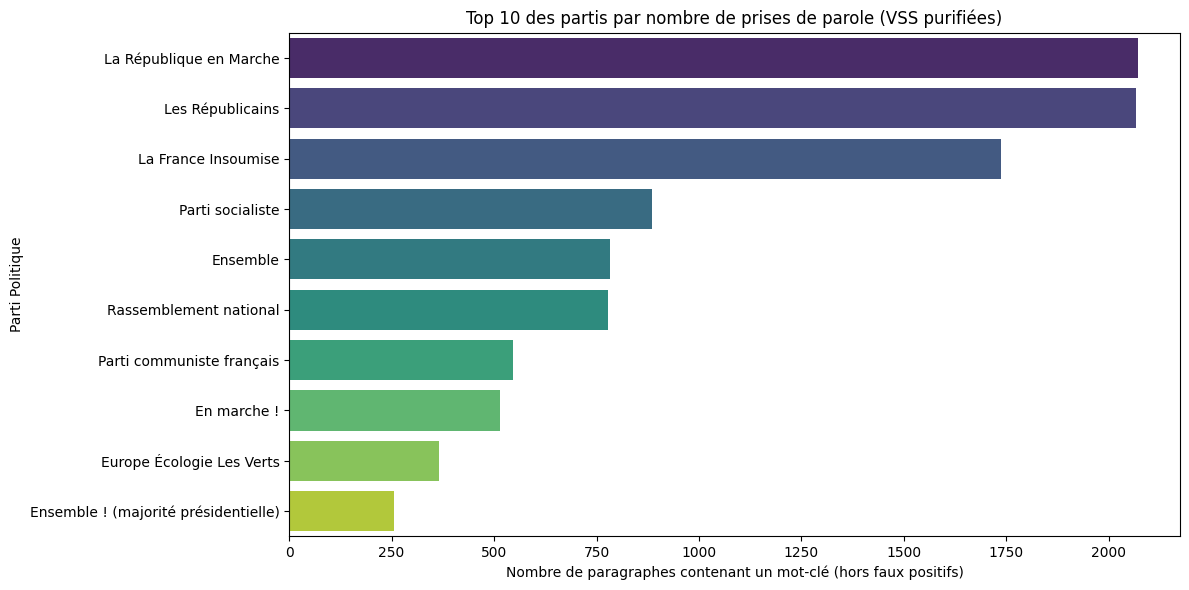

In [16]:
import matplotlib.pyplot as plt
import seaborn as sns

print("Génération du graphique...")

# Calcul du nombre de prises de parole par parti
vss_counts = df_vss['nom_parti'].value_counts().head(10) # Top 10 des partis

plt.figure(figsize=(12, 6))

# Correction du warning Seaborn : on ajoute hue=vss_counts.index et legend=False
sns.barplot(
    x=vss_counts.values, 
    y=vss_counts.index, 
    hue=vss_counts.index, 
    palette="viridis", 
    legend=False
)

plt.title("Top 10 des partis par nombre de prises de parole (VSS purifiées)")
plt.xlabel("Nombre de paragraphes contenant un mot-clé (hors faux positifs)")
plt.ylabel("Parti Politique")
plt.tight_layout()
plt.show()

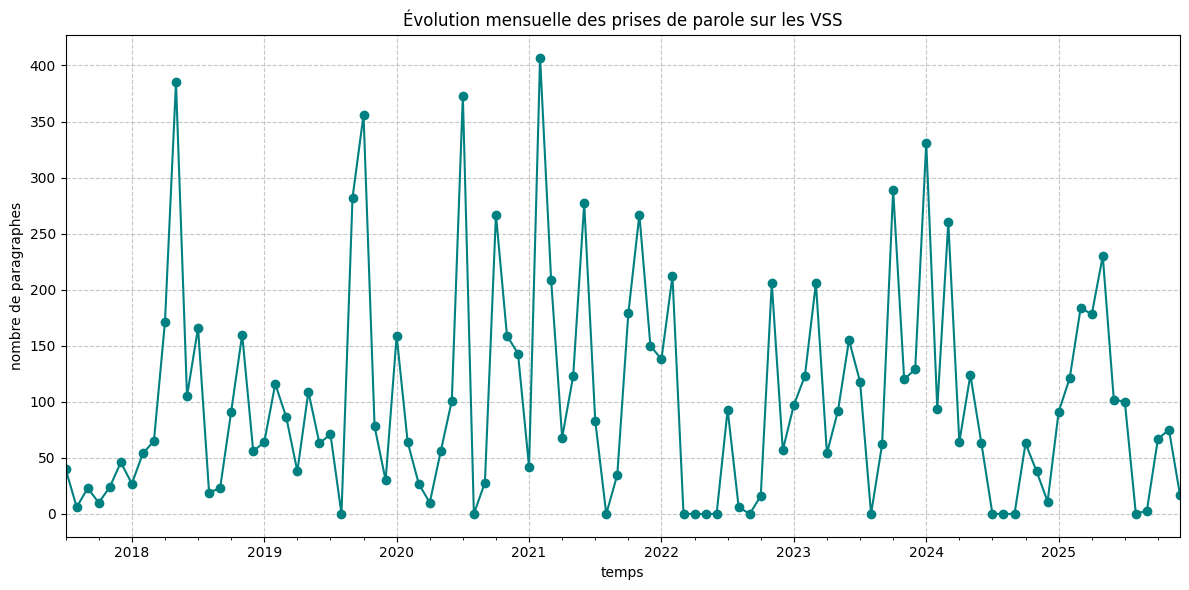

In [17]:
def tracer_evolution_vss(df):    
    ''' affiche le nombre de prises de parole par mois sur les vss '''
    
    # Correction du warning Pandas : 'ME' au lieu de 'M'
    evolution = df.resample('ME', on='date').size()
    
    # création du graphique
    plt.figure(figsize=(12, 6))
    evolution.plot(kind='line', marker='o', color='teal')
    plt.title("Évolution mensuelle des prises de parole sur les VSS")
    plt.xlabel("temps")
    plt.ylabel("nombre de paragraphes")
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()

tracer_evolution_vss(df_vss)

In [20]:
import torch
from transformers import BertTokenizer, BertModel

/opt/python/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


PIPELINE D'ANALYSE VSS – VERSION CAMEMBERT
✅ Chargement réussi : 10380 prises de parole trouvées.

VÉRIFICATION DES DONNÉES
Nombre de prises de parole dans df_vss : 10380
ATTENTION : Vous avez plus de 10 000 lignes. Le filtre négatif (impôts, etc.) n'a probablement pas été appliqué à ce tableau !

[1] Calcul des statistiques normalisées...

[3] Analyse du cadrage sémantique...
🔍 autour de 'féminicide' chez Les Républicains : femme, restera, primordiale, lors, permettraient
🔍 autour de 'féminicide' chez En marche ! : veut, connaître, hécatombe, conjugale, laisser
🔍 autour de 'féminicide' chez La République en Marche : victimes, notamment, article, décompte, morbide
🔍 autour de 'féminicide' chez La France Insoumise : commis, niche, parlementaire, hier, appris
🔍 autour de 'féminicide' chez Parti communiste français : accident, deux, mortel, prenions, toute
🔍 autour de 'féminicide' chez Rassemblement national : loin, catégorie, fourre
🔍 autour de 'féminicide' chez Parti socialiste : enfanc

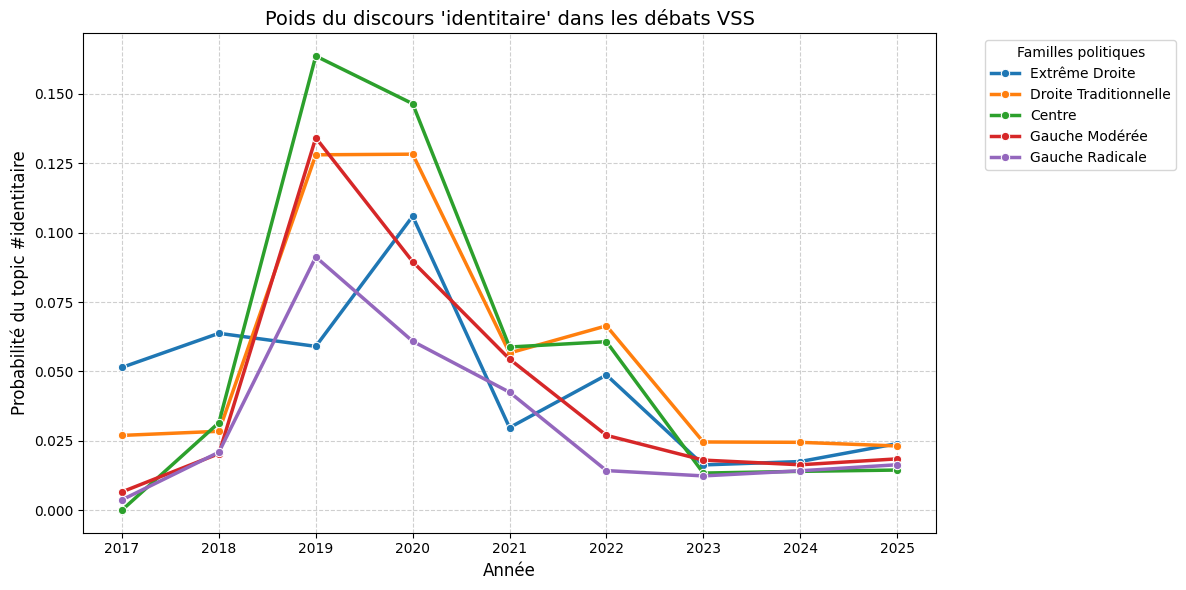


[8] Chargement de CamemBERT...


Loading weights: 100%|██████████| 199/199 [00:00<00:00, 582.55it/s, Materializing param=pooler.dense.weight]                               
CamembertModel LOAD REPORT from: camembert-base
Key                       | Status     |  | 
--------------------------+------------+--+-
lm_head.bias              | UNEXPECTED |  | 
lm_head.dense.bias        | UNEXPECTED |  | 
lm_head.layer_norm.bias   | UNEXPECTED |  | 
lm_head.layer_norm.weight | UNEXPECTED |  | 
lm_head.dense.weight      | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Encodage des prises de parole individuelles (ça va prendre un peu de temps)...


Encodage CamemBERT: 100%|██████████| 10315/10315 [51:31<00:00,  3.34it/s] 


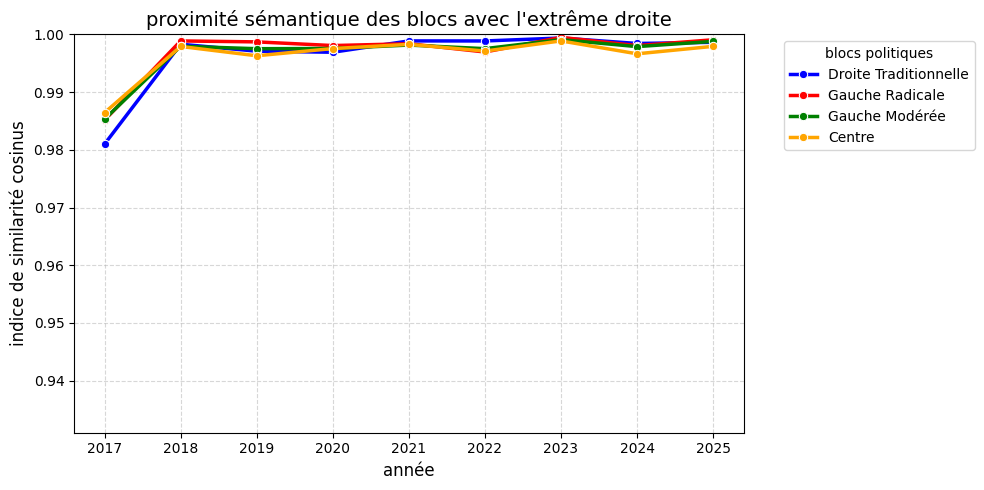


[9] Analyse du concept identitaire...


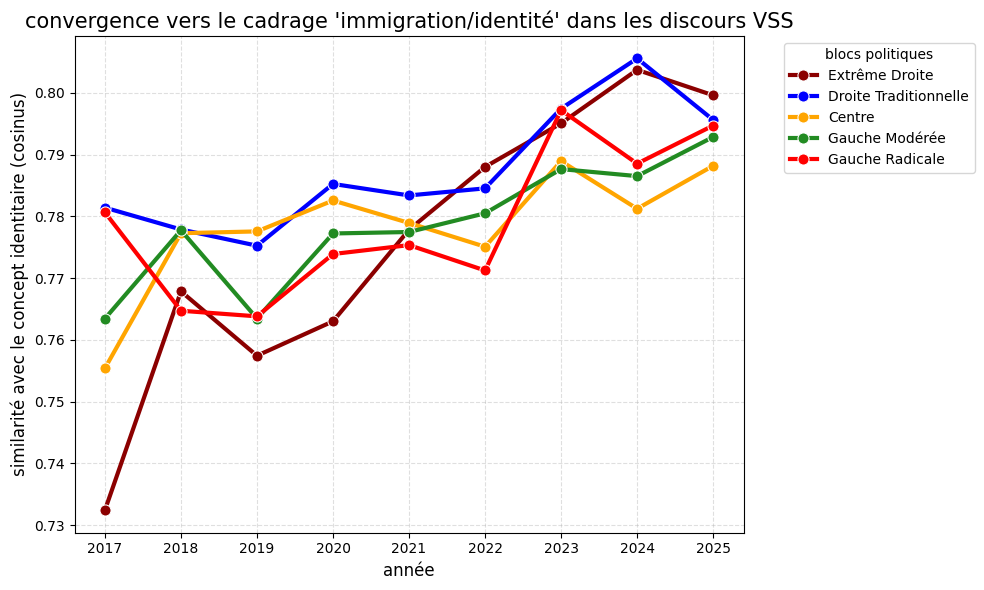


✅ Analyse terminée avec succès.


In [22]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
from collections import Counter
import os

# imports NLP
import nltk
from nltk.corpus import stopwords
from nltk.stem.snowball import FrenchStemmer

# imports gensim pour LDA et Word2Vec
from gensim import corpora, models
from gensim.models import Word2Vec
from sklearn.metrics.pairwise import cosine_similarity

# configuration
nltk.download('stopwords', quiet=True)
stemmer = FrenchStemmer()
stop_words_french = stopwords.words('french')

# mots-clés VSS (racines)
a_tester = [
    "viol", "sexis", "féminicide", "harcèl", "misogyn", 
    "sexuel", "machis", "égalité", "discrimin", "agress", "consent",
    "stéréotyp", "inégal", "domination", "patriarc", "genre", "quota",
    "lgbt", "transphobi", "homophobi", "non-binair", "mixité", "gynécolog",
    "avortement", "ivg", "contraception", "planning"
]

# ============================================================================
# PARTIE 1 : NORMALISATION DES STATISTIQUES
# ============================================================================

def calculer_stats_normalisees(df_global, df_vss):
    """
    Calcule les statistiques normalisées :
    - proportion de prises de parole VSS par parti
    - proportion de prises de parole VSS par période
    
    Arguments:
        df_global : DataFrame avec TOUTES les prises de parole
        df_vss : DataFrame avec UNIQUEMENT les prises de parole VSS
    
    Retourne:
        df_stats_partis : statistiques normalisées par parti
        df_stats_temps : statistiques normalisées par mois
    """
    
    # === NORMALISATION PAR PARTI ===
    # on compte le total de prises de parole par parti
    total_par_parti = df_global.groupby('nom_parti').size().reset_index(name='total_prises_parole')
    
    # on compte les prises de parole VSS par parti
    vss_par_parti = df_vss.groupby('nom_parti').size().reset_index(name='vss_prises_parole')
    
    # jointure et calcul de la proportion
    df_stats_partis = total_par_parti.merge(vss_par_parti, on='nom_parti', how='left')
    df_stats_partis['vss_prises_parole'] = df_stats_partis['vss_prises_parole'].fillna(0)
    df_stats_partis['proportion_vss'] = (
        df_stats_partis['vss_prises_parole'] / df_stats_partis['total_prises_parole'] * 100
    )
    
    # on trie par proportion décroissante
    df_stats_partis = df_stats_partis.sort_values('proportion_vss', ascending=False)
    
    # === NORMALISATION PAR PÉRIODE TEMPORELLE ===
    # on s'assure que la colonne date est au bon format
    df_global['date'] = pd.to_datetime(df_global['date'])
    df_vss['date'] = pd.to_datetime(df_vss['date'])
    
    # on crée une colonne année-mois
    df_global['periode'] = df_global['date'].dt.to_period('M')
    df_vss['periode'] = df_vss['date'].dt.to_period('M')
    
    # total de prises de parole par mois (toutes thématiques confondues)
    total_par_mois = df_global.groupby('periode').size().reset_index(name='total_prises_parole')
    
    # prises de parole VSS par mois
    vss_par_mois = df_vss.groupby('periode').size().reset_index(name='vss_prises_parole')
    
    # jointure et calcul de la proportion
    df_stats_temps = total_par_mois.merge(vss_par_mois, on='periode', how='left')
    df_stats_temps['vss_prises_parole'] = df_stats_temps['vss_prises_parole'].fillna(0)
    df_stats_temps['proportion_vss'] = (
        df_stats_temps['vss_prises_parole'] / df_stats_temps['total_prises_parole'] * 100
    )
    
    # conversion de la période en datetime pour les graphiques
    df_stats_temps['date'] = df_stats_temps['periode'].dt.to_timestamp()
    
    return df_stats_partis, df_stats_temps


def sauvegarder_documents_par_parti(df_vss, output_dir="/home/onyxia/work/projet_eco_socio/analyses_par_partis/"):
    """
    Sauvegarde les prises de parole VSS dans des fichiers texte par parti.
    """
    os.makedirs(output_dir, exist_ok=True)
    
    for parti, group in df_vss.groupby("nom_parti"):
        # nettoyage du nom du parti pour le nom de fichier
        nom_propre = "".join(x for x in parti if x.isalnum() or x in "._- ").strip()
        
        with open(f"{output_dir}{nom_propre}.txt", "w", encoding="utf-8") as f:
            for discours in group["texte"]:
                f.write(discours + "\n\n---\n\n")
    
    print(f"Documents créés pour {len(df_vss['nom_parti'].unique())} partis.")


# ============================================================================
# PARTIE 2 : VISUALISATIONS NORMALISÉES
# ============================================================================

def tracer_top_partis_normalise(df_stats_partis, top_n=10):
    """
    Graphique en barres : proportion de prises de parole VSS par parti (Top N).
    """
    # on ne garde que les top N
    data_plot = df_stats_partis.head(top_n)
    
    plt.figure(figsize=(12, 6))
    sns.barplot(
        data=data_plot, 
        x='proportion_vss', 
        y='nom_parti', 
        palette="viridis",
        hue='nom_parti',
        legend=False
    )
    plt.title(f"Top {top_n} des partis par proportion de prises de parole VSS", fontsize=14)
    plt.xlabel("pourcentage de prises de parole sur les VSS (%)", fontsize=12)
    plt.ylabel("parti politique", fontsize=12)
    
    # ajout des valeurs sur les barres
    for i, row in enumerate(data_plot.itertuples()):
        plt.text(
            row.proportion_vss + 0.1, 
            i, 
            f"{row.proportion_vss:.1f}% ({int(row.vss_prises_parole)}/{int(row.total_prises_parole)})",
            va='center',
            fontsize=9
        )
    
    plt.tight_layout()
    plt.show()


def tracer_evolution_mensuelle_normalise(df_stats_temps):
    """
    Courbe : évolution mensuelle de la proportion de prises de parole VSS.
    """
    plt.figure(figsize=(14, 6))
    plt.plot(df_stats_temps['date'], df_stats_temps['proportion_vss'], 
             marker='o', color='teal', linewidth=2, markersize=4)
    
    plt.title("évolution de la proportion de débats consacrés aux VSS (2017-2025)", fontsize=14)
    plt.xlabel("temps", fontsize=12)
    plt.ylabel("pourcentage de prises de parole sur les VSS (%)", fontsize=12)
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.tight_layout()
    plt.show()


def tracer_heatmap_mots_cles(df_vss, a_tester, seuil_min=10):
    """
    Heatmap : répartition des mots-clés VSS par parti (normalisée ou brute).
    Note : cette visualisation reste en valeurs brutes car elle montre la 
    distribution des thématiques, pas le volume global.
    """
    # on crée une colonne pour chaque mot-clé
    for mot in a_tester:
        pattern = rf'\b{re.escape(mot.lower())}'
        df_vss[mot] = df_vss['texte'].str.contains(pattern, case=False, na=False, regex=True)
    
    # on regroupe par parti et on fait la somme des détections
    heatmap_data = df_vss.groupby('nom_parti')[a_tester].sum()
    
    # on ne garde que les partis avec un minimum de mentions
    heatmap_data = heatmap_data[heatmap_data.sum(axis=1) > seuil_min]
    
    plt.figure(figsize=(16, 10))
    sns.heatmap(heatmap_data, annot=True, cmap="YlGnBu", fmt='g', cbar_kws={'label': 'nombre de mentions'})
    plt.title("répartition des mots-clés VSS par parti politique", fontsize=14)
    plt.xlabel("mots-clés", fontsize=12)
    plt.ylabel("parti politique", fontsize=12)
    plt.tight_layout()
    plt.show()


# ============================================================================
# PARTIE 3 : ANALYSE SÉMANTIQUE (CADRAGE)
# ============================================================================

def analyser_cadrage_mot(df, mot_cible, stop_words):
    """
    Analyse les mots co-occurrents autour d'un concept clé.
    Fenêtre de ±10 mots.
    """
    resultats = {}
    
    for parti in df['nom_parti'].unique():
        if pd.isna(parti): 
            continue
            
        textes_parti = df[df['nom_parti'] == parti]['texte'].str.lower().tolist()
        mots_autour = []
        
        for t in textes_parti:
            segments = re.split(r'\W+', t)
            if mot_cible in segments:
                idx = segments.index(mot_cible)
                fenetre = segments[max(0, idx-10):idx] + segments[idx+1:idx+11]
                mots_autour.extend([m for m in fenetre if m not in stop_words and len(m) > 3])
        
        if mots_autour:
            top_mots = [m for m, c in Counter(mots_autour).most_common(5)]
            resultats[parti] = top_mots
            
    for parti, mots in resultats.items():
        print(f"🔍 autour de '{mot_cible}' chez {parti} : {', '.join(mots)}")


def enrichir_stopwords():
    """
    Enrichit la liste de stop words avec le bruit parlementaire et les résidus de faux positifs.
    """
    mots_a_exclure = [
        # Mots de liaison et verbes très communs
        "plus", "cette", "faire", "tout", "être", "bien", "comme", "aussi", 
        "fait", "tous", "entre", "leurs", "ceux", "celles", "sans", "dire",
        "ils", "elles", "sous", "vers", "notre", "votre", "leurs", "dont", "puis",
        "franc", "enfant", "depuis", "longtemps", "encore", "afin", "année",
        "cet", "cel", "donc", "quelqu", "vis", "très",
        
        # Le jargon procédural de l'Assemblée (qui pourrissait ta LDA)
        "loi", "droit", "état", "amend", "articl", "text", "group", "autr", 
        "person", "social", "polit", "publi", "premier", "monsieur", 
        "madame", "président", "ministre", "député", "collègue", "assemblée",
        "proposit", "disposit", "cadre", "mesur", "moyen", "question", "rapport",
        "commission", "gouvern", "souhait", "permettr", "faut", "doit", "peut",
        "banc", "applaud", "adopt", "propos", "vot", "séanc", "parol",
        
        # Sigles des partis (inutiles en thématique)
        "lfi", "nup", "nfp", "rn", "lr", "em", "rennaiss",
        
        # L'économie et le fiscal (pour achever les restes du consentement à l'impôt)
        "fiscal", "financ", "euro", "euros", "milliard", "million", "budget", "compt"
    ]
    
    stop_words_french.extend(mots_a_exclure)
    return stop_words_french


# ============================================================================
# PARTIE 4 : AGRÉGATION TEMPORELLE ET TOPIC MODELING
# ============================================================================

def agreger_discours(df, granularite='Y'):
    """
    Agrège les textes par parti et période temporelle.
    granularite : 'Y' (année), 'M' (mois), 'Q' (trimestre)
    """
    df['date'] = pd.to_datetime(df['date'])
    df['periode'] = df['date'].dt.to_period(granularite).astype(str)
    
    df_docs = df.groupby(['nom_parti', 'periode'])['texte'].apply(lambda x: ' '.join(x)).reset_index()
    
    return df_docs


def pre_processing_recherche(texte, stop_words, mots_vss):
    """
    Nettoie le texte, stemme, et retire les mots-clés VSS pour éviter le biais.
    """
    # mise en minuscule et retrait de la ponctuation
    texte = re.sub(r'\W+', ' ', texte.lower())
    
    # tokenization
    mots = texte.split()
    
    # filtrage avec stemming
    mots_nettoyes = [
        stemmer.stem(m) for m in mots 
        if m not in stop_words 
        and not any(vss in m for vss in mots_vss)
        and len(m) > 2
    ]
    
    return " ".join(mots_nettoyes)


def preparer_corpus_lda(df_clean):
    """
    Transforme les textes au niveau de chaque prise de parole.
    """
    # On travaille directement sur df_vss (ou df_blocs au niveau discours)
    textes = [str(doc).split() for doc in df_clean['texte_clean'] if str(doc).strip() != ""]
    
    dictionnaire = corpora.Dictionary(textes)
    # Filtrage moins agressif pour capter les signaux faibles (identitaires)
    dictionnaire.filter_extremes(no_below=5, no_above=0.4)
    
    corpus = [dictionnaire.doc2bow(text) for text in textes]
    
    return dictionnaire, corpus


def entrainer_lda_final(corpus, dictionnaire, num_topics=5):
    """
    Entraîne le modèle LDA pour identifier les thématiques.
    """
    model = models.LdaModel(
        corpus=corpus, 
        id2word=dictionnaire, 
        num_topics=num_topics, 
        passes=20, 
        random_state=42
    )
    return model


def afficher_topics(lda_model):
    """
    Affiche les mots-clés de chaque topic découvert.
    """
    for i, topic in lda_model.print_topics(-1):
        print(f"thématique #{i}: {topic}")


def filtrer_docs_vides(df):
    """
    Supprime les lignes où le texte nettoyé est vide.
    """
    df_clean = df[df['texte_clean'].str.strip() != ""].copy()
    return df_clean


# ============================================================================
# PARTIE 5 : REGROUPEMENT EN BLOCS IDÉOLOGIQUES
# ============================================================================

def regrouper_blocs_ideologiques(nom_parti):
    """
    Associe chaque parti à un bloc idéologique.
    """
    nom = str(nom_parti).lower()
    
    # extrême droite
    if "rassemblement national" in nom or "front national" in nom or "udr" in nom:
        return "Extrême Droite"
    
    # droite traditionnelle
    if "républicains" in nom:
        return "Droite Traditionnelle"
    
    # centre (majorité présidentielle)
    centre = ["en marche", "république en marche", "renaissance", "ensemble", "modem", "mouvement démocrate", "horizons"]
    if any(c in nom for c in centre):
        return "Centre"
    
    # gauche modérée
    gauche_m = ["socialiste", "écologistes - eelv", "europe écologie les verts", "radical de gauche"]
    if any(g in nom for g in gauche_m):
        return "Gauche Modérée"
    
    # gauche radicale
    gauche_r = ["france insoumise", "communiste", "lfi"]
    if any(g in nom for g in gauche_r):
        return "Gauche Radicale"
    
    return None


# ============================================================================
# PARTIE 6 : ANALYSE DE CONVERGENCE (LDA)
# ============================================================================

def extraire_poids_topic_specifique(lda_model, corpus, df_original, target_topic):
    """
    Extrait le poids d'un topic pour chaque discours, puis on pourra moyenner par année.
    """
    poids_topic = []
    
    for bow in corpus:
        if not bow:
            poids_topic.append(0)
            continue
        distribution = lda_model.get_document_topics(bow)
        prob = dict(distribution).get(target_topic, 0)
        poids_topic.append(prob)
    
    df_res = df_original.copy()
    df_res['poids_identitaire'] = poids_topic
    
    # Agrégation a posteriori pour le graphique
    df_res['date'] = pd.to_datetime(df_res['date'])
    df_res['annee'] = df_res['date'].dt.to_period('Y').astype(str)
    
    # Moyenne du poids du topic par bloc et par an
    df_evolution = df_res.groupby(['annee', 'bloc'])['poids_identitaire'].mean().reset_index()
    return df_evolution


def tracer_convergence_lda(df, topic_name="identitaire"):
    """
    Compare l'évolution d'un topic entre blocs idéologiques.
    """
    ordre_blocs = ["Extrême Droite", "Droite Traditionnelle", "Centre", "Gauche Modérée", "Gauche Radicale"]
    
    plt.figure(figsize=(12, 6))
    sns.lineplot(
        data=df, 
        x='annee', 
        y='poids_identitaire', 
        hue='bloc', 
        hue_order=ordre_blocs, 
        marker='o', 
        linewidth=2.5
    )
    
    plt.title(f"Poids du discours '{topic_name}' dans les débats VSS", fontsize=14)
    plt.ylabel(f"Probabilité du topic #{topic_name}", fontsize=12)
    plt.xlabel("Année", fontsize=12)
    plt.legend(title="Familles politiques", bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.tight_layout()
    plt.show()


# ============================================================================
# PARTIE 7 : SIMILARITÉ COSINUS (WORD2VEC)
# ============================================================================

import torch
from transformers import CamembertTokenizer, CamembertModel
import numpy as np
from tqdm import tqdm

class CamembertEmbedding:
    def __init__(self, device=None):
        self.device = device if device else ("cuda" if torch.cuda.is_available() else "cpu")
        
        self.tokenizer = CamembertTokenizer.from_pretrained("camembert-base")
        self.model = CamembertModel.from_pretrained("camembert-base").to(self.device)
        self.model.eval()

    def encode(self, texte):
        inputs = self.tokenizer(
            str(texte),
            return_tensors="pt",
            truncation=True,
            padding=True,
            max_length=512
        ).to(self.device)

        with torch.no_grad():
            outputs = self.model(**inputs)

        # vecteur CLS (dimension 768)
        embedding = outputs.last_hidden_state[:, 0, :].squeeze().cpu().numpy()
        return embedding

def calculer_vecteur_moyen(texte, model):
    """
    Retourne le vecteur CamemBERT d'un texte.
    """
    if not texte or str(texte).strip() == "":
        return np.zeros(768)  # dimension camembert-base
    
    return model.encode(texte)
    

from sklearn.metrics.pairwise import cosine_similarity
import pandas as pd

def analyser_contagion_cosinus(df, model):
    """
    Compare chaque bloc à l'extrême droite année par année.
    Calcul des centroïdes au lieu de tronquer un texte géant.
    """
    # 1. Encodage de chaque discours individuellement (sur le texte BRUT, pas clean)
    # Tqdm pour voir l'avancement, car ça peut prendre un peu de temps
    tqdm.pandas(desc="Encodage CamemBERT")
    df['vecteur'] = df['texte'].progress_apply(lambda x: calculer_vecteur_moyen(x, model))
    
    # 2. Création de l'année
    df['date'] = pd.to_datetime(df['date'])
    df['annee'] = df['date'].dt.to_period('Y').astype(str)
    
    resultats = []
    
    for annee in sorted(df['annee'].unique()):
        df_an = df[df['annee'] == annee]
        
        if "Extrême Droite" in df_an['bloc'].values:
            # Calcul du centroïde (vecteur moyen) de l'Extrême Droite pour cette année
            vecteurs_ed = np.vstack(df_an[df_an['bloc'] == "Extrême Droite"]['vecteur'].values)
            centroid_ed = np.mean(vecteurs_ed, axis=0)
            
            for bloc in df_an['bloc'].unique():
                if bloc == "Extrême Droite":
                    continue
                
                # Centroïde du bloc cible
                vecteurs_cible = np.vstack(df_an[df_an['bloc'] == bloc]['vecteur'].values)
                centroid_cible = np.mean(vecteurs_cible, axis=0)
                
                sim = cosine_similarity([centroid_ed], [centroid_cible])[0][0]
                
                resultats.append({
                    'annee': annee,
                    'bloc': bloc,
                    'similarite': sim
                })
    
    return pd.DataFrame(resultats)

def tracer_graphique_similarite(df):
    """
    Graphique de proximité sémantique avec l'extrême droite.
    """
    if df.empty:
        print("le tableau de similarité est vide.")
        return

    plt.figure(figsize=(10, 5))
    
    palette_couleurs = {
        "Droite Traditionnelle": "blue",
        "Centre": "orange",
        "Gauche Modérée": "green",
        "Gauche Radicale": "red"
    }

    sns.lineplot(
        data=df, 
        x='annee', 
        y='similarite', 
        hue='bloc', 
        palette=palette_couleurs, 
        marker='o', 
        linewidth=2.5
    )

    plt.title("proximité sémantique des blocs avec l'extrême droite", fontsize=14)
    plt.ylabel("indice de similarité cosinus", fontsize=12)
    plt.xlabel("année", fontsize=12)
    plt.legend(title="blocs politiques", bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.ylim(df['similarite'].min() - 0.05, 1.0)
    plt.tight_layout()
    plt.show()


# ============================================================================
# PARTIE 8 : ANALYSE CIBLÉE (CONCEPT IDENTITAIRE)
# ============================================================================

def creer_vecteur_concept(model, mots_clefs):
    """
    Crée un vecteur conceptuel via CamemBERT
    en encodant les mots clés ensemble.
    """
    phrase = " ".join(mots_clefs)
    return model.encode(phrase)

def filtrage_strict_intersection(df, liste_vss, liste_identitaire):
    """
    Ne garde que les paragraphes où VSS ET identité se croisent.
    """
    pattern_vss = '|'.join(liste_vss)
    pattern_id = '|'.join(liste_identitaire)
    
    mask = (df['texte'].str.contains(pattern_vss, case=False, na=False)) & \
           (df['texte'].str.contains(pattern_id, case=False, na=False))
    
    return df[mask].copy()


def mesurer_derive_vers_concept(df, model, vecteur_ref):
    """
    Similarité moyenne de chaque bloc par rapport au concept identitaire.
    """
    df['date'] = pd.to_datetime(df['date'])
    df['annee'] = df['date'].dt.to_period('Y').astype(str)
    
    # Distance de chaque discours au vecteur concept
    df['proximite_identitaire'] = df['vecteur'].apply(
        lambda x: cosine_similarity([x], [vecteur_ref])[0][0]
    )
    
    # Moyenne par bloc et par an
    df_derive = df.groupby(['annee', 'bloc'])['proximite_identitaire'].mean().reset_index()
    return df_derive

def tracer_derive_concept_identitaire(df):
    """
    Graphique de convergence vers le concept immigration/identité.
    """
    df = df.sort_values('annee')
    
    plt.figure(figsize=(10, 6))
    
    couleurs = {
        "Extrême Droite": "#8B0000",
        "Droite Traditionnelle": "#0000FF",
        "Centre": "#FFA500",
        "Gauche Modérée": "#228B22",
        "Gauche Radicale": "#FF0000"
    }
    
    ordre = ["Extrême Droite", "Droite Traditionnelle", "Centre", "Gauche Modérée", "Gauche Radicale"]

    sns.lineplot(
        data=df, 
        x='annee', 
        y='proximite_identitaire', 
        hue='bloc', 
        hue_order=ordre, 
        palette=couleurs, 
        marker='o', 
        linewidth=3, 
        markersize=8
    )

    plt.title("convergence vers le cadrage 'immigration/identité' dans les discours VSS", fontsize=15)
    plt.ylabel("similarité avec le concept identitaire (cosinus)", fontsize=12)
    plt.xlabel("année", fontsize=12)
    plt.legend(title="blocs politiques", bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.grid(True, linestyle='--', alpha=0.4)
    plt.tight_layout()
    plt.show()



if __name__ == "__main__":
    print("="*80)
    print("PIPELINE D'ANALYSE VSS – VERSION CAMEMBERT")
    print("="*80)

    # === CHARGEMENT FORCÉ DES DONNÉES PROPRES ===
    chemin_propre = "/home/onyxia/work/projet_eco_socio/df_vss_propre.pkl"
    
    if os.path.exists(chemin_propre):
        df_vss = pd.read_pickle(chemin_propre)
        print(f"✅ Chargement réussi : {len(df_vss)} prises de parole trouvées.")
    else:
        print("ERREUR : Le fichier df_vss_propre n'existe pas. Relancez la cellule 1 !")
        # On arrête tout si on n'a pas la bonne donnée
        exit()

    # --- NOUVEAU : VÉRIFICATION DU VOLUME ---
    print("\nVÉRIFICATION DES DONNÉES")
    print(f"Nombre de prises de parole dans df_vss : {len(df_vss)}")
    if len(df_vss) > 10000:
        print("ATTENTION : Vous avez plus de 10 000 lignes. Le filtre négatif (impôts, etc.) n'a probablement pas été appliqué à ce tableau !")
    print("="*80)

    # ============================================================
    # 1️⃣ STATISTIQUES NORMALISÉES
    # ============================================================

    print("\n[1] Calcul des statistiques normalisées...")
    df_stats_partis, df_stats_temps = calculer_stats_normalisees(df_global, df_vss)

    # ============================================================
    # 2️⃣ VISUALISATIONS
    # ============================================================

    #print("\n[2] Génération des graphiques normalisés...")
    #tracer_top_partis_normalise(df_stats_partis, top_n=43)
    #tracer_evolution_mensuelle_normalise(df_stats_temps)
    #tracer_heatmap_mots_cles(df_vss, a_tester)

    # ============================================================
    # 3️⃣ ANALYSE DE CADRAGE
    # ============================================================

    print("\n[3] Analyse du cadrage sémantique...")
    stop_words_enrichis = enrichir_stopwords()
    analyser_cadrage_mot(df_vss, "féminicide", stop_words_enrichis)

    # ============================================================
    # 4️⃣ NETTOYAGE (SANS AGRÉGATION)
    # ============================================================

    print("\n[4] Nettoyage des textes individuels...")
    # On travaille directement sur df_vss
    df_vss['texte_clean'] = df_vss['texte'].apply(
        lambda x: pre_processing_recherche(x, stop_words_enrichis, a_tester)
    )

    df_vss = filtrer_docs_vides(df_vss)

    # ============================================================
    # 5️⃣ BLOCS IDÉOLOGIQUES
    # ============================================================

    print("\n[5] Création des blocs idéologiques...")
    df_vss['bloc'] = df_vss['nom_parti'].apply(regrouper_blocs_ideologiques)
    
    df_blocs = df_vss.dropna(subset=['bloc']).copy()

   # ============================================================
    # 6️⃣ LDA (AU NIVEAU DES DISCOURS)
    # ============================================================

    print("\n[6] Entraînement du modèle LDA (15 thématiques)...")
    dictionnaire, corpus = preparer_corpus_lda(df_blocs)
    
    # On passe à 15 topics pour affiner la recherche
    lda = entrainer_lda_final(corpus, dictionnaire, num_topics=15)
    afficher_topics(lda)

    # ============================================================
    # 7️⃣ ANALYSE LDA
    # ============================================================

    topic_identitaire = 13

    print(f"\n[7] Extraction des poids pour le topic #{topic_identitaire}...")
    df_evolution = extraire_poids_topic_specifique(
        lda, corpus, df_blocs, target_topic=topic_identitaire
    )

    tracer_convergence_lda(df_evolution, topic_name="identitaire")

    # ============================================================
    # 8️⃣ CAMEMBERT – SIMILARITÉ ENTRE BLOCS
    # ============================================================

    print("\n[8] Chargement de CamemBERT...")
    model_camembert = CamembertEmbedding()

    print("Encodage des prises de parole individuelles (ça va prendre un peu de temps)...")
    # On passe le df_blocs brut, la fonction modifiée va calculer les centroïdes
    df_sim = analyser_contagion_cosinus(df_blocs, model_camembert)
    tracer_graphique_similarite(df_sim)

    # ============================================================
    # 9️⃣ CONCEPT CIBLÉ – IMMIGRATION / IDENTITÉ
    # ============================================================

    print("\n[9] Analyse du concept identitaire...")

    mots_identitaires = [
        "immigration", "clandestin", "frontière",
        "national", "identité", "culture",
        "étranger", "expulsion", "valeurs", "OQTF", "territoire"
    ]

    vecteur_ref = creer_vecteur_concept(model_camembert, mots_identitaires)

 
    df_derive = mesurer_derive_vers_concept(
        df_blocs,
        model_camembert,
        vecteur_ref
    )

    tracer_derive_concept_identitaire(df_derive)

    print("\n✅ Analyse terminée avec succès.")

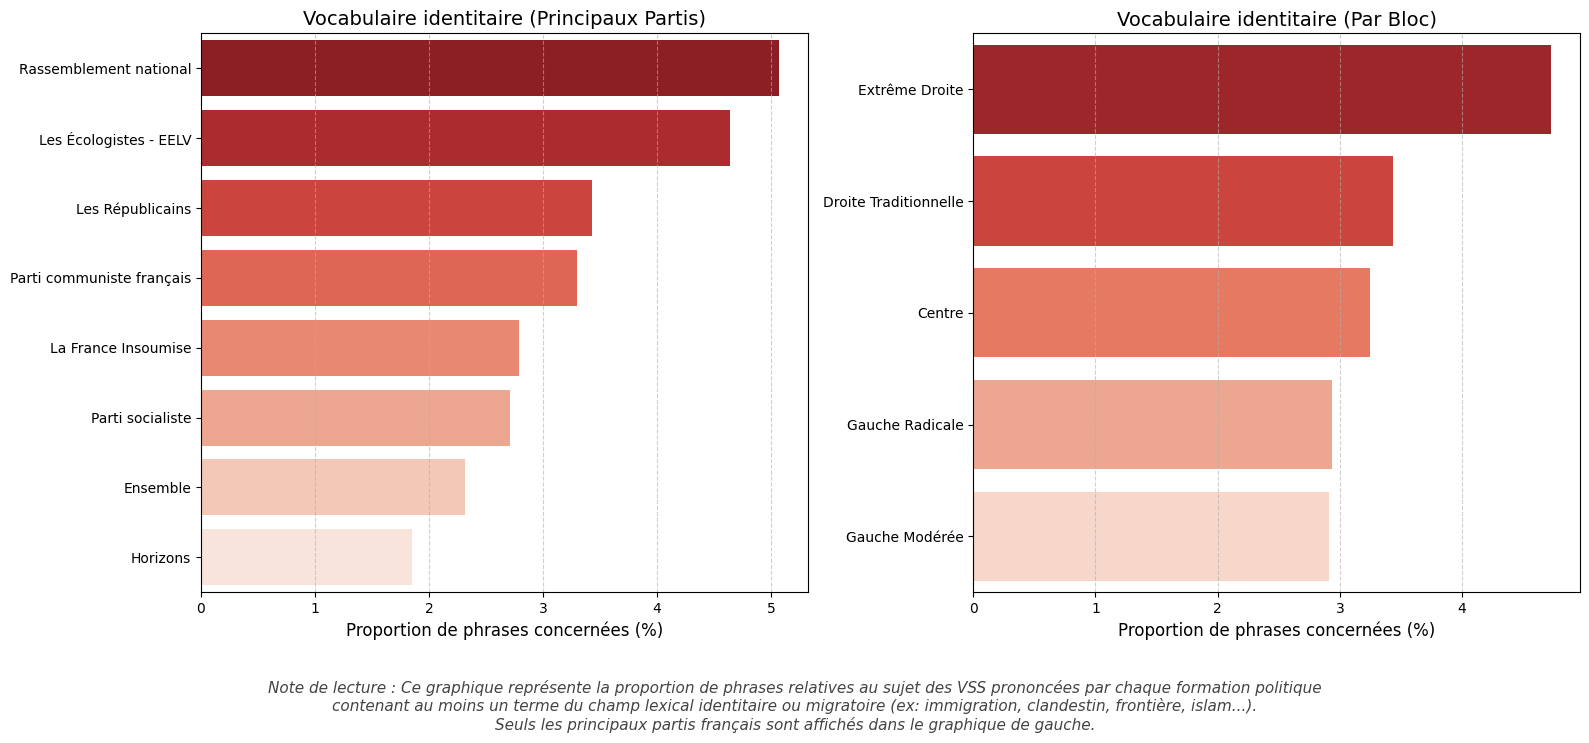

In [23]:
import re
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

def tracer_pourcentages_identitaires(df_vss):
    """
    Calcule et affiche le pourcentage de phrases contenant du vocabulaire identitaire 
    pour les principaux partis et par bloc idéologique.
    """
    
    mots_identitaires = [
        "immigration", "frontière",
        "clandestin", "identité",
        "étranger", "expulsion", "oqtf", "territoire", "illégal", "illégaux", "confession", "islam"
    ]
    
    pattern = re.compile(r'(?i)\b(' + '|'.join(mots_identitaires) + r')\w*\b')
    df = df_vss.copy()
    df['texte'] = df['texte'].fillna('').astype(str)
    
    # --- 1. DÉCOUPAGE EN PHRASES ---
    df['phrases'] = df['texte'].str.split(r'[.!?]+')
    df['phrases'] = df['phrases'].apply(lambda liste: [p.strip() for p in liste if p.strip()])
    
    # --- 2. COMPTAGES PAR LIGNE ---
    df['total_phrases'] = df['phrases'].str.len()
    df['phrases_avec_mot'] = df['phrases'].apply(
        lambda phrases: sum(1 for p in phrases if pattern.search(p))
    )
    
    # --- 3. FILTRE DES PARTIS PRINCIPAUX ---
    # 
    partis_principaux = [
        'RN', 'Rassemblement national', 
        'LFI', 'La France Insoumise', 
        'RE', 'Renaissance', 'Ensemble', "En marche!"
        'LR', 'Les Républicains', 
        'PS', 'Parti socialiste', 
        'LE', 'Les Écologistes - EELV', 'EELV', 
        'PCF', 'Parti communiste français', 
        'MoDem', 'Horizons'
    ]
    
    # --- 4. AGRÉGATION ET POURCENTAGES ---
    
    # Agrégation par Parti
    agg_parti = df.groupby('nom_parti')[['phrases_avec_mot', 'total_phrases']].sum()
    agg_parti['pourcentage'] = (agg_parti['phrases_avec_mot'] / agg_parti['total_phrases'] * 100).fillna(0)
    counts_parti = agg_parti['pourcentage'].sort_values(ascending=False)
    
    # On applique le filtre ici : on ne garde que les partis de notre liste qui ont au moins 1% (ou >0)
    counts_parti = counts_parti[counts_parti.index.isin(partis_principaux) & (counts_parti > 0)]
    
    # Agrégation par Bloc (On garde tout le monde pour l'analyse par bloc)
    agg_bloc = df.groupby('bloc')[['phrases_avec_mot', 'total_phrases']].sum()
    agg_bloc['pourcentage'] = (agg_bloc['phrases_avec_mot'] / agg_bloc['total_phrases'] * 100).fillna(0)
    counts_bloc = agg_bloc['pourcentage'].sort_values(ascending=False)
    counts_bloc = counts_bloc[counts_bloc > 0]
    
    # --- 5. CRÉATION DES GRAPHIQUES ---
    fig, axes = plt.subplots(1, 2, figsize=(16, 7.5)) # Hauteur légèrement augmentée pour la note
    
    # Graphique 1 : Par Parti
    sns.barplot(
        x=counts_parti.values, 
        y=counts_parti.index, 
        ax=axes[0], 
        hue=counts_parti.index, 
        palette="Reds_r", 
        legend=False
    )
    axes[0].set_title("Vocabulaire identitaire (Principaux Partis)", fontsize=14)
    axes[0].set_xlabel("Proportion de phrases concernées (%)", fontsize=12)
    axes[0].set_ylabel("")
    axes[0].grid(axis='x', linestyle='--', alpha=0.6)
    
    # Graphique 2 : Par Bloc
    sns.barplot(
        x=counts_bloc.values, 
        y=counts_bloc.index, 
        ax=axes[1], 
        hue=counts_bloc.index, 
        palette="Reds_r", 
        legend=False
    )
    axes[1].set_title("Vocabulaire identitaire (Par Bloc)", fontsize=14)
    axes[1].set_xlabel("Proportion de phrases concernées (%)", fontsize=12)
    axes[1].set_ylabel("")
    axes[1].grid(axis='x', linestyle='--', alpha=0.6)
    
    # --- AJOUT DE LA NOTE EXPLICATIVE ---
    texte_note = (
        "Note de lecture : Ce graphique représente la proportion de phrases relatives au sujet des VSS prononcées par chaque formation politique\n"
        "contenant au moins un terme du champ lexical identitaire ou migratoire (ex: immigration, clandestin, frontière, islam...).\n"
        "Seuls les principaux partis français sont affichés dans le graphique de gauche."
    )
    
    # Placement de la note en bas au centre
    fig.text(0.5, 0.02, texte_note, ha="center", fontsize=11, style='italic', color='#444444')
    
    # On ajuste le layout pour laisser de la place à la note (le 'bottom=0.12' remonte les graphiques)
    plt.tight_layout(rect=[0, 0.12, 1, 1])
    plt.show()

# Lancement de la fonction
tracer_pourcentages_identitaires(df_vss)

In [24]:
pip install openai tqdm

Note: you may need to restart the kernel to use updated packages.


In [25]:

pip install google-genai

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 724.4/724.4 kB 55.7 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2/2 [google-genai] [google-genai]
Note: you may need to restart the kernel to use updated packages.


In [26]:
import os
import requests
import time
import urllib3
from tqdm import tqdm

# Désactiver l'avertissement SSL lié au "verify=False"
urllib3.disable_warnings(urllib3.exceptions.InsecureRequestWarning)

URL_OLLAMA = "https://ollama-api.lab.groupe-genes.fr/api/chat"

def appeler_llm(prompt, role_systeme, max_retries=5):
    payload = {
        "model": "mistral",
        "messages": [
            {"role": "system", "content": role_systeme},
            {"role": "user", "content": prompt}
        ],
        "stream": False,
        "options": {
            "temperature": 0.0
        }
    }

    for attempt in range(max_retries):
        try:
            r = requests.post(URL_OLLAMA, json=payload, timeout=180, verify=False)
            r.raise_for_status() 
            return r.json()["message"]["content"]
            
        except requests.exceptions.HTTPError as e:
            if e.response.status_code == 504:
                print(f"\n⏳ Le serveur de l'école sature (504 Timeout). On le laisse souffler 60s (Tentative {attempt + 1}/{max_retries})...")
                time.sleep(60)
            else:
                print(f"\n⚠️ Erreur HTTP du serveur ENSAE ({e.response.status_code}). Nouvelle tentative dans 15s...")
                time.sleep(15)
                
        except requests.exceptions.RequestException as e:
            print(f"\n⚠️ Erreur de connexion ({e}). Nouvelle tentative dans 15s (Tentative {attempt + 1}/{max_retries})...")
            time.sleep(15)
            
        except ValueError:
            print(f"\n⚠️ Le serveur n'a pas renvoyé du texte lisible. Nouvelle tentative dans 15s...")
            time.sleep(15)
            
    print("\n❌ Échec définitif pour ce morceau après de multiples tentatives. On le saute.")
    return ""

def decouper_textes(textes, max_mots=1200):
    mots = " ".join(textes).split()
    chunks = []
    for i in range(0, len(mots), max_mots):
        chunks.append(" ".join(mots[i:i + max_mots]))
    return chunks

def generer_synthese_bloc(df_vss, nom_bloc):
    print(f"\n⚙️ Lancement de la synthèse pour le bloc : {nom_bloc}...")
    
    discours_bloc = df_vss[df_vss['bloc'] == nom_bloc]['texte'].tolist()
    if not discours_bloc:
        return "Aucun discours trouvé pour ce bloc."
    
    chunks = decouper_textes(discours_bloc, max_mots=1200)
    print(f"   -> {len(chunks)} sous-parties à analyser (Map).")
    
    prompt_systeme_map = (
        "Tu es un chercheur en sociologie politique neutre et rigoureux. "
        "Ta mission est de synthétiser des discours de l'Assemblée Nationale française. "
        "RÈGLES ABSOLUES : "
        "1. N'utilise QUE les informations présentes dans le texte fourni. "
        "2. Conserve la radicalité et le ton politique des orateurs. "
        "3. Ne mentionne que les sujets explicitement abordés."
    )
    
    resumes_intermediaires = []
    for i, chunk in enumerate(tqdm(chunks, desc=f"Analyse {nom_bloc}")):
        prompt_user = f"Voici un extrait de discours du bloc '{nom_bloc}' sur les VSS :\n\n{chunk}\n\nRésume leurs arguments principaux en points clés très concis."
        resume = appeler_llm(prompt_user, prompt_systeme_map)
        
        if resume: 
            resumes_intermediaires.append(resume)
        time.sleep(5) 
    
    prompt_systeme_reduce = (
        "Tu es un politologue expert de l'Assemblée Nationale. "
        "À partir des notes de synthèse fournies, rédige un résumé cohérent "
        "décrivant la vision politique de ce bloc idéologique sur les Violences Sexistes et Sexuelles (VSS). "
        "Conserve le vocabulaire spécifique utilisé."
    )

    while len(resumes_intermediaires) > 8:
        print(f"\n   ⚠️ Beaucoup de notes ({len(resumes_intermediaires)}). Réduction par lots en cours pour préserver la mémoire...")
        nouveaux_resumes = []
        
        for i in range(0, len(resumes_intermediaires), 8):
            lot_de_notes = "\n\n--- NOTE SUIVANTE ---\n\n".join(resumes_intermediaires[i:i+8])
            prompt_intermediaire = f"Voici un lot de notes pour le bloc '{nom_bloc}':\n\n{lot_de_notes}\n\nFais-en une synthèse groupée d'un paragraphe."
            resume_groupe = appeler_llm(prompt_intermediaire, prompt_systeme_reduce)
            
            if resume_groupe:
                nouveaux_resumes.append(resume_groupe)
            time.sleep(5) 
            
        resumes_intermediaires = nouveaux_resumes

    print("   -> Rédaction de la synthèse finale...")
    toutes_les_notes = "\n\n--- NOTE SUIVANTE ---\n\n".join(resumes_intermediaires)
    prompt_user_final = f"Voici les notes de synthèse finales pour le bloc '{nom_bloc}':\n\n{toutes_les_notes}\n\nRédige la synthèse finale structurée (environ 3 paragraphes)."
    
    synthese_finale = appeler_llm(prompt_user_final, prompt_systeme_reduce)
    return synthese_finale


def analyser_tous_les_blocs(df_vss):
    blocs = df_vss['bloc'].dropna().unique()
    fichier_sauvegarde = "syntheses_blocs_VSS_mistral.txt"
    
    # 1. On lit le fichier pour voir quels blocs ont déjà été traités avec succès
    blocs_deja_faits = []
    if os.path.exists(fichier_sauvegarde):
        with open(fichier_sauvegarde, "r", encoding="utf-8") as f:
            contenu = f.read()
            for bloc in blocs:
                # Si le titre du bloc est dans le fichier, on considère qu'il est fait
                if f"=== {bloc.upper()} ===" in contenu:
                    blocs_deja_faits.append(bloc)
    
    for i, bloc in enumerate(blocs):
        # 2. Si le bloc est déjà dans le fichier, on l'ignore !
        if bloc in blocs_deja_faits:
            print(f"\n⏭️ Le bloc {bloc.upper()} a déjà été analysé. On passe au suivant !")
            continue
            
        synthese = generer_synthese_bloc(df_vss, bloc)
        
        print(f"\n{'='*60}\nVISION DU BLOC : {bloc.upper()}\n{'='*60}")
        print(synthese)
        print("="*60 + "\n")
        
        # 3. Sauvegarde immédiate (mode "a" = append / ajouter à la fin)
        with open(fichier_sauvegarde, "a", encoding="utf-8") as f:
            f.write(f"=== {bloc.upper()} ===\n{synthese}\n\n")
        print(f"💾 La synthèse pour {bloc.upper()} a été sauvegardée en toute sécurité.")
        
        # 4. Longue pause entre les blocs (sauf si c'est le tout dernier bloc de la liste)
        if i < len(blocs) - 1:
            print("⏳ PAUSE DE REFROIDISSEMENT : Attente de 3 minutes (180s) pour laisser le serveur de l'ENSAE se reposer...")
            for sec in tqdm(range(180), desc="Repos du serveur"):
                time.sleep(1)

    print("\n✅ Toutes les analyses sont terminées et sauvegardées dans 'syntheses_blocs_VSS_mistral.txt' !")

# --- LANCEMENT ---
print("Lancement de l'analyse avec l'API ENSAE (Mistral) - Mode Anti-Crash & Sauvegarde Continue")
analyser_tous_les_blocs(df_vss)

Lancement de l'analyse avec l'API ENSAE (Mistral) - Mode Anti-Crash & Sauvegarde Continue

⏭️ Le bloc DROITE TRADITIONNELLE a déjà été analysé. On passe au suivant !

⏭️ Le bloc CENTRE a déjà été analysé. On passe au suivant !

⏭️ Le bloc GAUCHE RADICALE a déjà été analysé. On passe au suivant !

⏭️ Le bloc EXTRÊME DROITE a déjà été analysé. On passe au suivant !

⏭️ Le bloc GAUCHE MODÉRÉE a déjà été analysé. On passe au suivant !

✅ Toutes les analyses sont terminées et sauvegardées dans 'syntheses_blocs_VSS_mistral.txt' !


Chargement de df_vss_propre.pkl...
✅ 10380 prises de parole chargées.
ANALYSE DE SENTIMENT VSS × IMMIGRATION
Hypothèse : L'extrême droite cadre les VSS comme menace extérieure
→ 10380 prises de parole avec bloc identifié
Extraction des phrases VSS × immigration...


Scan des prises de parole: 100%|██████████| 10380/10380 [00:04<00:00, 2412.25it/s]


→ 922 phrases de co-occurrence VSS × immigration extraites
→ Répartition par bloc :
bloc
Centre                   324
Gauche Radicale          234
Gauche Modérée           151
Droite Traditionnelle    126
Extrême Droite            87

Calcul des scores de cadrage-menace...
→ 258 phrases avec cadrage 'menace' détecté (28.0%)

Génération des graphiques...


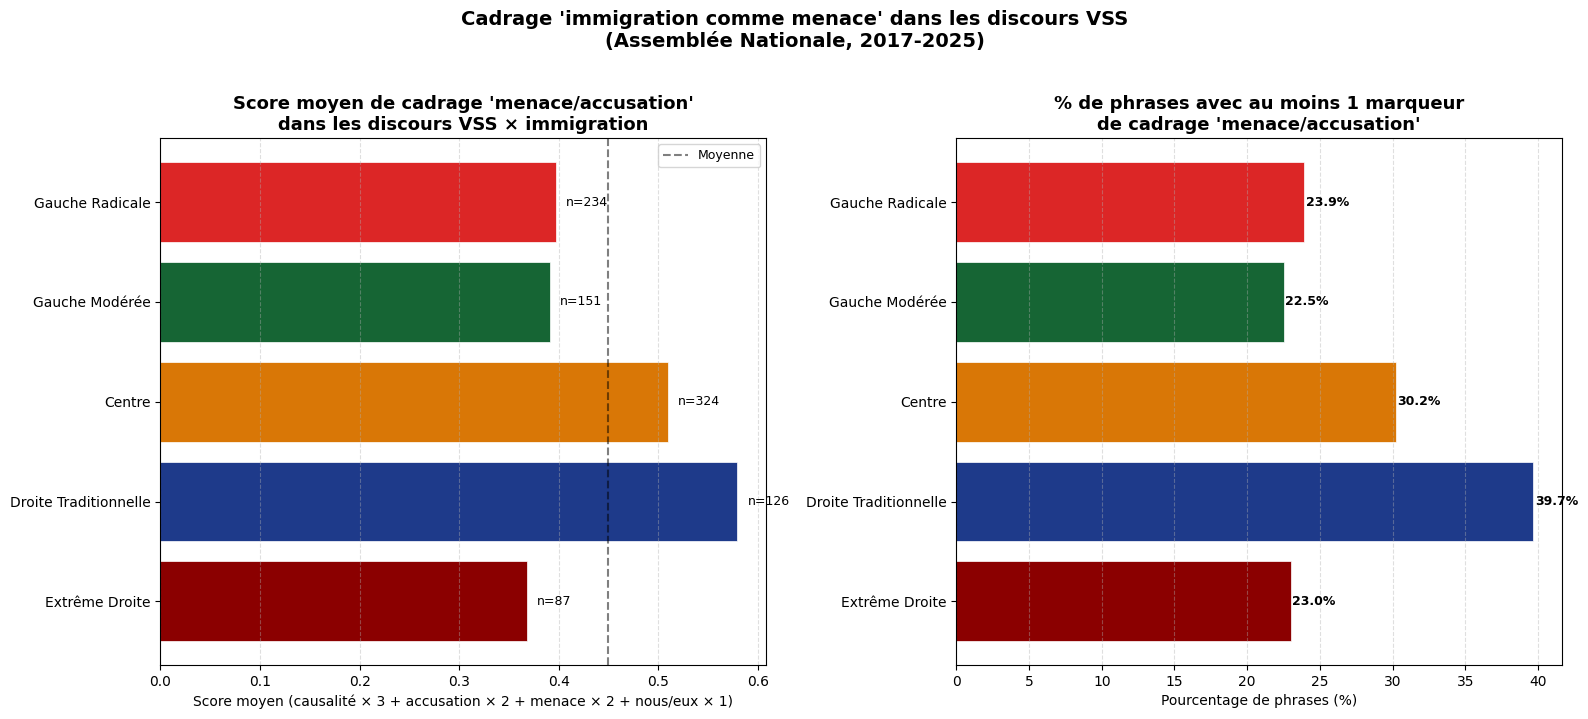

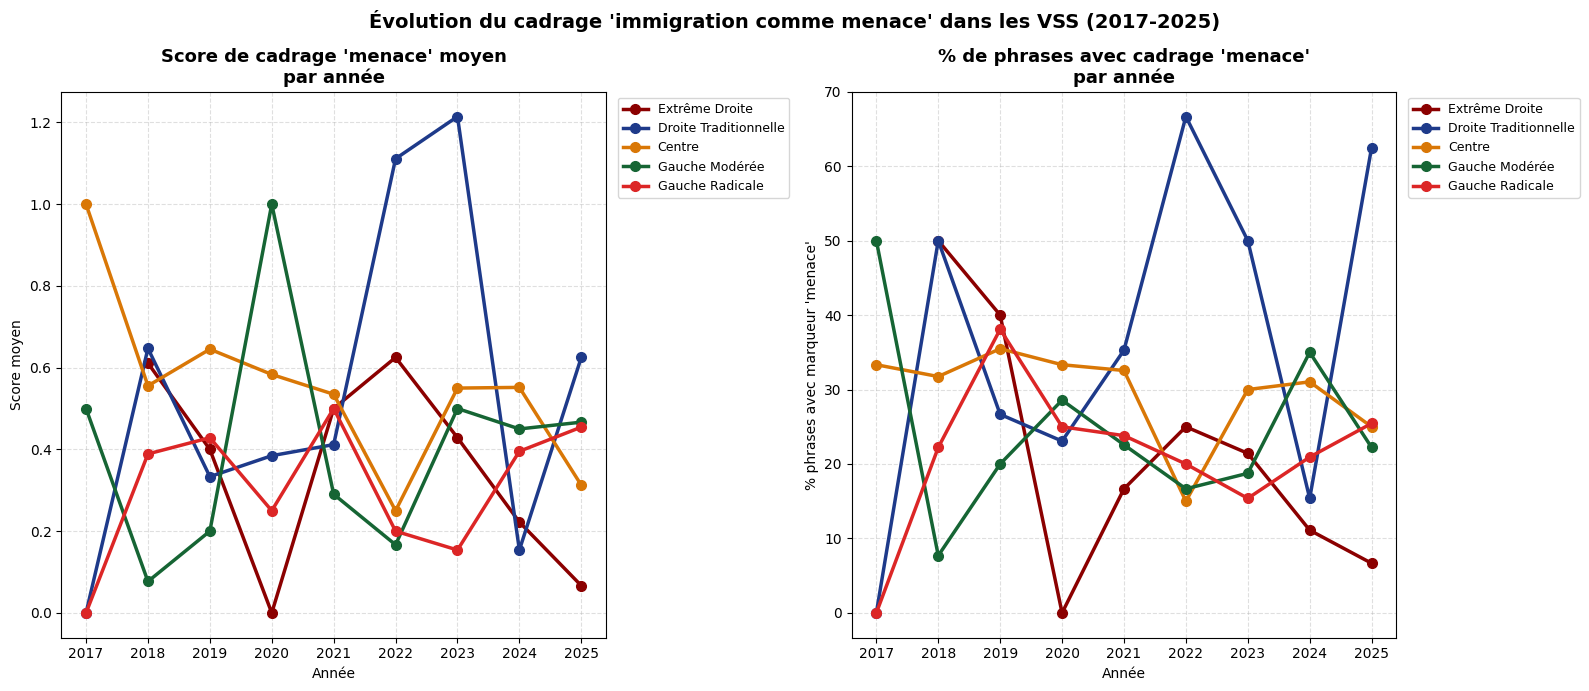

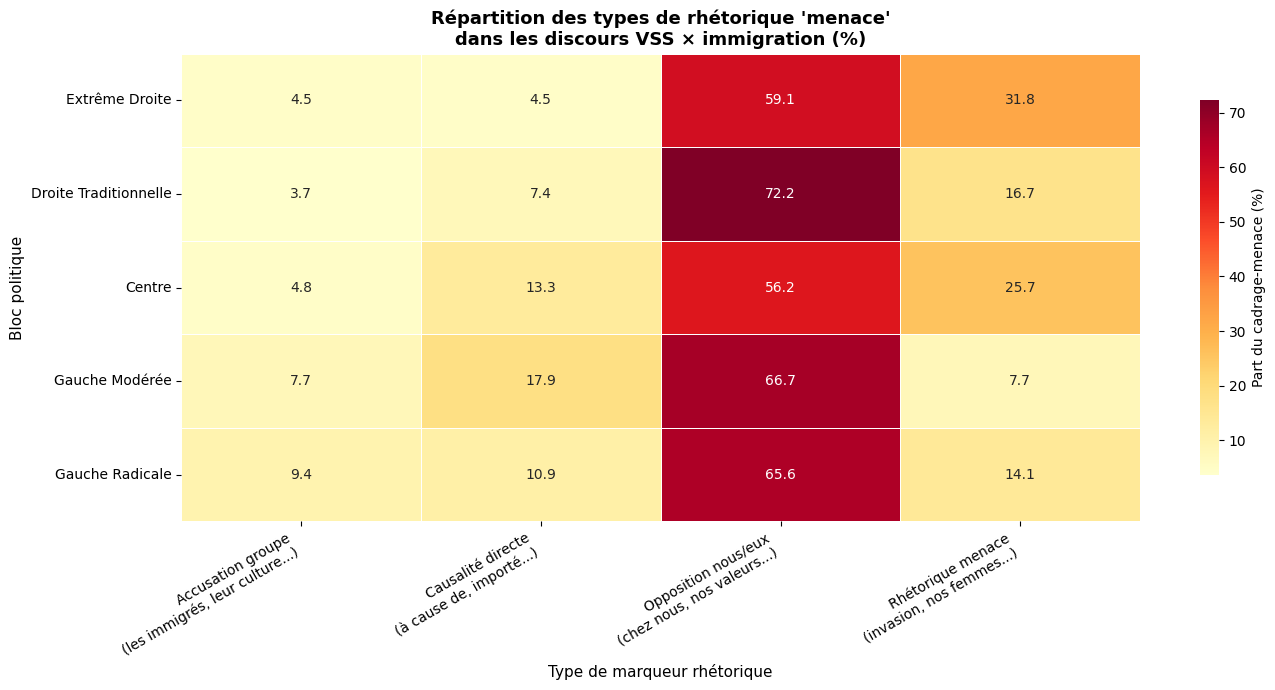

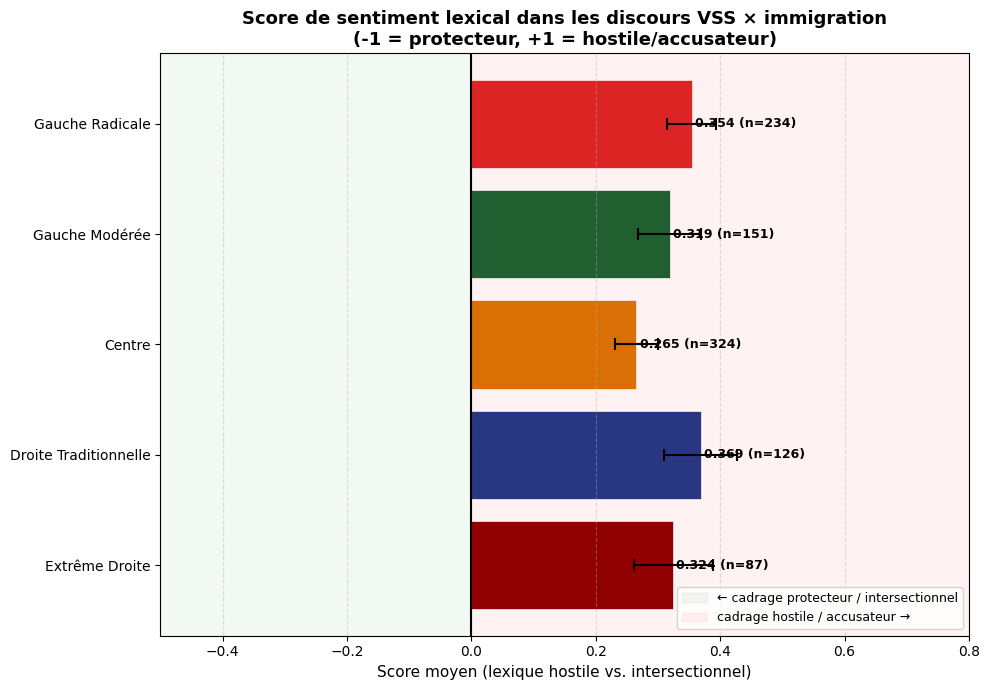


EXEMPLES DE PHRASES PAR BLOC (triées par score de menace)

────────────────────────────────────────────────────────────
  EXTRÊME DROITE
────────────────────────────────────────────────────────────
  Total phrases VSS×immigration : 87
  Score menace moyen : 0.37
  % avec cadrage hostile : 23.0%

  Top 3 phrases les plus 'chargées' :

  [1] Score: 3 | Parti: Rassemblement national
      "L’objectif de cette loi est d’interdire tous les agissements humiliants subis par des personnes en raison de leur identité sexuelle"
      Marqueurs: {'causalite': ['en raison de']}

  [2] Score: 3 | Parti: Rassemblement national
      "Laisser croire, comme le fait La France insoumise, que les droits sexuels et reproductifs ou l’IVG seraient en danger en France relève de l’imposture"
      Marqueurs: {'rhetorique_menace': ['danger'], 'nous_eux': ['en france']}

  [3] Score: 2 | Parti: Front National
      "Cela permettrait en outre de signaler aux candidats au séjour en France que s’ils veulent venir 

In [28]:
"""
============================================================================
ANALYSE DE SENTIMENT ET DE CADRAGE "MENACE" – VSS x IMMIGRATION
============================================================================
Hypothèse : L'extrême droite cadre les VSS comme une menace extérieure
(immigration, islam, clandestins) à la différence des autres blocs.

Approche en 3 couches :
  1. Extraction des phrases VSS+immigration (co-occurrence)
  2. Score de "cadrage-menace" (lexique orienté causalité/accusation)
  3. Sentiment CamemBERT sur ces phrases (neutre vs négatif envers immigration)
============================================================================
"""

import re
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from collections import Counter, defaultdict
from tqdm import tqdm

# NLP
import torch
from transformers import CamembertTokenizer, CamembertForSequenceClassification
from transformers import pipeline
from sklearn.metrics.pairwise import cosine_similarity

# ============================================================================
# CONFIGURATION
# ============================================================================

# Vocabulaire du champ identitaire/migratoire
MOTS_IDENTITAIRES = [
    "immigr", "clandestin", "frontière", "étranger", "expulsion",
    "oqtf", "islam", "musulman", "maghrébin", "africain",
    "illégal", "illégaux", "confession", "religion", "migrant",
    "réfugié", "asile", "sans-papier", "communautarisme", "intégration",
    "origine", "culture", "valeurs", "identité", "france", "territoire"
]

# Vocabulaire VSS de base (pour filtrer les phrases pertinentes)
MOTS_VSS = [
    "viol", "agress", "harcèl", "féminicide", "violence", "victime",
    "sexuel", "conjugal", "inceste", "mutilation", "prostitution"
]

# Lexique du "cadrage-menace" : l'immigration CAUSE / EST RESPONSABLE des VSS
# Ce sont des patrons linguistiques d'accusation/causalité
CADRAGE_MENACE = {
    # Causalité directe
    "causalite": [
        "à cause de", "en raison de", "provoqué par", "causé par", "viennent de",
        "importé", "importée", "venu d'ailleurs", "venu de l'étranger",
        "rapporté", "lié à l'immigration", "lié aux migrants",
        "due à l'immigration", "dû à l'immigration", "issus de l'immigration",
        "issu de l'immigration", "commis par des", "perpétré par des",
        "commis par des étrangers", "auteurs étrangers", "agresseurs étrangers"
    ],
    # Désignation / accusation d'un groupe
    "accusation_groupe": [
        "les immigrés", "ces étrangers", "ces migrants", "les clandestins",
        "ces hommes venus", "certaines cultures", "certaines religions",
        "communautés", "les musulmans", "leur culture", "leur religion",
        "leur pays d'origine", "leurs coutumes", "pratiques culturelles",
        "pratiques religieuses", "mentalité", "vision de la femme"
    ],
    # Rhétorique de la menace
    "rhetorique_menace": [
        "invasion", "submersion", "grand remplacement", "ensauvagement",
        "insécurité", "danger", "menace", "protéger", "défendre",
        "nos femmes", "nos filles", "notre pays", "notre identité",
        "laxisme", "permissivité", "frontières ouvertes", "immigration incontrôlée"
    ],
    # Opposition nous/eux
    "nous_eux": [
        "chez nous", "en france", "notre société", "nos valeurs",
        "leur conception", "leur rapport", "contrairement à nous",
        "n'ont pas les mêmes", "mentalité différente",
        "pays d'origine", "culture d'origine"
    ]
}

# Couleurs par bloc politique
COULEURS_BLOCS = {
    "Extrême Droite": "#8B0000",
    "Droite Traditionnelle": "#1E3A8A",
    "Centre": "#D97706",
    "Gauche Modérée": "#166534",
    "Gauche Radicale": "#DC2626"
}

ORDRE_BLOCS = ["Extrême Droite", "Droite Traditionnelle", "Centre", "Gauche Modérée", "Gauche Radicale"]


# ============================================================================
# PARTIE 1 : EXTRACTION DES PHRASES DE CO-OCCURRENCE VSS × IMMIGRATION
# ============================================================================

def extraire_phrases_cooccurrence(df_vss, mots_identitaires, mots_vss, fenetre_mots=50):
    """
    Pour chaque prise de parole VSS, découpe en phrases et ne garde
    que celles où un mot identitaire apparaît à proximité d'un mot VSS.
    
    Args:
        fenetre_mots : taille de la fenêtre de co-occurrence (en mots)
    
    Returns:
        df_phrases : DataFrame des phrases de co-occurrence
    """
    print("Extraction des phrases VSS × immigration...")
    
    pattern_identitaire = re.compile(
        r'(?i)\b(' + '|'.join([re.escape(m) for m in mots_identitaires]) + r')\w*\b'
    )
    pattern_vss = re.compile(
        r'(?i)\b(' + '|'.join([re.escape(m) for m in mots_vss]) + r')\w*\b'
    )
    
    resultats = []
    
    for _, row in tqdm(df_vss.iterrows(), total=len(df_vss), desc="Scan des prises de parole"):
        texte = str(row.get('texte', ''))
        bloc = row.get('bloc', None)
        nom_parti = row.get('nom_parti', None)
        date = row.get('date', None)
        
        if not texte or pd.isna(bloc):
            continue
        
        # Découpage en phrases
        phrases = re.split(r'[.!?;]+', texte)
        
        for phrase in phrases:
            phrase = phrase.strip()
            if len(phrase.split()) < 5:  # on ignore les phrases trop courtes
                continue
            
            a_vss = bool(pattern_vss.search(phrase))
            a_identitaire = bool(pattern_identitaire.search(phrase))
            
            # On garde les phrases avec les deux OU celles dans une fenêtre de co-occurrence
            if a_vss and a_identitaire:
                resultats.append({
                    "phrase": phrase,
                    "bloc": bloc,
                    "nom_parti": nom_parti,
                    "date": date,
                    "a_vss": True,
                    "a_identitaire": True,
                    "type": "directe"
                })
    
    df_phrases = pd.DataFrame(resultats)
    print(f"→ {len(df_phrases)} phrases de co-occurrence VSS × immigration extraites")
    
    if not df_phrases.empty:
        print(f"→ Répartition par bloc :")
        print(df_phrases['bloc'].value_counts().to_string())
    
    return df_phrases


# ============================================================================
# PARTIE 2 : SCORE DE CADRAGE-MENACE (LEXIQUE)
# ============================================================================

def calculer_score_menace(texte, cadrage_menace):
    """
    Calcule un score de "cadrage-menace" pour une phrase donnée.
    Le score est la somme pondérée des détections par catégorie.
    
    Poids : causalite=3, accusation_groupe=2, rhetorique_menace=2, nous_eux=1
    """
    texte_lower = texte.lower()
    score = 0
    details = defaultdict(list)
    
    poids = {
        "causalite": 3,
        "accusation_groupe": 2,
        "rhetorique_menace": 2,
        "nous_eux": 1
    }
    
    for categorie, mots in cadrage_menace.items():
        for mot in mots:
            if mot.lower() in texte_lower:
                score += poids[categorie]
                details[categorie].append(mot)
    
    return score, dict(details)


def appliquer_score_menace(df_phrases, cadrage_menace):
    """
    Applique le score de cadrage-menace à toutes les phrases.
    """
    print("\nCalcul des scores de cadrage-menace...")
    
    scores = []
    details_list = []
    
    for _, row in df_phrases.iterrows():
        score, details = calculer_score_menace(row['phrase'], cadrage_menace)
        scores.append(score)
        details_list.append(str(details) if details else "")
    
    df_phrases = df_phrases.copy()
    df_phrases['score_menace'] = scores
    df_phrases['details_menace'] = details_list
    df_phrases['est_menace'] = df_phrases['score_menace'] > 0
    
    n_menace = df_phrases['est_menace'].sum()
    print(f"→ {n_menace} phrases avec cadrage 'menace' détecté ({n_menace/len(df_phrases)*100:.1f}%)")
    
    return df_phrases


# ============================================================================
# PARTIE 3 : ANALYSE DE SENTIMENT AVEC CAMEMBERT
# ============================================================================

class AnalyseurSentiment:
    """
    Analyse de sentiment avec CamemBERT fine-tuné pour le français.
    Utilise le modèle 'tblard/tf-camembert-base-french-sentiment'.
    """
    
    def __init__(self):
        print("\nChargement du modèle de sentiment français...")
        model_name = "tblard/tf-camembert-base-french-sentiment"
        
        try:
            self.pipe = pipeline(
                "text-classification",
                model=model_name,
                tokenizer="camembert-base",
                device=0 if torch.cuda.is_available() else -1,
                truncation=True,
                max_length=512
            )
            self.disponible = True
            print("✅ Modèle de sentiment chargé avec succès.")
        except Exception as e:
            print(f"⚠️ Modèle de sentiment indisponible : {e}")
            print("→ On utilisera uniquement le score lexical.")
            self.disponible = False
    
    def analyser_batch(self, textes, batch_size=32):
        """
        Analyse le sentiment d'une liste de textes.
        Retourne une liste de dicts {label, score}.
        """
        if not self.disponible:
            return [{"label": "UNKNOWN", "score": 0.5}] * len(textes)
        
        resultats = []
        for i in tqdm(range(0, len(textes), batch_size), desc="Analyse sentiment"):
            batch = textes[i:i+batch_size]
            try:
                preds = self.pipe(batch)
                resultats.extend(preds)
            except Exception as e:
                resultats.extend([{"label": "UNKNOWN", "score": 0.5}] * len(batch))
        
        return resultats


def analyser_sentiment_phrases(df_phrases):
    """
    Lance l'analyse de sentiment sur les phrases de co-occurrence.
    Ajoute colonnes : sentiment_label, sentiment_score, sentiment_negatif
    """
    analyseur = AnalyseurSentiment()
    
    textes = df_phrases['phrase'].tolist()
    resultats = analyseur.analyser_batch(textes)
    
    df_phrases = df_phrases.copy()
    df_phrases['sentiment_label'] = [r['label'] for r in resultats]
    df_phrases['sentiment_score'] = [r['score'] for r in resultats]
    
    # Standardisation des labels (selon le modèle utilisé)
    # Labels possibles : POSITIVE/NEGATIVE ou 1 étoile / 5 étoiles, etc.
    def normaliser_label(label):
        label = str(label).upper()
        if any(x in label for x in ["NEG", "0", "1 STAR", "NEGATIVE"]):
            return "NÉGATIF"
        elif any(x in label for x in ["POS", "1", "5 STAR", "POSITIVE"]):
            return "POSITIF"
        return "NEUTRE"
    
    df_phrases['sentiment_norm'] = df_phrases['sentiment_label'].apply(normaliser_label)
    df_phrases['est_negatif'] = df_phrases['sentiment_norm'] == "NÉGATIF"
    
    # Score combiné : sentiment négatif ET cadrage menace → "cadrage hostile"
    df_phrases['score_hostile'] = (
        df_phrases['score_menace'] * 0.5 +
        df_phrases['est_negatif'].astype(float) * 2
    )
    
    return df_phrases


# ============================================================================
# PARTIE 4 : ANALYSE SANS GPU (LEXICALE PURE, ROBUSTE)
# ============================================================================

# Mots porteurs de sentiment négatif ENVERS l'immigration dans le contexte VSS
SENTIMENT_NEGATIF_ENVERS_IMMIGRATION = [
    # Accusation / blâme
    "responsable", "coupable", "fautif", "auteur", "agresseur", "violeur",
    "commis", "perpétré", "banalisé", "toléré", "importé",
    # Danger / menace
    "danger", "dangereux", "dangerosité", "risque", "menace", "menaçant",
    "insécurité", "violence", "violences", "sauvagerie", "barbarisme",
    "barbare", "primitif", "arriéré", "inculte",
    # Rejet / exclusion
    "expulser", "renvoyer", "reconduire", "chasser", "refouler",
    "inadmissible", "inacceptable", "intolérable",
    # Essentialisation
    "tous", "toujours", "systématiquement", "par nature", "culturellement",
    "génétiquement", "structurellement"
]

# Mots porteurs de sentiment NEUTRE/INTERSECTIONNEL (autres blocs)
SENTIMENT_NEUTRE_INTERSECTIONNEL = [
    # Analyse structurelle / protection
    "aussi", "également", "notamment", "parmi", "certain",
    "certains", "certaines", "quelques",
    # Solidarité / accompagnement
    "accompagner", "protéger", "aider", "soutenir", "accueillir",
    # Double vulnérabilité
    "doublement", "vulnérable", "précaire", "discriminé",
    "sans-papier", "sans titre", "irrégulier"
]


def calculer_score_lexical_sentiment(texte):
    """
    Score lexical combiné :
    - positif si cadrage "menace/accusation" 
    - négatif si cadrage "protection/intersectionnel"
    Retourne un score entre -1 (intersectionnel) et +1 (hostile)
    """
    texte_lower = texte.lower()
    
    score_hostile = sum(1 for m in SENTIMENT_NEGATIF_ENVERS_IMMIGRATION if m in texte_lower)
    score_intersect = sum(1 for m in SENTIMENT_NEUTRE_INTERSECTIONNEL if m in texte_lower)
    
    total = score_hostile + score_intersect
    if total == 0:
        return 0.0
    
    return (score_hostile - score_intersect) / total


# ============================================================================
# PARTIE 5 : VISUALISATIONS
# ============================================================================

def tracer_score_menace_par_bloc(df_phrases, output_dir=None):
    """
    Graphique 1 : Score moyen de cadrage-menace par bloc idéologique.
    """
    if output_dir:
        os.makedirs(output_dir, exist_ok=True)

    stats = df_phrases.groupby('bloc').agg(
        score_moyen=('score_menace', 'mean'),
        n_phrases=('score_menace', 'count'),
        pct_menace=('est_menace', lambda x: x.mean() * 100)
    ).reset_index()
    
    stats = stats[stats['bloc'].isin(ORDRE_BLOCS)]
    stats['bloc'] = pd.Categorical(stats['bloc'], categories=ORDRE_BLOCS, ordered=True)
    stats = stats.sort_values('bloc')
    
    fig, axes = plt.subplots(1, 2, figsize=(16, 7))
    
    # --- Score moyen ---
    couleurs = [COULEURS_BLOCS.get(b, 'gray') for b in stats['bloc']]
    bars = axes[0].barh(stats['bloc'], stats['score_moyen'], color=couleurs, edgecolor='white', linewidth=0.5)
    axes[0].set_title("Score moyen de cadrage 'menace/accusation'\ndans les discours VSS × immigration", fontsize=13, fontweight='bold')
    axes[0].set_xlabel("Score moyen (causalité × 3 + accusation × 2 + menace × 2 + nous/eux × 1)", fontsize=10)
    axes[0].axvline(x=stats['score_moyen'].mean(), color='black', linestyle='--', alpha=0.5, label='Moyenne')
    
    for bar, n in zip(bars, stats['n_phrases']):
        axes[0].text(bar.get_width() + 0.01, bar.get_y() + bar.get_height()/2,
                    f"n={n}", va='center', fontsize=9)
    axes[0].legend(fontsize=9)
    axes[0].grid(axis='x', linestyle='--', alpha=0.4)
    
    # --- Pourcentage de phrases avec cadrage menace ---
    bars2 = axes[1].barh(stats['bloc'], stats['pct_menace'], color=couleurs, edgecolor='white', linewidth=0.5)
    axes[1].set_title("% de phrases avec au moins 1 marqueur\nde cadrage 'menace/accusation'", fontsize=13, fontweight='bold')
    axes[1].set_xlabel("Pourcentage de phrases (%)", fontsize=10)
    
    for bar, val in zip(bars2, stats['pct_menace']):
        axes[1].text(bar.get_width() + 0.1, bar.get_y() + bar.get_height()/2,
                    f"{val:.1f}%", va='center', fontsize=9, fontweight='bold')
    axes[1].grid(axis='x', linestyle='--', alpha=0.4)
    
    plt.suptitle("Cadrage 'immigration comme menace' dans les discours VSS\n(Assemblée Nationale, 2017-2025)",
                fontsize=14, fontweight='bold', y=1.02)
    plt.tight_layout()
    
    if output_dir:
        plt.savefig(os.path.join(output_dir, "cadrage_menace_par_bloc.png"), dpi=150, bbox_inches='tight')
    plt.show()


def tracer_evolution_cadrage_menace(df_phrases, output_dir=None):
    """
    Graphique 2 : Évolution temporelle du score de menace par bloc.
    """
    if output_dir:
        os.makedirs(output_dir, exist_ok=True)

    df = df_phrases.copy()
    df['date'] = pd.to_datetime(df['date'])
    df['annee'] = df['date'].dt.year
    
    evolution = df.groupby(['annee', 'bloc']).agg(
        score_moyen=('score_menace', 'mean'),
        pct_menace=('est_menace', lambda x: x.mean() * 100)
    ).reset_index()
    
    evolution = evolution[evolution['bloc'].isin(ORDRE_BLOCS)]
    
    fig, axes = plt.subplots(1, 2, figsize=(16, 7))
    
    for bloc in ORDRE_BLOCS:
        data_bloc = evolution[evolution['bloc'] == bloc].sort_values('annee')
        if data_bloc.empty:
            continue
        couleur = COULEURS_BLOCS.get(bloc, 'gray')
        
        axes[0].plot(data_bloc['annee'], data_bloc['score_moyen'],
                    marker='o', label=bloc, color=couleur, linewidth=2.5, markersize=7)
        axes[1].plot(data_bloc['annee'], data_bloc['pct_menace'],
                    marker='o', label=bloc, color=couleur, linewidth=2.5, markersize=7)
    
    axes[0].set_title("Score de cadrage 'menace' moyen\npar année", fontsize=13, fontweight='bold')
    axes[0].set_xlabel("Année")
    axes[0].set_ylabel("Score moyen")
    axes[0].legend(bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=9)
    axes[0].grid(linestyle='--', alpha=0.4)
    
    axes[1].set_title("% de phrases avec cadrage 'menace'\npar année", fontsize=13, fontweight='bold')
    axes[1].set_xlabel("Année")
    axes[1].set_ylabel("% phrases avec marqueur 'menace'")
    axes[1].legend(bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=9)
    axes[1].grid(linestyle='--', alpha=0.4)
    
    plt.suptitle("Évolution du cadrage 'immigration comme menace' dans les VSS (2017-2025)",
                fontsize=14, fontweight='bold')
    plt.tight_layout()
    
    if output_dir:
        plt.savefig(os.path.join(output_dir, "evolution_cadrage_menace.png"), dpi=150, bbox_inches='tight')
    plt.show()


def tracer_heatmap_categories_cadrage(df_phrases, output_dir=None):
    """
    Graphique 3 : Heatmap des catégories de cadrage par bloc.
    Montre quels types de rhétorique chaque bloc utilise.
    """
    if output_dir:
        os.makedirs(output_dir, exist_ok=True)

    # On re-calcule les scores par catégorie
    records = []
    
    for _, row in df_phrases.iterrows():
        texte = row['phrase'].lower()
        bloc = row['bloc']
        if pd.isna(bloc):
            continue
        
        for categorie, mots in CADRAGE_MENACE.items():
            count = sum(1 for m in mots if m.lower() in texte)
            records.append({'bloc': bloc, 'categorie': categorie, 'count': count})
    
    df_cat = pd.DataFrame(records)
    pivot = df_cat.groupby(['bloc', 'categorie'])['count'].sum().unstack(fill_value=0)
    
    # Normalisation : % par rapport au total de chaque bloc
    pivot_norm = pivot.div(pivot.sum(axis=1), axis=0) * 100
    pivot_norm = pivot_norm.reindex([b for b in ORDRE_BLOCS if b in pivot_norm.index])
    
    # Renommage des colonnes pour lisibilité
    noms_cat = {
        "causalite": "Causalité directe\n(à cause de, importé...)",
        "accusation_groupe": "Accusation groupe\n(les immigrés, leur culture...)",
        "rhetorique_menace": "Rhétorique menace\n(invasion, nos femmes...)",
        "nous_eux": "Opposition nous/eux\n(chez nous, nos valeurs...)"
    }
    pivot_norm.columns = [noms_cat.get(c, c) for c in pivot_norm.columns]
    
    plt.figure(figsize=(14, 7))
    sns.heatmap(
        pivot_norm,
        annot=True, fmt='.1f', cmap="YlOrRd",
        linewidths=0.5, linecolor='white',
        cbar_kws={'label': 'Part du cadrage-menace (%)', 'shrink': 0.8}
    )
    plt.title("Répartition des types de rhétorique 'menace'\ndans les discours VSS × immigration (%)", fontsize=13, fontweight='bold')
    plt.ylabel("Bloc politique", fontsize=11)
    plt.xlabel("Type de marqueur rhétorique", fontsize=11)
    plt.xticks(rotation=30, ha='right')
    plt.tight_layout()
    
    if output_dir:
        plt.savefig(os.path.join(output_dir, "heatmap_categories_cadrage.png"), dpi=150, bbox_inches='tight')
    plt.show()


def tracer_score_hostile_sentiment(df_phrases, output_dir=None):
    """
    Graphique 4 : Score lexical de sentiment hostile (entre -1 et +1).
    -1 = cadrage intersectionnel/protecteur
    +1 = cadrage hostile/accusateur
    """
    if output_dir:
        os.makedirs(output_dir, exist_ok=True)

    df = df_phrases.copy()
    df['score_lex_sent'] = df['phrase'].apply(calculer_score_lexical_sentiment)
    
    stats = df.groupby('bloc')['score_lex_sent'].agg(['mean', 'sem', 'count']).reset_index()
    stats.columns = ['bloc', 'score_moyen', 'erreur_std', 'n']
    stats = stats[stats['bloc'].isin(ORDRE_BLOCS)]
    stats['bloc'] = pd.Categorical(stats['bloc'], categories=ORDRE_BLOCS, ordered=True)
    stats = stats.sort_values('bloc')
    
    couleurs = [COULEURS_BLOCS.get(b, 'gray') for b in stats['bloc']]
    
    fig, ax = plt.subplots(figsize=(10, 7))
    
    bars = ax.barh(
        stats['bloc'],
        stats['score_moyen'],
        xerr=stats['erreur_std'],
        color=couleurs,
        edgecolor='white',
        linewidth=0.5,
        capsize=4,
        error_kw={'elinewidth': 1.5, 'ecolor': 'black', 'capthick': 1.5}
    )
    
    ax.axvline(x=0, color='black', linewidth=1.5, linestyle='-')
    ax.axvspan(-1, 0, alpha=0.05, color='green', label="← cadrage protecteur / intersectionnel")
    ax.axvspan(0, 1, alpha=0.05, color='red', label="cadrage hostile / accusateur →")
    
    for bar, (_, row) in zip(bars, stats.iterrows()):
        x = bar.get_width()
        ax.text(x + 0.005 if x >= 0 else x - 0.005,
                bar.get_y() + bar.get_height()/2,
                f"{row['score_moyen']:.3f} (n={int(row['n'])})",
                va='center', ha='left' if x >= 0 else 'right',
                fontsize=9, fontweight='bold')
    
    ax.set_title("Score de sentiment lexical dans les discours VSS × immigration\n(-1 = protecteur, +1 = hostile/accusateur)", fontsize=13, fontweight='bold')
    ax.set_xlabel("Score moyen (lexique hostile vs. intersectionnel)", fontsize=11)
    ax.legend(loc='lower right', fontsize=9)
    ax.grid(axis='x', linestyle='--', alpha=0.4)
    ax.set_xlim(-0.5, 0.8)
    
    plt.tight_layout()
    
    if output_dir:
        plt.savefig(os.path.join(output_dir, "score_hostile_sentiment.png"), dpi=150, bbox_inches='tight')
    plt.show()
    
    return df


def afficher_exemples_phrases(df_phrases, n_exemples=5):
    """
    Affiche des exemples de phrases par bloc, triées par score de menace.
    Utile pour valider qualitativement les résultats.
    """
    print("\n" + "="*80)
    print("EXEMPLES DE PHRASES PAR BLOC (triées par score de menace)")
    print("="*80)
    
    for bloc in ORDRE_BLOCS:
        df_bloc = df_phrases[df_phrases['bloc'] == bloc].sort_values('score_menace', ascending=False)
        if df_bloc.empty:
            continue
        
        print(f"\n{'─'*60}")
        print(f"  {bloc.upper()}")
        print(f"{'─'*60}")
        print(f"  Total phrases VSS×immigration : {len(df_bloc)}")
        print(f"  Score menace moyen : {df_bloc['score_menace'].mean():.2f}")
        print(f"  % avec cadrage hostile : {df_bloc['est_menace'].mean()*100:.1f}%")
        print(f"\n  Top {n_exemples} phrases les plus 'chargées' :")
        
        for i, (_, row) in enumerate(df_bloc.head(n_exemples).iterrows()):
            phrase = row['phrase'][:200] + "..." if len(row['phrase']) > 200 else row['phrase']
            print(f"\n  [{i+1}] Score: {row['score_menace']:.0f} | Parti: {row.get('nom_parti', '?')}")
            print(f"      \"{phrase}\"")
            if row['details_menace']:
                print(f"      Marqueurs: {row['details_menace']}")


def generer_rapport_complet(df_phrases, output_dir=None):
    """
    Génère un rapport CSV des résultats pour analyse approfondie.
    """
    if output_dir:
        os.makedirs(output_dir, exist_ok=True)
        chemin = os.path.join(output_dir, "phrases_vss_immigration_scores.csv")
        df_phrases.to_csv(chemin, index=False, encoding='utf-8-sig')
        print(f"\n💾 Rapport CSV sauvegardé : {chemin}")
    
    # Statistiques de synthèse par bloc
    stats = df_phrases.groupby('bloc').agg(
        n_phrases=('phrase', 'count'),
        score_menace_moyen=('score_menace', 'mean'),
        pct_cadrage_menace=('est_menace', lambda x: x.mean() * 100),
    ).round(3)
    
    print("\n📊 SYNTHÈSE PAR BLOC :")
    print(stats.to_string())
    
    return stats


# ============================================================================
# PIPELINE PRINCIPAL
# ============================================================================

def pipeline_sentiment_vss_immigration(df_vss, output_dir=None):
    """
    Pipeline complet d'analyse de sentiment VSS × immigration.
    
    Args:
        df_vss : DataFrame des prises de parole VSS filtrées
        output_dir : dossier de sortie pour les graphiques
    
    Returns:
        df_phrases : DataFrame enrichi avec tous les scores
    """
    
    print("="*80)
    print("ANALYSE DE SENTIMENT VSS × IMMIGRATION")
    print("Hypothèse : L'extrême droite cadre les VSS comme menace extérieure")
    print("="*80)
    
    # --- 1. Vérification des données ---
    if 'bloc' not in df_vss.columns:
        print("Ajout des blocs idéologiques...")
        from analyse_vss import regrouper_blocs_ideologiques
        df_vss['bloc'] = df_vss['nom_parti'].apply(regrouper_blocs_ideologiques)
    
    df_vss = df_vss.dropna(subset=['bloc']).copy()
    print(f"→ {len(df_vss)} prises de parole avec bloc identifié")
    
    # --- 2. Extraction des phrases de co-occurrence ---
    df_phrases = extraire_phrases_cooccurrence(df_vss, MOTS_IDENTITAIRES, MOTS_VSS)
    
    if df_phrases.empty:
        print("⚠️ Aucune phrase de co-occurrence trouvée. Vérifiez les données.")
        return None
    
    # --- 3. Score de cadrage-menace (lexique) ---
    df_phrases = appliquer_score_menace(df_phrases, CADRAGE_MENACE)
    
    # --- 4. Visualisations ---
    print("\nGénération des graphiques...")
    
    tracer_score_menace_par_bloc(df_phrases, output_dir)
    tracer_evolution_cadrage_menace(df_phrases, output_dir)
    tracer_heatmap_categories_cadrage(df_phrases, output_dir)
    df_phrases = tracer_score_hostile_sentiment(df_phrases, output_dir)
    
    # --- 5. Exemples qualitatifs ---
    afficher_exemples_phrases(df_phrases, n_exemples=3)
    
    # --- 6. Rapport ---
    stats = generer_rapport_complet(df_phrases, output_dir)
    
    print("\n✅ Analyse terminée.")
    return df_phrases


# ============================================================================
# POINT D'ENTRÉE
# ============================================================================

if __name__ == "__main__":
    
    # Chargement des données
    chemin_propre = "/home/onyxia/work/projet_eco_socio/df_vss_propre.pkl"
    output_dir = "/home/onyxia/work/projet_eco_socio/analyses_sentiment/"
    
    if not os.path.exists(chemin_propre):
        print("❌ ERREUR : df_vss_propre.pkl introuvable. Relancez la cellule 1 !")
        exit()
    
    print("Chargement de df_vss_propre.pkl...")
    df_vss = pd.read_pickle(chemin_propre)
    print(f"✅ {len(df_vss)} prises de parole chargées.")
    
    # Lancement du pipeline
    df_phrases = pipeline_sentiment_vss_immigration(df_vss, output_dir=output_dir)
    
    if df_phrases is not None:
        # Sauvegarde pour usage ultérieur
        df_phrases.to_pickle(
            os.path.join(output_dir, "df_phrases_vss_immigration.pkl")
        )
        print(f"\n💾 Données sauvegardées dans {output_dir}")

Chargement des données...
✅ 10380 prises de parole chargées.
ANALYSE DE CADRAGE VSS × IMMIGRATION (v2 – orientée rôle)
Extraction des phrases VSS × groupe cible...


100%|██████████| 10380/10380 [00:03<00:00, 2948.31it/s]


→ 200 phrases co-occurrence extraites
cadrage
NEUTRE        166
VICTIME        23
ACCUSATEUR      8
AMBIGU          3

Génération des graphiques...


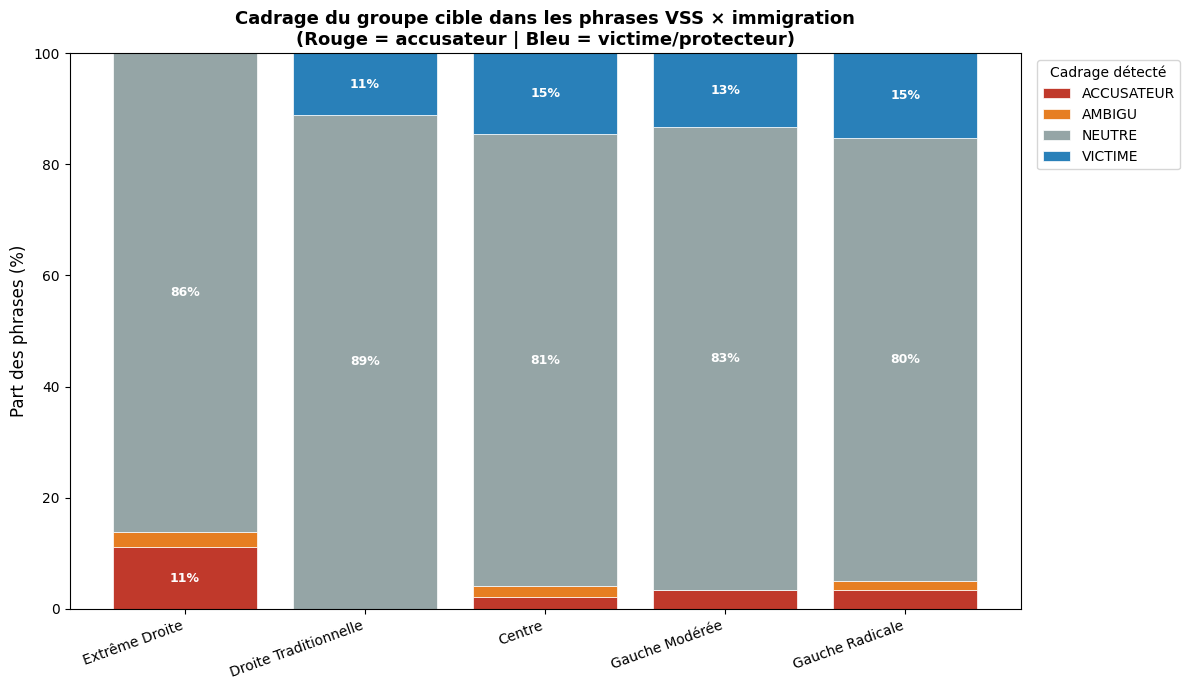

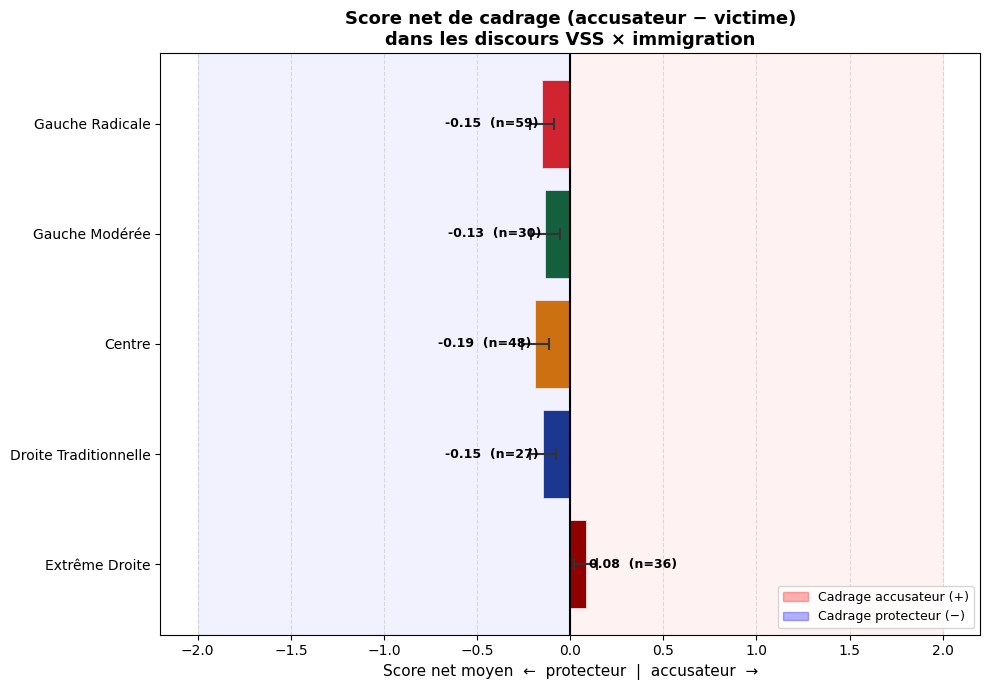

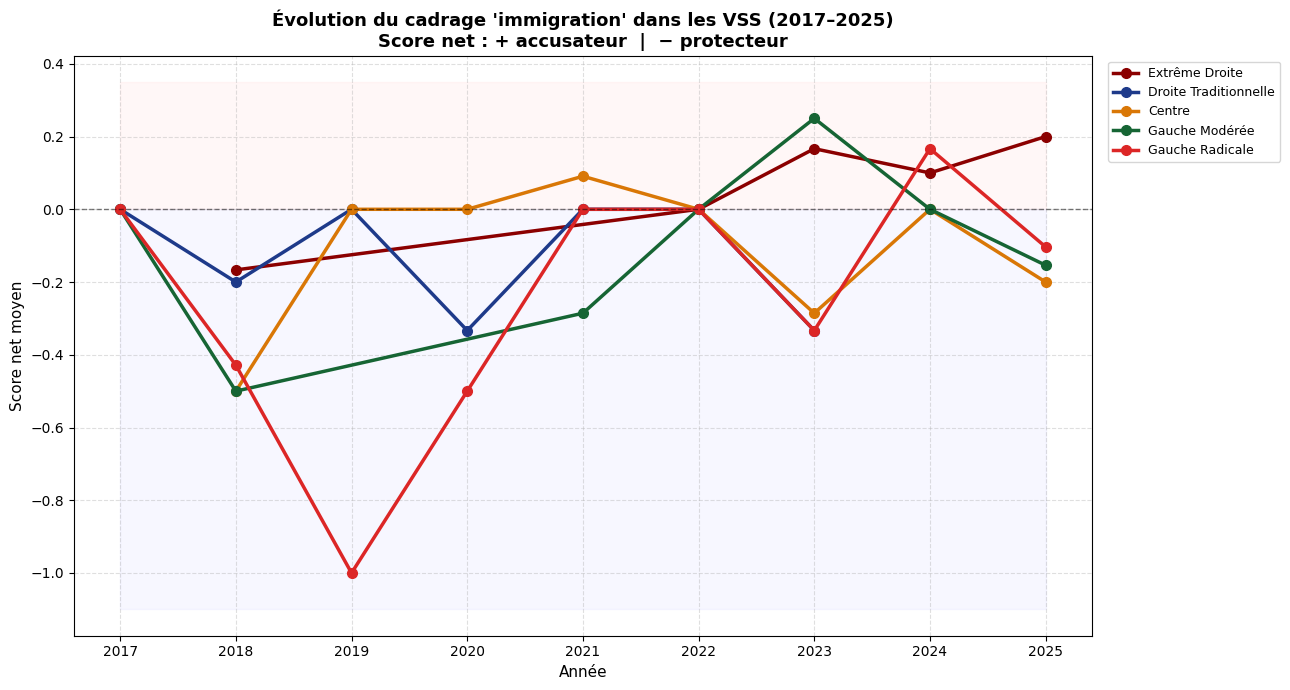


VALIDATION QUALITATIVE – exemples par bloc et cadrage

─────────────────────────────────────────────────────────────────
  EXTRÊME DROITE
  36 phrases | score net moyen : 0.08
  Cadrages : {'NEUTRE': 31, 'ACCUSATEUR': 4, 'AMBIGU': 1}
─────────────────────────────────────────────────────────────────

  [ACCUSATEUR]
    Parti: Rassemblement national
    "Enfin, face à l’islamisation de notre pays et aux agressions régulières subies par une partie de nos concitoyens en raison d’une orientation sexuelle réelle ou supposée, il nous faut réaffirmer qu’au fondement de notre c…"

    Parti: UDR - Union des Droites pour la République
    "Alors que la gauche exaltait, par opportunisme électoral, les différences sexuelles, culturelles et ethniques 															, Donald Trump rappelait que peu importent ces différences, car c’est l’Amérique, en tant que c…"


─────────────────────────────────────────────────────────────────
  DROITE TRADITIONNELLE
  27 phrases | score net moyen : -0.15
  Cadra

In [29]:
"""
============================================================================
ANALYSE DE CADRAGE VSS × IMMIGRATION – VERSION 2 (ORIENTÉE RÔLE)
============================================================================
Problème v1 : le lexique brut est aveugle au sens.
  "Les musulmans sont agressés" → même score que "Les musulmans agressent"

Solution v3 : on détecte QUI joue quel rôle dans la phrase.
  - Cadrage ACCUSATEUR  : immigrés/musulmans = AGENT/CAUSE des violences
  - Cadrage VICTIME     : immigrés/musulmans = VICTIME des violences
  - Cadrage NEUTRE      : mention sans rôle clair

Méthode : patterns syntaxiques orientés (sujet-verbe-objet simplifié)
+ vecteurs de contexte CamemBERT pour affiner.
============================================================================
"""

import re
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from collections import defaultdict
from tqdm import tqdm

# ============================================================================
# CONFIGURATION
# ============================================================================

COULEURS_BLOCS = {
    "Extrême Droite":       "#8B0000",
    "Droite Traditionnelle":"#1E3A8A",
    "Centre":               "#D97706",
    "Gauche Modérée":       "#166534",
    "Gauche Radicale":      "#DC2626"
}
ORDRE_BLOCS = ["Extrême Droite", "Droite Traditionnelle", "Centre", "Gauche Modérée", "Gauche Radicale"]

# --- Groupes cibles (immigration/religion) ---
GROUPES_CIBLES = [
    "immigr", "clandestin", "étranger", "migrant", "réfugié",
    "sans-papier", "islam", "musulman", "maghrébin", "africain",
    "arabe", "communauté", "confession", "origine étrangère"
]

# --- Mots VSS ---
MOTS_VSS_VIOLENCE = [
    "viol", "agress", "harcèl", "féminicide", "violence", "victime",
    "sexuel", "conjugal", "inceste", "mutilation", "prostitution", "violence"
]

# ============================================================================
# PATTERNS ORIENTÉS RÔLE
# ============================================================================
# La clé : on cherche si le groupe cible est AGENT (cause) ou PATIENT (victime)

# Patterns où le groupe cible est AGENT/RESPONSABLE des VSS
# → cadrage accusateur
PATTERNS_ACCUSATEUR = [

    # "[groupe] + verbe d'agression"
    r"(immigr\w*|clandestin\w*|étranger\w*|migrant\w*|musulman\w*|arabe\w*)"
    r"[\w\s,]{0,30}"
    r"(viol\w*|agress\w*|maltraitent|commettent|perpètrent|battent|frappent|tuent)",

    # "les violences (commises|perpétrées) par [groupe]"
    r"(violences?|viols?|agressions?|féminicides?)"
    r"[\w\s,]{0,20}"
    r"(commis|perpétr|fait|exerc)\w*"
    r"[\w\s,]{0,15}"
    r"(immigr\w*|clandestin\w*|étranger\w*|musulman\w*|arabe\w*)",

    # "à cause de / en raison de l'immigration / de leur culture"
    r"(à cause de|en raison de|du fait de|liés? à)"
    r"[\w\s]{0,20}"
    r"(l.immigration|clandestin|leur culture|leur religion|leur origine|l.islam)",

    # "importé / venu d'ailleurs / étranger à notre..."
    r"(import[ée]\w*|venu[e]? d.ailleurs|étranger[eès]? à notre|apporté\w*)",

    # "nos femmes" / "nos filles" (logique patrimoniale)
    r"(nos femmes|nos filles|nos enfants|notre société)\b"
    r"[\w\s,]{0,30}"
    r"(protéger|défendre|menac\w*|agress\w*|danger)",

    # "invasion / ensauvagement / grand remplacement"
    r"(invasion|ensauvagement|grand remplacement|submersion|islamisation)",

    # "leur culture / mentalité / rapport à la femme" comme cause
    r"(leur culture|leur mentalité|leur rapport à la femme|leur vision de la femme"
    r"|leur conception de la femme|pratiques culturelles|pratiques religieuses)",
]

# Patterns où le groupe cible est VICTIME / OBJET de protection
# → cadrage protecteur / intersectionnel
PATTERNS_VICTIME = [

    # "[groupe] sont victimes / subissent / sont agressés"
    r"(immigr\w*|clandestin\w*|étranger\w*|migrant\w*|musulman\w*|sans-papier\w*|réfugié\w*)"
    r"[\w\s,]{0,30}"
    r"(victimes?|subiss\w*|agress[ée]\w*|discrimin\w*|maltraitées?|exposés?\w*|menacés?\w*)",

    # "protéger les [groupe]"
    r"(protéger|défendre|accompagner|soutenir|aider)"
    r"[\w\s]{0,20}"
    r"(immigr\w*|clandestin\w*|femmes? étrangères?|migrant\w*|sans-papier\w*|réfugiées?)",

    # "violences subies par les [groupe]"
    r"(violences?|viols?|agressions?)"
    r"[\w\s,]{0,20}"
    r"(subies?|endurées?|vécues?|souffertes?)"
    r"[\w\s,]{0,20}"
    r"(immigr\w*|étranger\w*|migrant\w*|réfugié\w*)",

    # "double vulnérabilité / doublement victimes"
    r"(doublement|vulnérable|précaire|plus exposée|davantage exposée)",

    # "racisme / islamophobie / xénophobie" contre ce groupe
    r"(racisme|islamophobie|xénophobie|discrimination|antisémit\w*)"
    r"[\w\s,]{0,30}"
    r"(contre|envers|visant|touchant|frappant)"
    r"[\w\s]{0,20}"
    r"(musulman\w*|immigr\w*|étranger\w*|arabe\w*|noir\w*)",

    # boucs émissaires / stigmatisation
    r"(bouc[s]? émissaire[s]?|stigmatis\w*|diabolis\w*|montré[s]? du doigt)",

    # peur des ratonnades / insécurité subie par les musulmans
    r"(musulman\w*|étranger\w*|immigr\w*)"
    r"[\w\s,]{0,30}"
    r"(peur|crainte|insécurité|ne se sent\w* plus|sentiment d.insécurité)",
]

# Patterns de NEUTRALISATION : la mention du groupe est analytique/neutre
PATTERNS_NEUTRALISANTS = [
    # "en raison de leur orientation sexuelle / religion" = cause de PERSÉCUTION subie
    r"(persécuté\w*|pourchassé\w*|fui\w*|menacé\w*)"
    r"[\w\s,]{0,30}"
    r"(en raison de|du fait de|à cause de)"
    r"[\w\s]{0,20}"
    r"(religion|orientation sexuelle|origine)",

    # droit d'asile / protection internationale
    r"(droit d.asile|protection internationale|convention de genève|statut de réfugié)",

    # "certaines cultures" suivi d'analyse critique
    r"(certaines cultures|certains pays)\b"
    r"[\w\s,]{0,30}"
    r"(où|dans lesquels|pratiquent|existe|persistent)",
]


def detecter_role(phrase):
    """
    Détecte le rôle du groupe cible dans la phrase.
    
    Retourne un dict avec :
        - 'accusateur'   : nb de patterns accusateurs matchés
        - 'victime'      : nb de patterns victimes matchés
        - 'neutralisant' : nb de patterns neutralisants matchés
        - 'score_net'    : accusateur - victime - neutralisant
        - 'cadrage'      : 'ACCUSATEUR' | 'VICTIME' | 'AMBIGU' | 'NEUTRE'
    """
    phrase_lower = phrase.lower()

    n_acc = sum(
        1 for p in PATTERNS_ACCUSATEUR
        if re.search(p, phrase_lower, re.IGNORECASE | re.DOTALL)
    )
    n_vic = sum(
        1 for p in PATTERNS_VICTIME
        if re.search(p, phrase_lower, re.IGNORECASE | re.DOTALL)
    )
    n_neu = sum(
        1 for p in PATTERNS_NEUTRALISANTS
        if re.search(p, phrase_lower, re.IGNORECASE | re.DOTALL)
    )

    score_net = n_acc - n_vic - n_neu

    if n_acc == 0 and n_vic == 0:
        cadrage = "NEUTRE"
    elif n_acc > n_vic + n_neu:
        cadrage = "ACCUSATEUR"
    elif n_vic + n_neu > n_acc:
        cadrage = "VICTIME"
    else:
        cadrage = "AMBIGU"

    return {
        "n_accusateur": n_acc,
        "n_victime": n_vic,
        "n_neutralisant": n_neu,
        "score_net": score_net,
        "cadrage": cadrage
    }


# ============================================================================
# EXTRACTION ET SCORING
# ============================================================================

def extraire_et_scorer_phrases(df_vss):
    """
    Extrait les phrases de co-occurrence VSS × groupe cible,
    puis applique la détection de rôle.
    """
    pattern_groupe = re.compile(
        r'(?i)\b(' + '|'.join([re.escape(m) for m in GROUPES_CIBLES]) + r')\w*\b'
    )
    pattern_vss = re.compile(
        r'(?i)\b(' + '|'.join([re.escape(m) for m in MOTS_VSS_VIOLENCE]) + r')\w*\b'
    )

    print("Extraction des phrases VSS × groupe cible...")
    resultats = []

    for _, row in tqdm(df_vss.iterrows(), total=len(df_vss)):
        texte = str(row.get('texte', ''))
        bloc = row.get('bloc')
        nom_parti = row.get('nom_parti')
        date = row.get('date')

        if not texte or pd.isna(bloc):
            continue

        phrases = re.split(r'[.!?;]+', texte)

        for phrase in phrases:
            phrase = phrase.strip()
            if len(phrase.split()) < 6:
                continue

            a_vss = bool(pattern_vss.search(phrase))
            a_groupe = bool(pattern_groupe.search(phrase))

            if not (a_vss and a_groupe):
                continue

            role = detecter_role(phrase)

            resultats.append({
                "phrase":        phrase,
                "bloc":          bloc,
                "nom_parti":     nom_parti,
                "date":          date,
                **role
            })

    df = pd.DataFrame(resultats)
    print(f"→ {len(df)} phrases co-occurrence extraites")
    if not df.empty:
        print(df['cadrage'].value_counts().to_string())
    return df


# ============================================================================
# VISUALISATIONS
# ============================================================================

def tracer_cadrage_par_bloc(df, output_dir=None):
    """
    Graphique 1 : Répartition des cadrages (ACCUSATEUR / VICTIME / AMBIGU / NEUTRE)
    par bloc sous forme de barres 100% empilées.
    """
    if output_dir:
        os.makedirs(output_dir, exist_ok=True)

    counts = (
        df.groupby(['bloc', 'cadrage'])
        .size()
        .unstack(fill_value=0)
        .reindex([b for b in ORDRE_BLOCS if b in df['bloc'].unique()])
    )
    # Normalisation en %
    pct = counts.div(counts.sum(axis=1), axis=0) * 100

    # Assure que toutes les colonnes existent
    for col in ['ACCUSATEUR', 'AMBIGU', 'NEUTRE', 'VICTIME']:
        if col not in pct.columns:
            pct[col] = 0

    couleurs_cadrage = {
        'ACCUSATEUR': '#C0392B',
        'AMBIGU':     '#E67E22',
        'NEUTRE':     '#95A5A6',
        'VICTIME':    '#2980B9'
    }

    fig, ax = plt.subplots(figsize=(12, 7))
    bottom = np.zeros(len(pct))

    for cadrage in ['ACCUSATEUR', 'AMBIGU', 'NEUTRE', 'VICTIME']:
        vals = pct[cadrage].values
        bars = ax.bar(pct.index, vals, bottom=bottom,
                      color=couleurs_cadrage[cadrage], label=cadrage,
                      edgecolor='white', linewidth=0.5)
        # Annotations
        for i, (v, b) in enumerate(zip(vals, bottom)):
            if v > 4:
                ax.text(i, b + v / 2, f"{v:.0f}%",
                        ha='center', va='center', fontsize=9,
                        color='white', fontweight='bold')
        bottom += vals

    ax.set_ylim(0, 100)
    ax.set_ylabel("Part des phrases (%)", fontsize=12)
    ax.set_title(
        "Cadrage du groupe cible dans les phrases VSS × immigration\n"
        "(Rouge = accusateur | Bleu = victime/protecteur)",
        fontsize=13, fontweight='bold'
    )
    ax.legend(title="Cadrage détecté", bbox_to_anchor=(1.01, 1), loc='upper left')
    plt.xticks(rotation=20, ha='right')
    plt.tight_layout()

    if output_dir:
        plt.savefig(os.path.join(output_dir, "cadrage_role_par_bloc.png"),
                    dpi=150, bbox_inches='tight')
    plt.show()


def tracer_score_net_par_bloc(df, output_dir=None):
    """
    Graphique 2 : Score net moyen (accusateur - victime) par bloc.
    + = cadrage accusateur dominant
    - = cadrage victime/protecteur dominant
    """
    if output_dir:
        os.makedirs(output_dir, exist_ok=True)

    stats = (
        df.groupby('bloc')['score_net']
        .agg(['mean', 'sem', 'count'])
        .rename(columns={'mean': 'score_moyen', 'sem': 'erreur', 'count': 'n'})
        .reset_index()
    )
    stats = stats[stats['bloc'].isin(ORDRE_BLOCS)]
    stats['bloc'] = pd.Categorical(stats['bloc'], categories=ORDRE_BLOCS, ordered=True)
    stats = stats.sort_values('bloc')

    couleurs = [COULEURS_BLOCS.get(b, 'gray') for b in stats['bloc']]

    fig, ax = plt.subplots(figsize=(10, 7))

    bars = ax.barh(
        stats['bloc'], stats['score_moyen'],
        xerr=stats['erreur'],
        color=couleurs, edgecolor='white', linewidth=0.5,
        capsize=4,
        error_kw={'elinewidth': 1.5, 'ecolor': '#333', 'capthick': 1.5}
    )

    ax.axvline(x=0, color='black', linewidth=1.5)
    ax.axvspan(-2, 0, alpha=0.05, color='blue')
    ax.axvspan(0, 2, alpha=0.05, color='red')

    for bar, (_, row) in zip(bars, stats.iterrows()):
        x = bar.get_width()
        offset = 0.02 if x >= 0 else -0.02
        ax.text(x + offset, bar.get_y() + bar.get_height() / 2,
                f"{row['score_moyen']:.2f}  (n={int(row['n'])})",
                va='center', ha='left' if x >= 0 else 'right',
                fontsize=9, fontweight='bold')

    ax.set_title(
        "Score net de cadrage (accusateur − victime)\ndans les discours VSS × immigration",
        fontsize=13, fontweight='bold'
    )
    ax.set_xlabel("Score net moyen  ←  protecteur  |  accusateur  →", fontsize=11)

    patch_acc = mpatches.Patch(color='red', alpha=0.3, label='Cadrage accusateur (+)')
    patch_vic = mpatches.Patch(color='blue', alpha=0.3, label='Cadrage protecteur (−)')
    ax.legend(handles=[patch_acc, patch_vic], loc='lower right', fontsize=9)
    ax.grid(axis='x', linestyle='--', alpha=0.4)

    plt.tight_layout()

    if output_dir:
        plt.savefig(os.path.join(output_dir, "score_net_cadrage.png"),
                    dpi=150, bbox_inches='tight')
    plt.show()


def tracer_evolution_score_net(df, output_dir=None):
    """
    Graphique 3 : Évolution du score net par bloc et par année.
    """
    if output_dir:
        os.makedirs(output_dir, exist_ok=True)

    df = df.copy()
    df['date']  = pd.to_datetime(df['date'])
    df['annee'] = df['date'].dt.year

    evol = (
        df.groupby(['annee', 'bloc'])['score_net']
        .mean()
        .reset_index()
        .rename(columns={'score_net': 'score_moyen'})
    )
    evol = evol[evol['bloc'].isin(ORDRE_BLOCS)]

    fig, ax = plt.subplots(figsize=(13, 7))

    for bloc in ORDRE_BLOCS:
        d = evol[evol['bloc'] == bloc].sort_values('annee')
        if d.empty:
            continue
        ax.plot(d['annee'], d['score_moyen'],
                marker='o', label=bloc,
                color=COULEURS_BLOCS.get(bloc, 'gray'),
                linewidth=2.5, markersize=7)

    ax.axhline(y=0, color='black', linewidth=1, linestyle='--', alpha=0.5)
    ax.fill_between(evol['annee'].unique(), 0, evol['score_moyen'].max() + 0.1,
                    alpha=0.03, color='red')
    ax.fill_between(evol['annee'].unique(), evol['score_moyen'].min() - 0.1, 0,
                    alpha=0.03, color='blue')

    ax.set_title(
        "Évolution du cadrage 'immigration' dans les VSS (2017–2025)\n"
        "Score net : + accusateur  |  − protecteur",
        fontsize=13, fontweight='bold'
    )
    ax.set_xlabel("Année", fontsize=11)
    ax.set_ylabel("Score net moyen", fontsize=11)
    ax.legend(bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=9)
    ax.grid(linestyle='--', alpha=0.4)

    plt.tight_layout()

    if output_dir:
        plt.savefig(os.path.join(output_dir, "evolution_score_net.png"),
                    dpi=150, bbox_inches='tight')
    plt.show()


def afficher_exemples(df, n=3):
    """
    Affiche des exemples annotés pour validation qualitative.
    """
    print("\n" + "=" * 80)
    print("VALIDATION QUALITATIVE – exemples par bloc et cadrage")
    print("=" * 80)

    for bloc in ORDRE_BLOCS:
        df_bloc = df[df['bloc'] == bloc]
        if df_bloc.empty:
            continue

        print(f"\n{'─'*65}")
        print(f"  {bloc.upper()}")
        print(f"  {len(df_bloc)} phrases | score net moyen : {df_bloc['score_net'].mean():.2f}")
        print(f"  Cadrages : {df_bloc['cadrage'].value_counts().to_dict()}")
        print(f"{'─'*65}")

        for cadrage in ['ACCUSATEUR', 'VICTIME']:
            sous = df_bloc[df_bloc['cadrage'] == cadrage].head(n)
            if sous.empty:
                continue
            print(f"\n  [{cadrage}]")
            for _, row in sous.iterrows():
                phrase = row['phrase'][:220] + "…" if len(row['phrase']) > 220 else row['phrase']
                print(f"    Parti: {row['nom_parti']}")
                print(f"    \"{phrase}\"")
                print()


# ============================================================================
# PIPELINE
# ============================================================================

def pipeline_cadrage_oriente_role(df_vss, output_dir=None):
    """
    Pipeline complet v2 : détection de rôle orientée sujet/objet.
    """
    print("=" * 80)
    print("ANALYSE DE CADRAGE VSS × IMMIGRATION (v2 – orientée rôle)")
    print("=" * 80)

    if 'bloc' not in df_vss.columns:
        raise ValueError("La colonne 'bloc' est absente. Ajoutez les blocs idéologiques d'abord.")

    df_vss = df_vss.dropna(subset=['bloc']).copy()

    # 1. Extraction + scoring
    df_phrases = extraire_et_scorer_phrases(df_vss)
    if df_phrases is None or df_phrases.empty:
        print("⚠️ Aucune phrase extraite.")
        return None

    # 2. Graphiques
    print("\nGénération des graphiques...")
    tracer_cadrage_par_bloc(df_phrases, output_dir)
    tracer_score_net_par_bloc(df_phrases, output_dir)
    tracer_evolution_score_net(df_phrases, output_dir)

    # 3. Validation qualitative
    afficher_exemples(df_phrases, n=2)

    # 4. Synthèse
    print("\n📊 SYNTHÈSE PAR BLOC :")
    synthese = (
        df_phrases.groupby('bloc')
        .agg(
            n_phrases=('phrase', 'count'),
            score_net_moyen=('score_net', 'mean'),
            pct_accusateur=('cadrage', lambda x: (x == 'ACCUSATEUR').mean() * 100),
            pct_victime=   ('cadrage', lambda x: (x == 'VICTIME').mean() * 100),
        )
        .round(2)
    )
    print(synthese.to_string())

    # 5. Sauvegarde
    if output_dir:
        os.makedirs(output_dir, exist_ok=True)
        df_phrases.to_csv(
            os.path.join(output_dir, "phrases_cadrage_role.csv"),
            index=False, encoding='utf-8-sig'
        )
        df_phrases.to_pickle(
            os.path.join(output_dir, "df_phrases_cadrage_role.pkl")
        )
        print(f"\n💾 Sauvegardé dans {output_dir}")

    print("\n✅ Analyse v2 terminée.")
    return df_phrases


# ============================================================================
# POINT D'ENTRÉE
# ============================================================================

if __name__ == "__main__":

    chemin = "/home/onyxia/work/projet_eco_socio/df_vss_propre.pkl"
    output_dir = "/home/onyxia/work/projet_eco_socio/analyses_sentiment_v2/"

    print("Chargement des données...")
    df_vss = pd.read_pickle(chemin)
    print(f"✅ {len(df_vss)} prises de parole chargées.")

    # Vérification bloc
    if 'bloc' not in df_vss.columns:
        def regrouper_blocs_ideologiques(nom):
            nom = str(nom).lower()
            if any(x in nom for x in ["rassemblement national", "front national", "udr"]): return "Extrême Droite"
            if "républicains" in nom: return "Droite Traditionnelle"
            if any(c in nom for c in ["en marche", "renaissance", "ensemble", "modem", "horizons"]): return "Centre"
            if any(g in nom for g in ["socialiste", "écologistes", "europe écologie", "radical"]): return "Gauche Modérée"
            if any(g in nom for g in ["france insoumise", "communiste", "lfi"]): return "Gauche Radicale"
            return None
        df_vss['bloc'] = df_vss['nom_parti'].apply(regrouper_blocs_ideologiques)

    df_phrases = pipeline_cadrage_oriente_role(df_vss, output_dir=output_dir)

10380 prises de parole chargees.
ANALYSE DE CADRAGE VSS x IMMIGRATION  --  v3
Extraction des contextes VSS x groupe cible (fenêtre élargie)...


100%|██████████| 10380/10380 [00:06<00:00, 1545.55it/s]


-> 544 contextes extraits  {'fenetre': 329, 'directe': 215}
bloc
Centre                   171
Gauche Radicale          141
Gauche Modérée            82
Extrême Droite            79
Droite Traditionnelle     71

Chargement du modèle NLI : cross-encoder/nli-MiniLM2-L6-H768


Loading weights: 100%|██████████| 105/105 [00:00<00:00, 621.35it/s, Materializing param=roberta.encoder.layer.5.output.dense.weight]             
RobertaForSequenceClassification LOAD REPORT from: cross-encoder/nli-MiniLM2-L6-H768
Key                             | Status     |  | 
--------------------------------+------------+--+-
roberta.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Modele NLI charge.

Scoring NLI zero-shot...


NLI scoring: 100%|██████████| 34/34 [03:17<00:00,  5.80s/it]



Distribution des cadrages :
cadrage
ACCUSATEUR    274
VICTIME       247
NEUTRE         23

Generation des graphiques...


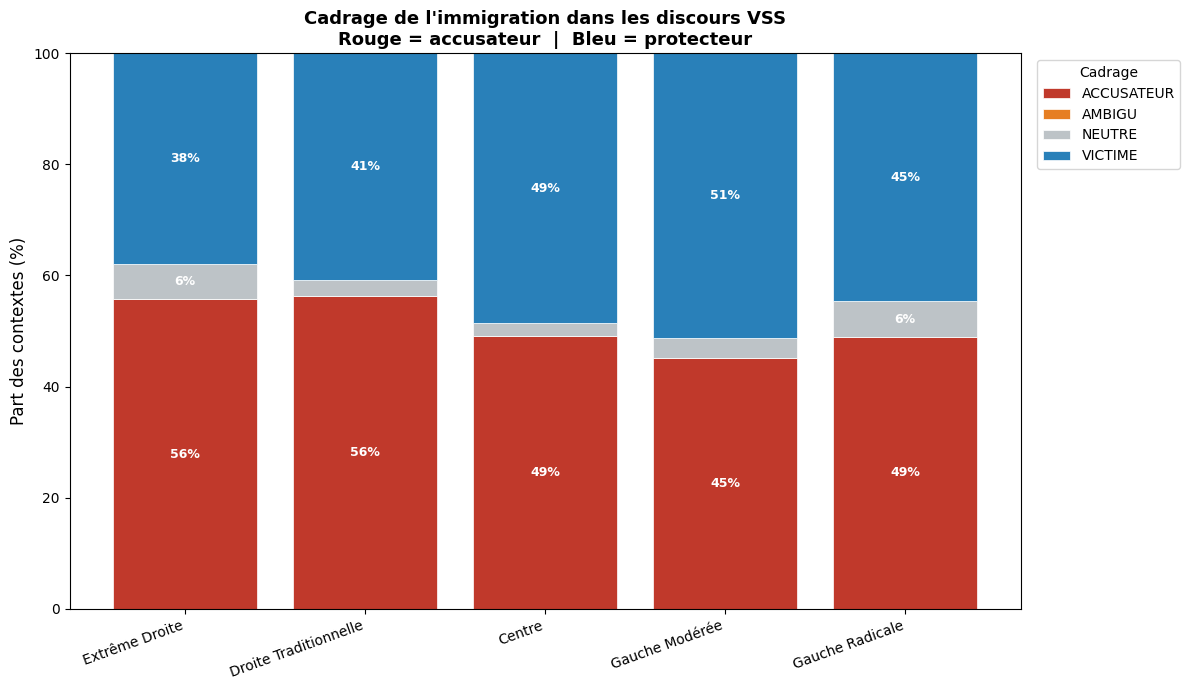

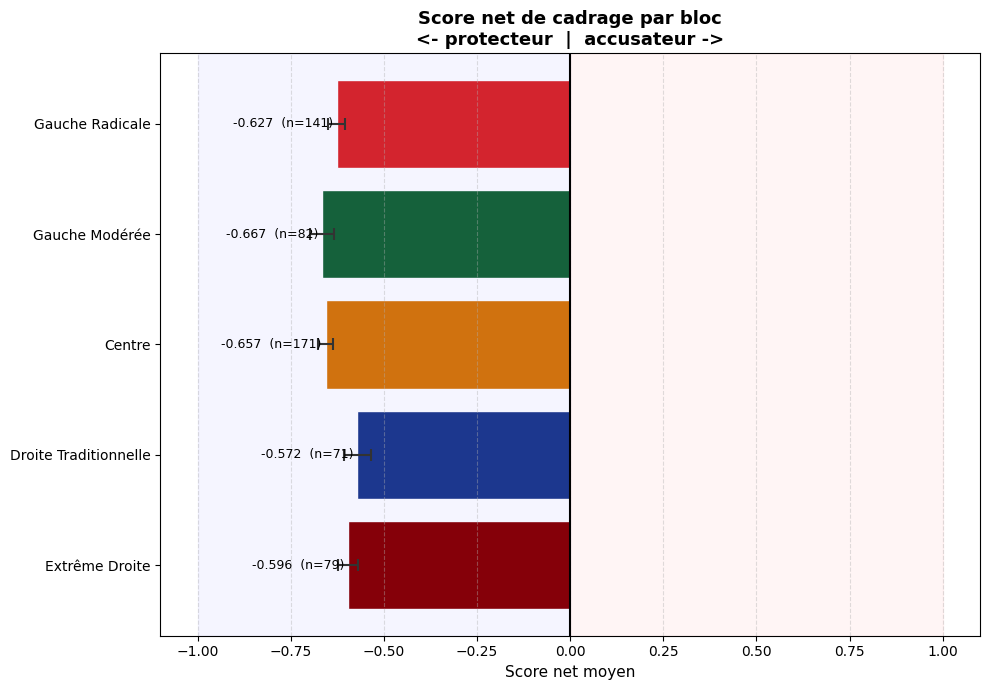

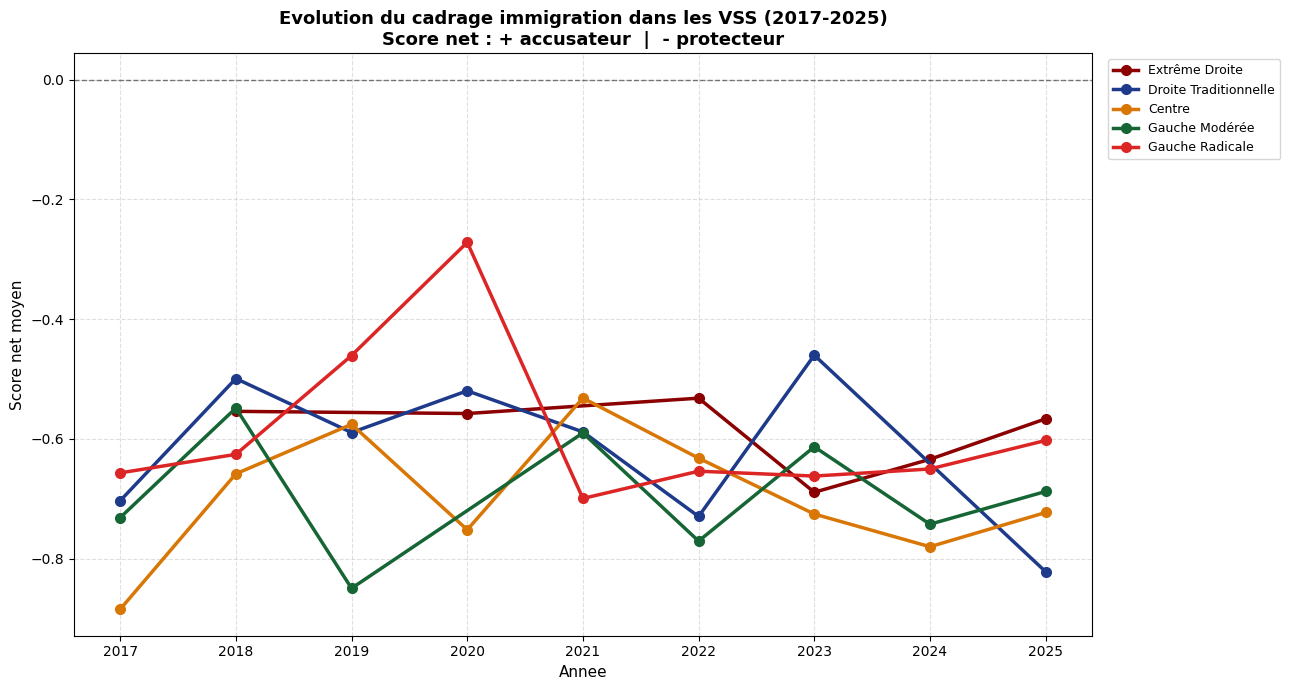


VALIDATION QUALITATIVE

─────────────────────────────────────────────────────────────────
  EXTRÊME DROITE  —  79 contextes
  Score net moyen : -0.596
  Cadrages : {'ACCUSATEUR': 44, 'VICTIME': 30, 'NEUTRE': 5}

  [ACCUSATEUR]
    [Front National] "Par cet amendement, nous proposons d’expulser systématiquement tout étranger coupable d’une agression sexuelle Les faits divers de cet ordre se multiplient, et rien n’est fait Vous voulez lutter contre les violences sexu..."
    [Front National] "Lorsque les auteurs de telles violences sont étrangers, il faut les expulser de notre territoire : par leurs actes, par leur mépris pour les lois les plus élémentaires, ils montrent en effet leur volonté de ne pas s’inté..."

  [VICTIME]
    [Front National] "Hier encore, dans trois quartiers sensibles de Nantes, ils ont été confrontés à un déchaînement de violences intolérable à la suite d’une riposte visant un individu menaçant qui faisait l’objet d’un mandat d’arrêt N’en d..."
    [Front Nationa

In [30]:
"""
ANALYSE DE CADRAGE VSS x IMMIGRATION - VERSION 3
Corrections : extraction large + NLI zero-shot pour la direction semantique
"""

import re, os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from tqdm import tqdm
import torch
from transformers import pipeline as hf_pipeline

COULEURS_BLOCS = {
    "Extreme Droite":        "#8B0000",
    "Droite Traditionnelle": "#1E3A8A",
    "Centre":                "#D97706",
    "Gauche Moderee":        "#166534",
    "Gauche Radicale":       "#DC2626"
}
ORDRE_BLOCS = ["Extreme Droite","Droite Traditionnelle","Centre","Gauche Moderee","Gauche Radicale"]
ORDRE_BLOCS_FR = ["Extrême Droite","Droite Traditionnelle","Centre","Gauche Modérée","Gauche Radicale"]

GROUPES_CIBLES = [
    r"immigr", r"clandestin", r"étranger", r"migrant", r"réfugié",
    r"sans.papier", r"islam", r"musulman", r"maghrébin",
    r"africain", r"arabe", r"communauté", r"confession",
]
MOTS_VSS = [
    r"viol", r"agress", r"harcèl", r"féminicide", r"violence",
    r"victime", r"sexuel", r"conjugal", r"inceste", r"mutilation", r"prostitu",
]

HYPOTHESES = {
    "accusateur": (
        "Ce texte presente l immigration ou les etrangers comme la cause "
        "ou les responsables des violences sexistes et sexuelles."
    ),
    "victime": (
        "Ce texte presente les immigres etrangers ou minorites religieuses "
        "comme des victimes de violences ou de discriminations."
    ),
    "denonciation": (
        "Ce texte denonce ou critique le fait d associer l immigration "
        "aux violences sexistes et sexuelles."
    ),
}

NLI_MODEL = "cross-encoder/nli-MiniLM2-L6-H768"

DENONCIATION_RULES = [
    r"(stigmatis|diabolisé|montré du doigt|bouc émissaire)",
    r"amalgam\w*",
    r"raccourci\w* (facile|dangereux|honteux)",
    r"instrumentalis\w*",
    r"récupération (politique|électorale|identitaire)",
    r"(ne|n.?) (faut|peut|doit)\w* pas.{0,30}lien",
    r"(faux|mauvais|dangereux) (lien|raccourci|amalgame)",
    r"définir\w*.{0,30}(violeur|agresseur).{0,30}étranger",
]
ACCUSATEUR_RULES = [
    r"(immigr\w*|clandestin\w*|étranger\w*|musulman\w*).{0,40}(viol\w*|agress\w*|commet\w*|perpètr\w*)",
    r"(viol\w*|agress\w*|violence\w*).{0,30}(commis|perpétr)\w*.{0,20}(immigr\w*|clandestin\w*|étranger\w*)",
    r"(à cause de|du fait de).{0,20}(l.immigration|clandestin|leur culture|l.islam)",
    r"(import[ée]\w*|apporté\w* (de|par))",
    r"(nos femmes|nos filles).{0,30}(protéger|menac|agress|danger)",
    r"(invasion|ensauvagement|grand remplacement|islamisation)",
    r"(leur culture|leur mentalité|leur rapport à la femme|vision de la femme)",
    r"(étranger\w*|immigr\w*).{0,30}condamné\w*.{0,20}(viol|agress)",
]
VICTIME_RULES = [
    r"(immigr\w*|étranger\w*|migrant\w*|musulman\w*|réfugié\w*).{0,40}(victim\w*|subiss\w*|agress[ée]\w*|discrimin\w*)",
    r"(protéger|défendre|accompagner|soutenir|aider).{0,25}(immigr\w*|migrant\w*|sans.papier\w*|réfugié\w*)",
    r"(doublement|vulnérable|plus exposée|davantage exposée)",
    r"(bouc[s]? émissaire[s]?|stigmatis\w*)",
    r"(islamophobie|xénophobie|racisme).{0,30}(contre|envers|visant)",
]


def extraire_contextes_larges(df_vss, fenetre_phrases=2):
    pat_groupe = re.compile(r"(?i)(" + "|".join(GROUPES_CIBLES) + r")\w*")
    pat_vss    = re.compile(r"(?i)(" + "|".join(MOTS_VSS)        + r")\w*")
    print("Extraction des contextes VSS x groupe cible (fenêtre élargie)...")
    resultats = []
    for _, row in tqdm(df_vss.iterrows(), total=len(df_vss)):
        texte = str(row.get("texte", ""))
        bloc  = row.get("bloc")
        if not texte or pd.isna(bloc):
            continue
        phrases = [p.strip() for p in re.split(r"[.!?;]+", texte) if len(p.strip().split()) >= 5]
        n = len(phrases)
        for i, phrase in enumerate(phrases):
            a_vss    = bool(pat_vss.search(phrase))
            a_groupe = bool(pat_groupe.search(phrase))
            if a_vss and a_groupe:
                contexte = phrase
                mode = "directe"
            elif a_vss:
                voisines = phrases[max(0,i-fenetre_phrases):i] + phrases[i+1:min(n,i+fenetre_phrases+1)]
                if any(pat_groupe.search(v) for v in voisines):
                    contexte = " ".join(phrases[max(0,i-fenetre_phrases):min(n,i+fenetre_phrases+1)])
                    mode = "fenetre"
                else:
                    continue
            else:
                continue
            resultats.append({
                "contexte":  contexte,
                "bloc":      bloc,
                "nom_parti": row.get("nom_parti"),
                "date":      row.get("date"),
                "mode":      mode,
            })
    df = pd.DataFrame(resultats).drop_duplicates(subset="contexte")
    print(f"-> {len(df)} contextes extraits  {df['mode'].value_counts().to_dict()}")
    print(df["bloc"].value_counts().to_string())
    return df


class ClassifieurNLI:
    def __init__(self):
        print(f"\nChargement du modèle NLI : {NLI_MODEL}")
        device = 0 if torch.cuda.is_available() else -1
        try:
            self.clf = hf_pipeline(
                "zero-shot-classification",
                model=NLI_MODEL,
                device=device,
                multi_label=True,
            )
            self.ok = True
            print("Modele NLI charge.")
        except Exception as e:
            print(f"NLI indisponible ({e}). Fallback sur regles.")
            self.ok = False

    def scorer_batch(self, textes, batch_size=16):
        if not self.ok:
            return None
        labels  = list(HYPOTHESES.keys())
        phrases = list(HYPOTHESES.values())
        records = []
        for i in tqdm(range(0, len(textes), batch_size), desc="NLI scoring"):
            batch = [t[:1500] for t in textes[i:i+batch_size]]
            try:
                outs = self.clf(batch, candidate_labels=phrases, multi_label=True)
                if isinstance(outs, dict):
                    outs = [outs]
                for out in outs:
                    row = {}
                    for lbl, ph in HYPOTHESES.items():
                        idx = out["labels"].index(ph)
                        row[f"score_{lbl}"] = out["scores"][idx]
                    records.append(row)
            except Exception:
                records.extend([{f"score_{l}": 0.33 for l in labels}] * len(batch))
        return pd.DataFrame(records)


def determiner_cadrage_nli(row):
    acc = row.get("score_accusateur",   0)
    vic = row.get("score_victime",      0)
    den = row.get("score_denonciation", 0)
    SEUIL = 0.45
    if den > SEUIL and den > acc:
        return "VICTIME"
    if acc > SEUIL and acc > max(vic, den):
        return "ACCUSATEUR"
    if vic > SEUIL and vic > max(acc, den):
        return "VICTIME"
    if acc > vic + 0.1:
        return "ACCUSATEUR"
    if vic > acc + 0.1:
        return "VICTIME"
    return "NEUTRE"


def scoring_regle(contexte):
    t = contexte.lower()
    n_den = sum(1 for p in DENONCIATION_RULES if re.search(p, t, re.I))
    n_acc = sum(1 for p in ACCUSATEUR_RULES  if re.search(p, t, re.I))
    n_vic = sum(1 for p in VICTIME_RULES     if re.search(p, t, re.I))
    score_net = n_acc - n_vic - n_den * 1.5
    if n_den > 0 and n_den >= n_acc:
        cadrage = "VICTIME"
    elif n_acc > 0 and score_net > 0:
        cadrage = "ACCUSATEUR"
    elif n_vic > 0 or n_den > 0:
        cadrage = "VICTIME"
    else:
        cadrage = "NEUTRE"
    return {"n_accusateur": n_acc, "n_victime": n_vic, "n_denonciation": n_den,
            "score_net": score_net, "cadrage": cadrage}


def tracer_barres_empilees(df, output_dir=None):
    if output_dir: os.makedirs(output_dir, exist_ok=True)
    blocs_presents = [b for b in ORDRE_BLOCS_FR if b in df["bloc"].unique()]
    counts = (df.groupby(["bloc","cadrage"]).size().unstack(fill_value=0)
              .reindex(blocs_presents))
    pct = counts.div(counts.sum(axis=1), axis=0) * 100
    for col in ["ACCUSATEUR","AMBIGU","NEUTRE","VICTIME"]:
        if col not in pct.columns: pct[col] = 0.0
    coul = {"ACCUSATEUR":"#C0392B","AMBIGU":"#E67E22","NEUTRE":"#BDC3C7","VICTIME":"#2980B9"}
    fig, ax = plt.subplots(figsize=(12, 7))
    bottom = np.zeros(len(pct))
    for cat in ["ACCUSATEUR","AMBIGU","NEUTRE","VICTIME"]:
        vals = pct[cat].values
        ax.bar(pct.index, vals, bottom=bottom, color=coul[cat], label=cat, edgecolor="white", lw=0.5)
        for i, (v, b) in enumerate(zip(vals, bottom)):
            if v > 5:
                ax.text(i, b+v/2, f"{v:.0f}%", ha="center", va="center",
                        fontsize=9, color="white", fontweight="bold")
        bottom += vals
    ax.set_ylim(0,100)
    ax.set_ylabel("Part des contextes (%)", fontsize=12)
    ax.set_title("Cadrage de l'immigration dans les discours VSS\nRouge = accusateur  |  Bleu = protecteur",
                 fontsize=13, fontweight="bold")
    ax.legend(title="Cadrage", bbox_to_anchor=(1.01,1), loc="upper left")
    plt.xticks(rotation=20, ha="right")
    plt.tight_layout()
    if output_dir: plt.savefig(os.path.join(output_dir,"barres_cadrage_v3.png"), dpi=150, bbox_inches="tight")
    plt.show()


def tracer_score_net(df, output_dir=None):
    if output_dir: os.makedirs(output_dir, exist_ok=True)
    stats = (df.groupby("bloc")["score_net"]
             .agg(["mean","sem","count"])
             .rename(columns={"mean":"m","sem":"e","count":"n"})
             .reset_index())
    stats = stats[stats["bloc"].isin(ORDRE_BLOCS_FR)]
    stats["bloc"] = pd.Categorical(stats["bloc"], categories=ORDRE_BLOCS_FR, ordered=True)
    stats = stats.sort_values("bloc")
    coul = [COULEURS_BLOCS.get(b.replace("é","e").replace("è","e").replace("ê","e"), "gray")
            for b in stats["bloc"]]
    fig, ax = plt.subplots(figsize=(10,7))
    ax.barh(stats["bloc"], stats["m"], xerr=stats["e"], color=coul,
            edgecolor="white", capsize=4,
            error_kw={"elinewidth":1.5,"ecolor":"#333","capthick":1.5})
    ax.axvline(0, color="black", lw=1.5)
    ax.axvspan(-1,0, alpha=0.04, color="blue")
    ax.axvspan(0,1,  alpha=0.04, color="red")
    for i, row in enumerate(stats.itertuples()):
        x = row.m
        ax.text(x+(0.01 if x>=0 else -0.01), i,
                f"  {x:.3f}  (n={int(row.n)})",
                va="center", ha="left" if x>=0 else "right", fontsize=9)
    ax.set_title("Score net de cadrage par bloc\n<- protecteur  |  accusateur ->",
                 fontsize=13, fontweight="bold")
    ax.set_xlabel("Score net moyen", fontsize=11)
    ax.grid(axis="x", linestyle="--", alpha=0.4)
    plt.tight_layout()
    if output_dir: plt.savefig(os.path.join(output_dir,"score_net_v3.png"), dpi=150, bbox_inches="tight")
    plt.show()


def tracer_evolution(df, output_dir=None):
    if output_dir: os.makedirs(output_dir, exist_ok=True)
    d = df.copy()
    d["date"]  = pd.to_datetime(d["date"])
    d["annee"] = d["date"].dt.year
    evol = d.groupby(["annee","bloc"])["score_net"].mean().reset_index()
    evol = evol[evol["bloc"].isin(ORDRE_BLOCS_FR)]
    fig, ax = plt.subplots(figsize=(13,7))
    for bloc in ORDRE_BLOCS_FR:
        sub = evol[evol["bloc"]==bloc].sort_values("annee")
        if sub.empty: continue
        cle = bloc.replace("é","e").replace("è","e").replace("ê","e")
        ax.plot(sub["annee"], sub["score_net"], marker="o", label=bloc,
                color=COULEURS_BLOCS.get(cle,"gray"), lw=2.5, markersize=7)
    ax.axhline(0, color="black", lw=1, ls="--", alpha=0.5)
    ax.set_title("Evolution du cadrage immigration dans les VSS (2017-2025)\nScore net : + accusateur  |  - protecteur",
                 fontsize=13, fontweight="bold")
    ax.set_xlabel("Annee", fontsize=11)
    ax.set_ylabel("Score net moyen", fontsize=11)
    ax.legend(bbox_to_anchor=(1.01,1), loc="upper left", fontsize=9)
    ax.grid(ls="--", alpha=0.4)
    plt.tight_layout()
    if output_dir: plt.savefig(os.path.join(output_dir,"evolution_v3.png"), dpi=150, bbox_inches="tight")
    plt.show()


def afficher_exemples(df, n=2):
    print("\n" + "="*80)
    print("VALIDATION QUALITATIVE")
    print("="*80)
    for bloc in ORDRE_BLOCS_FR:
        sub = df[df["bloc"]==bloc]
        if sub.empty: continue
        print(f"\n{'─'*65}")
        print(f"  {bloc.upper()}  —  {len(sub)} contextes")
        print(f"  Score net moyen : {sub['score_net'].mean():.3f}")
        print(f"  Cadrages : {sub['cadrage'].value_counts().to_dict()}")
        for cadrage in ["ACCUSATEUR","VICTIME"]:
            sous = sub[sub["cadrage"]==cadrage].head(n)
            if sous.empty: continue
            print(f"\n  [{cadrage}]")
            for _, row in sous.iterrows():
                txt = row["contexte"][:220]+"..." if len(row["contexte"])>220 else row["contexte"]
                print(f"    [{row['nom_parti']}] \"{txt}\"")


def pipeline_v3(df_vss, output_dir=None, use_nli=True, fenetre=2):
    print("="*80)
    print("ANALYSE DE CADRAGE VSS x IMMIGRATION  --  v3")
    print("="*80)
    if output_dir: os.makedirs(output_dir, exist_ok=True)
    if "bloc" not in df_vss.columns:
        raise ValueError("Colonne 'bloc' manquante.")
    df_vss = df_vss.dropna(subset=["bloc"]).copy()
    df = extraire_contextes_larges(df_vss, fenetre_phrases=fenetre)
    if df.empty:
        print("Aucun contexte extrait.")
        return None
    if use_nli:
        clf = ClassifieurNLI()
        if clf.ok:
            print("\nScoring NLI zero-shot...")
            scores_df = clf.scorer_batch(df["contexte"].tolist())
            df = pd.concat([df.reset_index(drop=True), scores_df], axis=1)
            df["cadrage"]   = df.apply(determiner_cadrage_nli, axis=1)
            df["score_net"] = df["score_accusateur"] - df["score_victime"] - df["score_denonciation"]
        else:
            use_nli = False
    if not use_nli:
        print("\nScoring par regles syntaxiques (fallback)...")
        scores = df["contexte"].apply(scoring_regle)
        df = pd.concat([df.reset_index(drop=True), pd.DataFrame(scores.tolist())], axis=1)
    print(f"\nDistribution des cadrages :\n{df['cadrage'].value_counts().to_string()}")
    print("\nGeneration des graphiques...")
    tracer_barres_empilees(df, output_dir)
    tracer_score_net(df, output_dir)
    tracer_evolution(df, output_dir)
    afficher_exemples(df)
    print("\nSYNTHESE PAR BLOC :")
    syn = (df.groupby("bloc").agg(
        n=("contexte","count"),
        score_net_moyen=("score_net","mean"),
        pct_accusateur=("cadrage", lambda x: (x=="ACCUSATEUR").mean()*100),
        pct_victime   =("cadrage", lambda x: (x=="VICTIME"   ).mean()*100),
        pct_neutre    =("cadrage", lambda x: (x=="NEUTRE"    ).mean()*100),
    ).round(2))
    print(syn.to_string())
    if output_dir:
        df.to_csv(os.path.join(output_dir,"cadrage_v3.csv"), index=False, encoding="utf-8-sig")
        df.to_pickle(os.path.join(output_dir,"df_cadrage_v3.pkl"))
        print(f"\nSauvegarde dans {output_dir}")
    print("\nAnalyse v3 terminee.")
    return df


if __name__ == "__main__":
    chemin     = "/home/onyxia/work/projet_eco_socio/df_vss_propre.pkl"
    output_dir = "/home/onyxia/work/projet_eco_socio/analyses_cadrage_v3/"
    df_vss = pd.read_pickle(chemin)
    print(f"{len(df_vss)} prises de parole chargees.")
    if "bloc" not in df_vss.columns:
        def _bloc(nom):
            nom = str(nom).lower()
            if any(x in nom for x in ["rassemblement national","front national","udr"]): return "Extrême Droite"
            if "républicains" in nom: return "Droite Traditionnelle"
            if any(c in nom for c in ["en marche","renaissance","ensemble","modem","horizons"]): return "Centre"
            if any(g in nom for g in ["socialiste","écologistes","europe écologie","radical"]): return "Gauche Modérée"
            if any(g in nom for g in ["france insoumise","communiste","lfi"]): return "Gauche Radicale"
            return None
        df_vss["bloc"] = df_vss["nom_parti"].apply(_bloc)
    df_cadrage = pipeline_v3(df_vss, output_dir=output_dir, use_nli=True, fenetre=2)

Chargement des données...
ANALYSE DE CADRAGE VSS × IMMIGRATION (v3 – IA / ZERO-SHOT)
⏳ Chargement du modèle NLP (mDeBERTa-v3-base-mnli-xnli)...


Loading weights: 100%|██████████| 202/202 [00:00<00:00, 654.58it/s, Materializing param=pooler.dense.weight]                                       
DebertaV2ForSequenceClassification LOAD REPORT from: MoritzLaurer/mDeBERTa-v3-base-mnli-xnli
Key                             | Status     |  | 
--------------------------------+------------+--+-
deberta.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


✅ Modèle chargé avec succès.
🔍 Extraction et analyse NLP des phrases (cela peut prendre quelques minutes)...


100%|██████████| 10380/10380 [18:48<00:00,  9.20it/s] 



→ 212 phrases de co-occurrence extraites et analysées par l'IA.

Répartition des cadrages trouvés :
cadrage
VICTIME       112
ACCUSATEUR     67
NEUTRE         33

Génération des graphiques...


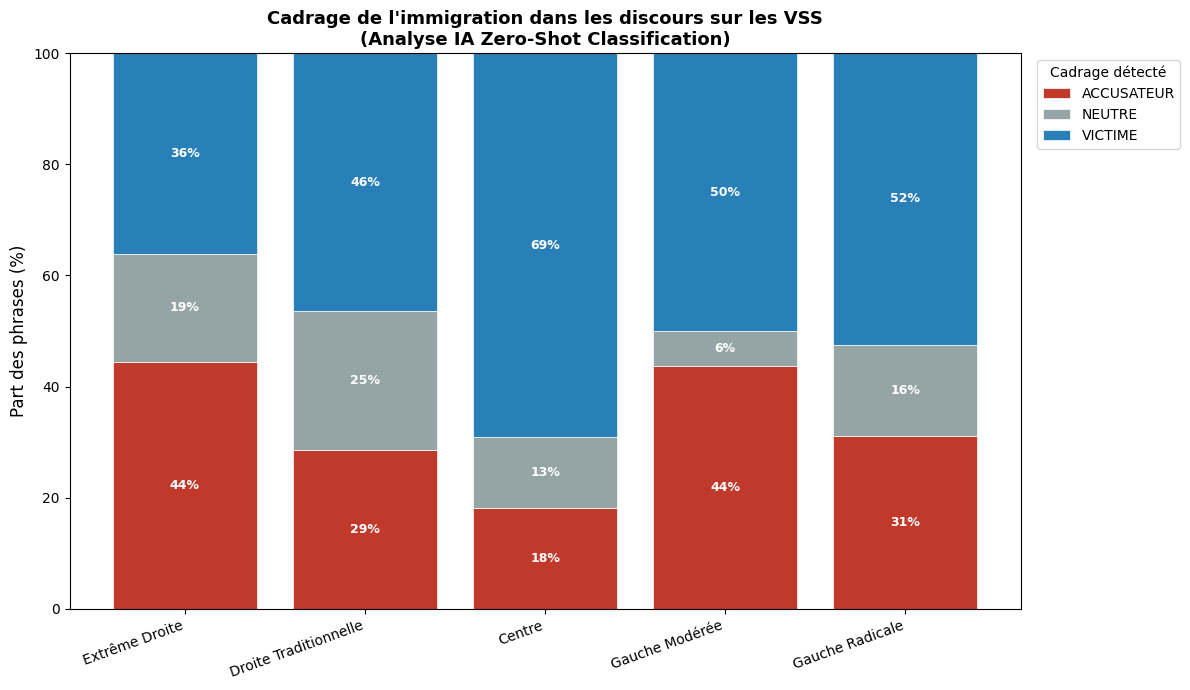

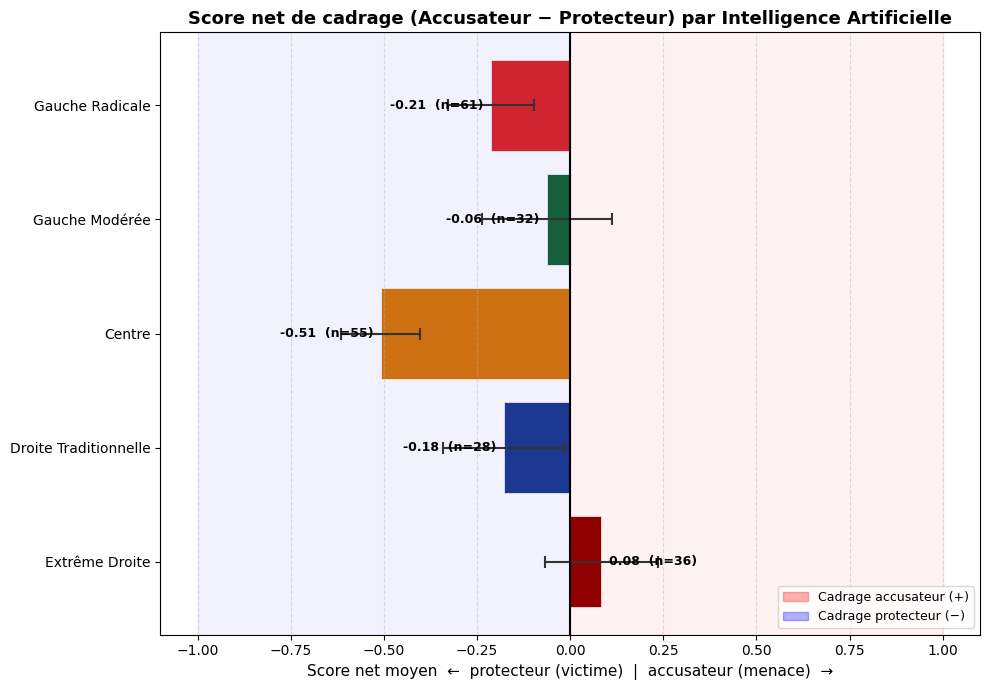


🔍 EXEMPLES DE CLASSIFICATION PAR L'IA :

[ACCUSATEUR]
  - (La France Insoumise) Confiance: 0.50 -> "Les violences envers les femmes ne connaissent aucune frontière, elles traversent toutes les classes sociales et tous les milieux culturels"
  - (Parti socialiste) Confiance: 0.72 -> "Nous proposons d’exclure, par principe, de la liste des pays sûrs au sens du code de l’entrée et du séjour des étrangers et du droit d’asile – CESEDA – des pays qui pratiquent des discriminations fondées sur l’orientation sexuelle ou l’identité de genre"

[VICTIME]
  - (Les Républicains) Confiance: 0.65 -> "L’Observatoire national des violences faites aux femmes a noté qu’en 2014, 4 % des femmes immigrées en France et 2 % des filles nées en France âgées de vingt-six à cinquante ans ont subi un mariage non consenti"
  - (Les Républicains) Confiance: 0.88 -> "En France, 4 % des femmes immigrées et 2 % des filles d’immigrés nées en France ont subi des mutilations sexuelles"

[NEUTRE]
  - (La République en Mar

In [31]:
"""
============================================================================
ANALYSE DE CADRAGE VSS × IMMIGRATION – VERSION 3 (ZERO-SHOT CLASSIFICATION)
============================================================================
Utilisation de modèles NLP avancés (Transformers / mDeBERTa) pour comprendre
le sens sémantique de la phrase et le rôle attribué à l'immigration, 
plutôt que de simples expressions régulières.
============================================================================
"""

import re
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from tqdm import tqdm
import torch
from transformers import pipeline

# ============================================================================
# CONFIGURATION
# ============================================================================

COULEURS_BLOCS = {
    "Extrême Droite":       "#8B0000",
    "Droite Traditionnelle":"#1E3A8A",
    "Centre":               "#D97706",
    "Gauche Modérée":       "#166534",
    "Gauche Radicale":      "#DC2626"
}
ORDRE_BLOCS = ["Extrême Droite", "Droite Traditionnelle", "Centre", "Gauche Modérée", "Gauche Radicale"]

# --- Groupes cibles (immigration/religion) pour le PRE-FILTRAGE ---
GROUPES_CIBLES = [
    "immigr", "clandestin", "étranger", "migrant", "réfugié",
    "sans-papier", "islam", "musulman", "maghrébin", "africain",
    "arabe", "communauté", "confession", "origine étrangère", "frontière"
]

# --- Mots VSS pour le PRE-FILTRAGE ---
MOTS_VSS_VIOLENCE = [
    "viol", "agress", "harcèl", "féminicide", "violence", "victime",
    "sexuel", "conjugal", "inceste", "mutilation", "prostitution"
]

# ============================================================================
# NLP : PIPELINE ZERO-SHOT CLASSIFICATION
# ============================================================================

# On définit nos classes (le modèle va calculer une probabilité pour chacune)
CANDIDAT_LABELS = [
    "l'immigration ou la culture étrangère est la cause des violences sexuelles et sexistes",
    "les personnes immigrées ou les minorités sont victimes de violences sexuelles et sexistes",
    "la déclaration est neutre, administrative ou évoque l'immigration sans l'accuser ni la victimiser"
]

def initialiser_modele_nlp():
    print("⏳ Chargement du modèle NLP (mDeBERTa-v3-base-mnli-xnli)...")
    # Utilisation du GPU s'il est disponible (accélère grandement le traitement)
    device = 0 if torch.cuda.is_available() else -1
    
    # Ce modèle est excellent pour le zero-shot multilingue (dont le français)
    classifier = pipeline(
        "zero-shot-classification",
        model="MoritzLaurer/mDeBERTa-v3-base-mnli-xnli",
        device=device
    )
    print("✅ Modèle chargé avec succès.")
    return classifier

def analyser_phrase_nlp(phrase, classifier):
    """
    Passe la phrase dans le Transformer pour déterminer le cadrage.
    """
    resultat = classifier(phrase, CANDIDAT_LABELS, multi_label=False)
    
    label_gagnant = resultat['labels'][0]
    score_confiance = resultat['scores'][0]
    
    # Mapping vers nos catégories
    if label_gagnant == CANDIDAT_LABELS[0]:
        cadrage = "ACCUSATEUR"
        score_net = 1
    elif label_gagnant == CANDIDAT_LABELS[1]:
        cadrage = "VICTIME"
        score_net = -1
    else:
        cadrage = "NEUTRE"
        score_net = 0
        
    return {
        "cadrage": cadrage,
        "score_net": score_net,
        "confiance_nlp": score_confiance,
        "label_nlp": label_gagnant
    }

# ============================================================================
# EXTRACTION ET SCORING
# ============================================================================

def extraire_et_scorer_phrases_nlp(df_vss, classifier):
    """
    Étape 1 : Filtre les phrases contenant au moins un mot VSS ET un mot Identitaire.
    Étape 2 : Passe ces phrases au modèle NLP pour classification sémantique.
    """
    pattern_groupe = re.compile(
        r'(?i)\b(' + '|'.join([re.escape(m) for m in GROUPES_CIBLES]) + r')\w*\b'
    )
    pattern_vss = re.compile(
        r'(?i)\b(' + '|'.join([re.escape(m) for m in MOTS_VSS_VIOLENCE]) + r')\w*\b'
    )

    print("🔍 Extraction et analyse NLP des phrases (cela peut prendre quelques minutes)...")
    resultats = []

    # On parcours les textes
    for _, row in tqdm(df_vss.iterrows(), total=len(df_vss)):
        texte = str(row.get('texte', ''))
        bloc = row.get('bloc')
        nom_parti = row.get('nom_parti')
        date = row.get('date')

        if not texte or pd.isna(bloc):
            continue

        phrases = re.split(r'[.!?;]+', texte)

        for phrase in phrases:
            phrase = phrase.strip()
            if len(phrase.split()) < 6: # Trop court pour avoir du sens
                continue

            # PRE-FILTRAGE RAPIDE : Est-ce que la phrase parle des deux sujets ?
            a_vss = bool(pattern_vss.search(phrase))
            a_groupe = bool(pattern_groupe.search(phrase))

            if not (a_vss and a_groupe):
                continue

            # ANALYSE NLP PROFONDE
            analyse = analyser_phrase_nlp(phrase, classifier)

            resultats.append({
                "phrase":        phrase,
                "bloc":          bloc,
                "nom_parti":     nom_parti,
                "date":          date,
                **analyse
            })

    df = pd.DataFrame(resultats)
    print(f"\n→ {len(df)} phrases de co-occurrence extraites et analysées par l'IA.")
    if not df.empty:
        print("\nRépartition des cadrages trouvés :")
        print(df['cadrage'].value_counts().to_string())
    return df

# ============================================================================
# VISUALISATIONS 
# ============================================================================

def tracer_cadrage_par_bloc(df, output_dir=None):
    if output_dir:
        os.makedirs(output_dir, exist_ok=True)

    counts = (
        df.groupby(['bloc', 'cadrage'])
        .size()
        .unstack(fill_value=0)
        .reindex([b for b in ORDRE_BLOCS if b in df['bloc'].unique()])
    )
    pct = counts.div(counts.sum(axis=1), axis=0) * 100

    for col in ['ACCUSATEUR', 'NEUTRE', 'VICTIME']:
        if col not in pct.columns:
            pct[col] = 0

    couleurs_cadrage = {
        'ACCUSATEUR': '#C0392B', # Rouge
        'NEUTRE':     '#95A5A6', # Gris
        'VICTIME':    '#2980B9'  # Bleu
    }

    fig, ax = plt.subplots(figsize=(12, 7))
    bottom = np.zeros(len(pct))

    for cadrage in ['ACCUSATEUR', 'NEUTRE', 'VICTIME']:
        vals = pct[cadrage].values
        bars = ax.bar(pct.index, vals, bottom=bottom,
                      color=couleurs_cadrage[cadrage], label=cadrage,
                      edgecolor='white', linewidth=0.5)
        for i, (v, b) in enumerate(zip(vals, bottom)):
            if v > 4:
                ax.text(i, b + v / 2, f"{v:.0f}%",
                        ha='center', va='center', fontsize=9,
                        color='white', fontweight='bold')
        bottom += vals

    ax.set_ylim(0, 100)
    ax.set_ylabel("Part des phrases (%)", fontsize=12)
    ax.set_title(
        "Cadrage de l'immigration dans les discours sur les VSS\n(Analyse IA Zero-Shot Classification)",
        fontsize=13, fontweight='bold'
    )
    ax.legend(title="Cadrage détecté", bbox_to_anchor=(1.01, 1), loc='upper left')
    plt.xticks(rotation=20, ha='right')
    plt.tight_layout()

    if output_dir:
        plt.savefig(os.path.join(output_dir, "cadrage_nlp_par_bloc.png"), dpi=150, bbox_inches='tight')
    plt.show()

def tracer_score_net_par_bloc(df, output_dir=None):
    if output_dir:
        os.makedirs(output_dir, exist_ok=True)

    stats = (
        df.groupby('bloc')['score_net']
        .agg(['mean', 'sem', 'count'])
        .rename(columns={'mean': 'score_moyen', 'sem': 'erreur', 'count': 'n'})
        .reset_index()
    )
    stats = stats[stats['bloc'].isin(ORDRE_BLOCS)]
    stats['bloc'] = pd.Categorical(stats['bloc'], categories=ORDRE_BLOCS, ordered=True)
    stats = stats.sort_values('bloc')

    couleurs = [COULEURS_BLOCS.get(b, 'gray') for b in stats['bloc']]

    fig, ax = plt.subplots(figsize=(10, 7))

    bars = ax.barh(
        stats['bloc'], stats['score_moyen'],
        xerr=stats['erreur'],
        color=couleurs, edgecolor='white', linewidth=0.5,
        capsize=4, error_kw={'elinewidth': 1.5, 'ecolor': '#333', 'capthick': 1.5}
    )

    ax.axvline(x=0, color='black', linewidth=1.5)
    ax.axvspan(-1, 0, alpha=0.05, color='blue')
    ax.axvspan(0, 1, alpha=0.05, color='red')

    for bar, (_, row) in zip(bars, stats.iterrows()):
        x = bar.get_width()
        offset = 0.02 if x >= 0 else -0.02
        ax.text(x + offset, bar.get_y() + bar.get_height() / 2,
                f"{row['score_moyen']:.2f}  (n={int(row['n'])})",
                va='center', ha='left' if x >= 0 else 'right',
                fontsize=9, fontweight='bold')

    ax.set_title(
        "Score net de cadrage (Accusateur − Protecteur) par Intelligence Artificielle",
        fontsize=13, fontweight='bold'
    )
    ax.set_xlabel("Score net moyen  ←  protecteur (victime)  |  accusateur (menace)  →", fontsize=11)

    patch_acc = mpatches.Patch(color='red', alpha=0.3, label='Cadrage accusateur (+)')
    patch_vic = mpatches.Patch(color='blue', alpha=0.3, label='Cadrage protecteur (−)')
    ax.legend(handles=[patch_acc, patch_vic], loc='lower right', fontsize=9)
    ax.grid(axis='x', linestyle='--', alpha=0.4)
    plt.tight_layout()

    if output_dir:
        plt.savefig(os.path.join(output_dir, "score_net_nlp.png"), dpi=150, bbox_inches='tight')
    plt.show()

# ============================================================================
# PIPELINE PRINCIPAL
# ============================================================================

def pipeline_cadrage_nlp(df_vss, output_dir=None):
    print("=" * 80)
    print("ANALYSE DE CADRAGE VSS × IMMIGRATION (v3 – IA / ZERO-SHOT)")
    print("=" * 80)

    df_vss = df_vss.dropna(subset=['bloc']).copy()

    # 1. Chargement modèle IA
    classifier = initialiser_modele_nlp()

    # 2. Extraction + scoring
    df_phrases = extraire_et_scorer_phrases_nlp(df_vss, classifier)
    if df_phrases is None or df_phrases.empty:
        print("⚠️ Aucune phrase extraite.")
        return None

    # 3. Graphiques
    print("\nGénération des graphiques...")
    tracer_cadrage_par_bloc(df_phrases, output_dir)
    tracer_score_net_par_bloc(df_phrases, output_dir)

    # 4. Exemples qualitatifs pour voir ce que l'IA a compris
    print("\n🔍 EXEMPLES DE CLASSIFICATION PAR L'IA :")
    for cadrage in ['ACCUSATEUR', 'VICTIME', 'NEUTRE']:
        print(f"\n[{cadrage}]")
        sous = df_phrases[df_phrases['cadrage'] == cadrage].head(2)
        for _, row in sous.iterrows():
            print(f"  - ({row['nom_parti']}) Confiance: {row['confiance_nlp']:.2f} -> \"{row['phrase']}\"")

    # 5. Sauvegarde
    if output_dir:
        os.makedirs(output_dir, exist_ok=True)
        df_phrases.to_csv(os.path.join(output_dir, "phrases_cadrage_nlp.csv"), index=False, encoding='utf-8-sig')
        df_phrases.to_pickle(os.path.join(output_dir, "df_phrases_cadrage_nlp.pkl"))
        print(f"\n💾 Sauvegardé dans {output_dir}")

    print("\n✅ Analyse v3 (NLP) terminée.")
    return df_phrases


if __name__ == "__main__":
    chemin = "/home/onyxia/work/projet_eco_socio/df_vss_propre.pkl"
    output_dir = "/home/onyxia/work/projet_eco_socio/analyses_sentiment_v3_nlp/"

    print("Chargement des données...")
    df_vss = pd.read_pickle(chemin)
    
    # Création des blocs (au cas où)
    def regrouper_blocs_ideologiques(nom):
        nom = str(nom).lower()
        if any(x in nom for x in ["rassemblement national", "front national", "udr"]): return "Extrême Droite"
        if "républicains" in nom: return "Droite Traditionnelle"
        if any(c in nom for c in ["en marche", "renaissance", "ensemble", "modem", "horizons"]): return "Centre"
        if any(g in nom for g in ["socialiste", "écologistes", "europe écologie", "radical"]): return "Gauche Modérée"
        if any(g in nom for g in ["france insoumise", "communiste", "lfi"]): return "Gauche Radicale"
        return None

    if 'bloc' not in df_vss.columns:
        df_vss['bloc'] = df_vss['nom_parti'].apply(regrouper_blocs_ideologiques)

    df_phrases_nlp = pipeline_cadrage_nlp(df_vss, output_dir=output_dir)

In [32]:
pip install torch

Note: you may need to restart the kernel to use updated packages.


In [34]:
pip install sentencepiece

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 65.4 MB/s  0:00:00
Note: you may need to restart the kernel to use updated packages.


In [35]:

import site
import importlib
importlib.reload(site)

import sentencepiece
print("✅ Librairie sentencepiece chargée avec succès en direct !")

✅ Librairie sentencepiece chargée avec succès en direct !


In [36]:
"""
============================================================================
ANALYSE DE CADRAGE VSS × IMMIGRATION – CAMEMBERT (ZERO-SHOT NLI)
============================================================================
Utilisation d'un modèle CamemBERT fine-tuné sur XNLI pour inférer 
la posture politique de chaque phrase (Accusateur, Victime, Neutre).
============================================================================
"""

import os
import re
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import torch
from tqdm import tqdm

# Importation spécifique pour CamemBERT
from transformers import pipeline

# ============================================================================
# CONFIGURATION
# ============================================================================

ORDRE_BLOCS = ["Extrême Droite", "Droite Traditionnelle", "Centre", "Gauche Modérée", "Gauche Radicale"]
COULEURS_BLOCS = {
    "Extrême Droite":       "#8B0000",
    "Droite Traditionnelle":"#1E3A8A",
    "Centre":               "#D97706",
    "Gauche Modérée":       "#166534",
    "Gauche Radicale":      "#DC2626"
}

# --- Listes de vocabulaire ---
GROUPES_CIBLES = [
    "immigr", "clandestin", "étranger", "migrant", "réfugié", "exilé", "demandeur d'asile",
    "sans-papier", "sans papier", "oqtf", "expulsion", "frontière", "reconduite", "éloignement",
    "islam", "musulman", "charia", "voile", "abaya", "burqa", "qamis",
    "confession", "séparatisme", "communautarisme", "assimilation", "intégration",
    "maghrébin", "africain", "arabe", "origine étrangère", "civilisation",
    "ensauvagement", "décivilisation", "grand remplacement", "racaille", "délinquan"
]

MOTS_VSS_VIOLENCE = [
    "viol", "agress", "féminicide", "mutilation", "prostitu", "proxénét", "tournante",
    "harcel", "harcèl", "cyberharcèl", "cyber-harcèl",
    "sexuel", "sexis", "conjugal", "inceste", "pédocrimin", "pédophil",
    "patriarca", "misogyn", "machis", "emprise", "soumission", "consentement",
    "stéréotype", "domination masculine", "culture du viol", "me too", "metoo"
]

# ============================================================================
# 1. EXTRACTION DES PHRASES
# ============================================================================

def extraire_phrases_cibles(df_vss):
    pattern_groupe = re.compile(r'(?i)\b(' + '|'.join([re.escape(m) for m in GROUPES_CIBLES]) + r')\w*\b')
    pattern_vss = re.compile(r'(?i)\b(' + '|'.join([re.escape(m) for m in MOTS_VSS_VIOLENCE]) + r')\w*\b')

    print("🔍 Extraction des phrases croisant VSS et Identitaire/Immigration...")
    resultats = []

    for _, row in tqdm(df_vss.iterrows(), total=len(df_vss), desc="Filtrage"):
        texte = str(row.get('texte', ''))
        bloc = row.get('bloc')
        
        if not texte or pd.isna(bloc): continue
        phrases = re.split(r'[.!?;]+', texte)
        
        for phrase in phrases:
            phrase = phrase.strip()
            if len(phrase.split()) < 6: continue
            if pattern_vss.search(phrase) and pattern_groupe.search(phrase):
                resultats.append({
                    "phrase": phrase,
                    "bloc": bloc,
                    "nom_parti": row.get('nom_parti'),
                    "date": row.get('date')
                })

    df_phrases = pd.DataFrame(resultats)
    print(f"\n✅ {len(df_phrases)} phrases retenues.")
    return df_phrases

# ============================================================================
# 2. CAMEMBERT EN TANT QUE CLASSIFIEUR (ZERO-SHOT)
# ============================================================================

def classifier_phrases_camembert(df_phrases, fichier_csv):
    print(f"\n🤖 Chargement du modèle (cmarkea/distilcamembert-base-nli)...")
    
    # Détection automatique du GPU (CUDA) s'il est disponible sur le serveur ENSAE
    device = 0 if torch.cuda.is_available() else -1
    
    # Chargement du pipeline avec un modèle certifié et fonctionnel
    classifier = pipeline(
        "zero-shot-classification", 
        model="cmarkea/distilcamembert-base-nli", 
        device=device
    )
    
    # Définition des "labels" NLI (Inférence)
    labels_candidats = [
        "une accusation contre l'immigration et l'islam", # Correspondra à ACCUSATEUR
        "une défense des immigrés et des minorités",      # Correspondra à VICTIME
        "une critique de la droite ou un constat neutre"  # Correspondra à NEUTRE
    ]
    
    # Dictionnaire de traduction pour retomber sur tes catégories
    map_labels = {
        "une accusation contre l'immigration et l'islam": "ACCUSATEUR",
        "une défense des immigrés et des minorités": "VICTIME",
        "une critique de la droite ou un constat neutre": "NEUTRE"
    }

    print(f"🚀 Lancement de la classification pour {len(df_phrases)} phrases...")
    resultats = []

    for index, row in tqdm(df_phrases.iterrows(), total=len(df_phrases), desc="CamemBERT"):
        phrase = row['phrase']
        
        # Le modèle évalue la phrase par rapport aux labels
        output = classifier(
            phrase, 
            labels_candidats, 
            hypothesis_template="Ce texte exprime {}."
        )
        
        # Le label avec le score de probabilité le plus élevé gagne
        meilleur_label_brut = output['labels'][0]
        score_confiance = output['scores'][0]
        
        cadrage = map_labels[meilleur_label_brut]
        
        score_net = 0
        if cadrage == "ACCUSATEUR": score_net = 1
        elif cadrage == "VICTIME": score_net = -1
        
        nouvelle_ligne = row.to_dict()
        nouvelle_ligne.update({
            "cadrage_camembert": cadrage,
            "score_net": score_net,
            "confiance_modele": round(score_confiance, 3),
            "label_brut_retenu": meilleur_label_brut
        })
        
        resultats.append(nouvelle_ligne)
        
        # Sauvegarde en continu
        pd.DataFrame([nouvelle_ligne]).to_csv(fichier_csv, mode='a', header=not os.path.exists(fichier_csv), index=False, encoding='utf-8-sig')

    print("✅ Classification CamemBERT terminée !")
    return pd.DataFrame(resultats)

# ============================================================================
# 3. VISUALISATION
# ============================================================================

def tracer_cadrage_par_bloc(df, output_dir=None):
    if output_dir: os.makedirs(output_dir, exist_ok=True)
    counts = df.groupby(['bloc', 'cadrage_camembert']).size().unstack(fill_value=0).reindex([b for b in ORDRE_BLOCS if b in df['bloc'].unique()])
    pct = counts.div(counts.sum(axis=1), axis=0) * 100
    for col in ['ACCUSATEUR', 'NEUTRE', 'VICTIME']:
        if col not in pct.columns: pct[col] = 0

    couleurs = {'ACCUSATEUR': '#C0392B', 'NEUTRE': '#95A5A6', 'VICTIME': '#2980B9'}
    fig, ax = plt.subplots(figsize=(12, 7))
    bottom = np.zeros(len(pct))

    for cadrage in ['ACCUSATEUR', 'NEUTRE', 'VICTIME']:
        vals = pct[cadrage].values
        bars = ax.bar(pct.index, vals, bottom=bottom, color=couleurs[cadrage], label=cadrage, edgecolor='white')
        for i, (v, b) in enumerate(zip(vals, bottom)):
            if v > 4: ax.text(i, b + v / 2, f"{v:.0f}%", ha='center', va='center', fontsize=9, color='white', fontweight='bold')
        bottom += vals

    ax.set_ylim(0, 100)
    ax.set_ylabel("Part des phrases (%)", fontsize=12)
    ax.set_title("L'immigration comme Cause vs Victime de VSS\n(Classification Zero-Shot par CamemBERT)", fontsize=13, fontweight='bold')
    ax.legend(title="Cadrage détecté", bbox_to_anchor=(1.01, 1), loc='upper left')
    plt.xticks(rotation=20, ha='right')
    plt.tight_layout()
    if output_dir: plt.savefig(os.path.join(output_dir, "cadrage_camembert_barres.png"), dpi=150)
    plt.show()

# ============================================================================
# LANCEMENT PRINCIPAL
# ============================================================================

if __name__ == "__main__":
    chemin = "/home/onyxia/work/projet_eco_socio/df_vss_propre.pkl"
    output_dir = "/home/onyxia/work/projet_eco_socio/analyses_camembert_classifieur/"
    os.makedirs(output_dir, exist_ok=True)
    fichier_csv = os.path.join(output_dir, "phrases_classifiees_camembert.csv")
    
    # Suppression du fichier CSV existant pour repartir à zéro si on relance
    if os.path.exists(fichier_csv): os.remove(fichier_csv)
    
    print("Chargement des données...")
    df_vss = pd.read_pickle(chemin)
    df_phrases = extraire_phrases_cibles(df_vss)
    
    if not df_phrases.empty:
        df_analysee = classifier_phrases_camembert(df_phrases, fichier_csv)
        print(f"\n💾 Données finales dans : {fichier_csv}")
        tracer_cadrage_par_bloc(df_analysee, output_dir=output_dir)
        
        # --- DEBUG QUALITATIF ---
        print("\n" + "="*80)
        print("🔎 DEBUG QUALITATIF : FOCUS SUR LA GAUCHE MODÉRÉE")
        print("="*80)
        df_gm = df_analysee[df_analysee['bloc'] == 'Gauche Modérée']
        
        if not df_gm.empty:
            nb_exemples = min(15, len(df_gm))
            echantillon_gm = df_gm.sample(n=nb_exemples, random_state=42)
            
            for i, row in enumerate(echantillon_gm.iterrows(), 1):
                _, row_data = row
                print(f"\n🔹 EXEMPLE {i} | Parti : {row_data['nom_parti']}")
                print(f"   PHRASE : \"{row_data['phrase']}\"")
                print(f"   CLASSIFICATION : {row_data['cadrage_camembert']} (Confiance: {row_data['confiance_modele']*100:.1f}%)")
                print("-" * 60)

Chargement des données...
🔍 Extraction des phrases croisant VSS et Identitaire/Immigration...


Filtrage: 100%|██████████| 10380/10380 [00:03<00:00, 2751.57it/s]



✅ 287 phrases retenues.

🤖 Chargement du modèle (cmarkea/distilcamembert-base-nli)...


Loading weights: 100%|██████████| 105/105 [00:00<00:00, 739.90it/s, Materializing param=roberta.encoder.layer.5.output.dense.weight]             
CamembertForSequenceClassification LOAD REPORT from: cmarkea/distilcamembert-base-nli
Key                             | Status     |  | 
--------------------------------+------------+--+-
roberta.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
Could not extract SentencePiece model from /home/onyxia/.cache/huggingface/hub/models--cmarkea--distilcamembert-base-nli/snapshots/e1b36710a19092e452f6f6a226a9a82ccd185dcb/sentencepiece.bpe.model using sentencepiece library due to 
SentencePieceExtractor requires the SentencePiece library but it was not found in your environment. Check out the instructions on the
installation page of its repo: https://github.com/google/sentencepiece#installation and follow the ones
that match your environm

ValueError: Error parsing line b'\x0e' in /home/onyxia/.cache/huggingface/hub/models--cmarkea--distilcamembert-base-nli/snapshots/e1b36710a19092e452f6f6a226a9a82ccd185dcb/sentencepiece.bpe.model

In [37]:
pip install accelerate

Note: you may need to restart the kernel to use updated packages.


Chargement des données...
🔍 Extraction des phrases croisant VSS et Identitaire/Immigration...


Filtrage: 100%|██████████| 10380/10380 [00:04<00:00, 2593.34it/s]



✅ 287 phrases retenues au total avec les nouvelles listes élargies.

🤖 Lancement de la classification Mistral pour 287 phrases...


Classification Mistral: 100%|██████████| 287/287 [10:23<00:00,  2.17s/it]



💾 Données sauvegardées avec les justifications de Mistral dans : /home/onyxia/work/projet_eco_socio/analyses_mistral_classifieur/phrases_classifiees_mistral.csv

📊 Génération du graphique final...


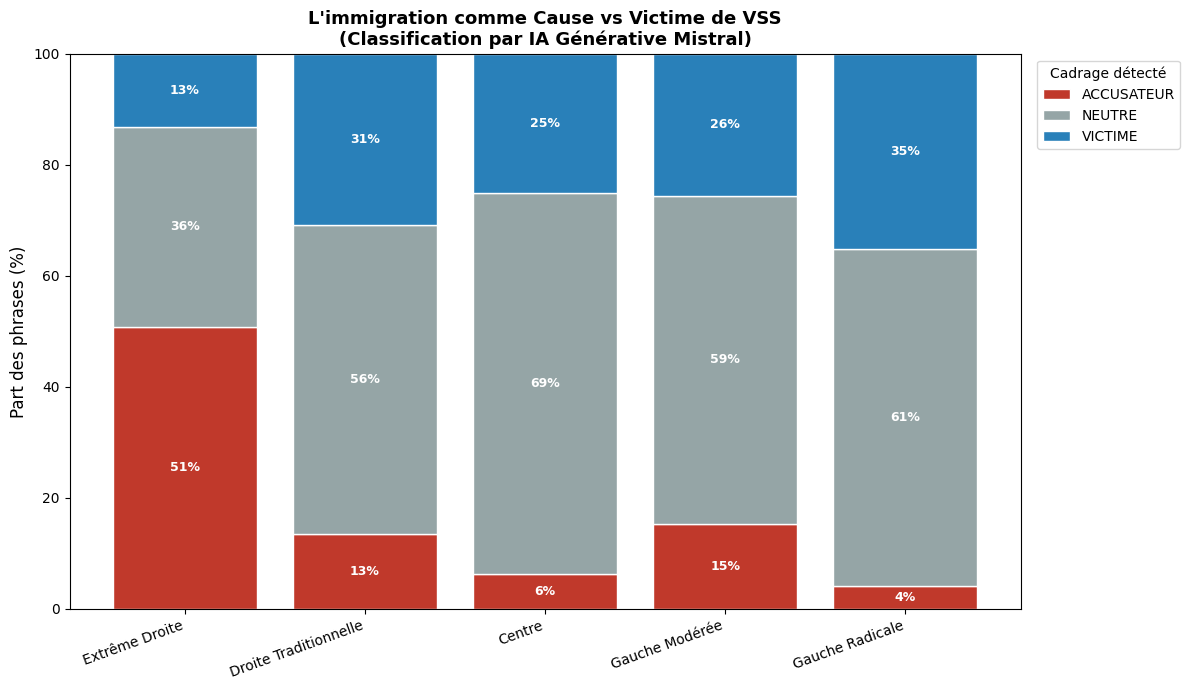


🔎 DEBUG QUALITATIF : FOCUS SUR LA GAUCHE MODÉRÉE

🔹 EXEMPLE 1 | Parti : Parti socialiste (2025-07-01 00:00:00)
   PHRASE : "Monsieur le président de la commission, il faut dire les choses : cette loi vise spécifiquement les étrangers en laissant entendre que le fait d’être étranger et en situation irrégulière conduit potentiellement à être un criminel, un meurtrier et peut-être un violeur"
   CLASSIFICATION : NEUTRE
   JUSTIFICATION  : L'orateur dénonce la loi en affirmant qu'elle stigmatise les étrangers en situation irrégulière en leur attribuant un lien potentiel avec le crime, y compris le meurtre et les violences sexuelles.
------------------------------------------------------------

🔹 EXEMPLE 2 | Parti : Parti socialiste (2025-07-01 00:00:00)
   PHRASE : "Mais les violeurs de Bétharram ou ceux de Gisèle Pelicot ne sont pas des étrangers et on ne vous entend pas beaucoup à leur sujet"
   CLASSIFICATION : NEUTRE
   JUSTIFICATION  : L'orateur ici est en train de dénoncer les propo

In [38]:
"""
============================================================================
ANALYSE DE CADRAGE VSS × IMMIGRATION – MISTRAL EN TANT QUE CLASSIFIEUR
============================================================================
Mistral analyse chaque phrase individuellement pour déterminer si 
l'immigration/islam est décrite comme la cause/responsable des VSS.
============================================================================
"""

import os
import re
import time
import requests
import urllib3
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from tqdm import tqdm

# Désactiver l'avertissement SSL lié au "verify=False"
urllib3.disable_warnings(urllib3.exceptions.InsecureRequestWarning)

# ============================================================================
# CONFIGURATION
# ============================================================================

URL_OLLAMA = "https://ollama-api.lab.groupe-genes.fr/api/chat"

ORDRE_BLOCS = ["Extrême Droite", "Droite Traditionnelle", "Centre", "Gauche Modérée", "Gauche Radicale"]
COULEURS_BLOCS = {
    "Extrême Droite":       "#8B0000",
    "Droite Traditionnelle":"#1E3A8A",
    "Centre":               "#D97706",
    "Gauche Modérée":       "#166534",
    "Gauche Radicale":      "#DC2626"
}

# ============================================================================
# CONFIGURATION DES LISTES (RACINES ET MOTS COMPOSÉS)
# ============================================================================

# --- Groupes cibles / Identitaire (Racines élargies) ---
GROUPES_CIBLES = [
    # Immigration brute
    "immigr", "clandestin", "étranger", "migrant", "réfugié", "exilé", "demandeur d'asile",
    # Mots composés et acronymes
    "sans-papier", "sans papier", "oqtf", "expulsion", "frontière", "reconduite", "éloignement",
    # Religion / Culture
    "islam", "musulman", "charia", "voile", "abaya", "burqa", "qamis",
    "confession", "séparatisme", "communautarisme", "assimilation", "intégration",
    # Origines / Civilisation
    "maghrébin", "africain", "arabe", "origine étrangère", "civilisation",
    # Lexique sécuritaire souvent lié à ces débats
    "ensauvagement", "décivilisation", "grand remplacement", "racaille", "délinquan"
]

# --- Mots VSS (Racines élargies) ---
MOTS_VSS_VIOLENCE = [
    # Actes directs (viol, viols, violeur, violence, violences...)
    "viol", "agress", "féminicide", "mutilation", "prostitu", "proxénét", "tournante",
    # Harcèlement (avec et sans accent grave pour capter harceleur et harcèlement)
    "harcel", "harcèl", "cyberharcèl", "cyber-harcèl",
    # Cadre relationnel / sexuel
    "sexuel", "sexis", "conjugal", "inceste", "pédocrimin", "pédophil",
    # Vocabulaire d'analyse systémique (pour capter la gauche notamment)
    "patriarca", "misogyn", "machis", "emprise", "soumission", "consentement",
    "stéréotype", "domination masculine", "culture du viol", "me too", "metoo"
]

# ============================================================================
# 1. EXTRACTION DES PHRASES (Le Filtre)
# ============================================================================

def extraire_phrases_cibles(df_vss):
    """
    Filtre le dataframe global pour ne garder QUE les phrases 
    qui contiennent à la fois une racine VSS et une racine du champ lexical identitaire.
    """
    # Le \w* permet de capter toutes les déclinaisons (pluriels, féminin, verbes conjugués)
    pattern_groupe = re.compile(r'(?i)\b(' + '|'.join([re.escape(m) for m in GROUPES_CIBLES]) + r')\w*\b')
    pattern_vss = re.compile(r'(?i)\b(' + '|'.join([re.escape(m) for m in MOTS_VSS_VIOLENCE]) + r')\w*\b')

    print("🔍 Extraction des phrases croisant VSS et Identitaire/Immigration...")
    resultats = []

    for _, row in tqdm(df_vss.iterrows(), total=len(df_vss), desc="Filtrage"):
        texte = str(row.get('texte', ''))
        bloc = row.get('bloc')
        
        if not texte or pd.isna(bloc): continue

        # On découpe le discours en phrases (via la ponctuation forte)
        phrases = re.split(r'[.!?;]+', texte)
        
        for phrase in phrases:
            phrase = phrase.strip()
            # On ignore les micro-phrases qui n'ont pas de sens
            if len(phrase.split()) < 6: continue

            # VRAI FILTRE : La phrase contient-elle les DEUX thématiques ?
            if pattern_vss.search(phrase) and pattern_groupe.search(phrase):
                resultats.append({
                    "phrase": phrase,
                    "bloc": bloc,
                    "nom_parti": row.get('nom_parti'),
                    "date": row.get('date')
                })

    df_phrases = pd.DataFrame(resultats)
    print(f"\n✅ {len(df_phrases)} phrases retenues au total avec les nouvelles listes élargies.")
    return df_phrases

# ============================================================================
# 2. APPEL API MISTRAL
# ============================================================================

def appeler_llm(prompt, role_systeme, max_retries=5):
    payload = {
        "model": "mistral",
        "messages": [
            {"role": "system", "content": role_systeme},
            {"role": "user", "content": prompt}
        ],
        "stream": False,
        "options": {
            "temperature": 0.0 # Strictement 0 pour éviter la créativité et forcer la classification
        }
    }

    for attempt in range(max_retries):
        try:
            r = requests.post(URL_OLLAMA, json=payload, timeout=180, verify=False)
            r.raise_for_status() 
            return r.json()["message"]["content"]
            
        except requests.exceptions.HTTPError as e:
            if e.response.status_code == 504:
                time.sleep(60)
            else:
                time.sleep(15)
        except requests.exceptions.RequestException:
            time.sleep(15)
        except ValueError:
            time.sleep(15)
            
    return ""

# ============================================================================
# 3. MISTRAL EN TANT QUE CLASSIFIEUR
# ============================================================================

def classifier_phrases_mistral(df_phrases):
    print(f"\n🤖 Lancement de la classification Mistral pour {len(df_phrases)} phrases...")
    
    # PROMPT SYSTEME BLINDÉ (Chain of Thought + Règles anti-biais)
    prompt_systeme = (
        "Tu es un chercheur en sociologie politique expert en analyse de discours. "
        "Ton rôle est d'analyser une phrase prononcée à l'Assemblée Nationale et de déterminer "
        "le cadrage politique utilisé par L'ORATEUR concernant le lien entre immigration/minorités et violences sexuelles/agressions (VSS).\n\n"
        
        "🚨 ATTENTION AUX PIÈGES FRÉQUENTS (À LIRE ATTENTIVEMENT) :\n"
        "- Dénonciation / Réfutation : Si l'orateur dénonce les propos de la droite/extrême droite, "
        "parle de 'récits mensongers', de 'stigmatisation', ou affirme que la nationalité n'a rien à voir avec le crime "
        "(ex: 'il est violeur avant d'être étranger'), L'ORATEUR N'ACCUSE PAS L'IMMIGRATION. La catégorie est NEUTRE. De même, si l'orateur dénonce et critique un texte ou une loi stigmatisant les étrangers, la catégorie est NEUTRE. \n"
        "- Voix passive : Si un étranger ou une minorité 'subit' ou 'est agressé(e)', il est la victime. La catégorie est VICTIME.\n"
        "- Lois et Administration : Les rappels sur les conditions d'éloignement, bracelets anti-rapprochement, etc., sont NEUTRES.\n\n"
        
        "CATÉGORIES POSSIBLES :\n"
        "1. ACCUSATEUR : L'orateur lui-même affirme ou sous-entend que l'immigration, les étrangers ou l'islam sont responsables, ou sont une menace causant des VSS.\n"
        "2. VICTIME : L'orateur décrit les immigrés, étrangers ou minorités (ex: femmes voilées) comme victimes d'agressions, de racisme ou nécessitant protection.\n"
        "3. NEUTRE : L'orateur dénonce le lien fait par ses adversaires (réfutation), sépare la nationalité du crime, énonce un fait administratif, ou les deux sujets sont sans lien causal dans sa phrase.\n\n"
        
        "FORMAT DE RÉPONSE OBLIGATOIRE (en 2 lignes exactes) :\n"
        "ANALYSE : [Explique brièvement qui est le sujet de l'action, et si l'orateur dénonce, constate ou accuse]\n"
        "CATEGORIE : [ACCUSATEUR ou VICTIME ou NEUTRE]"
    )

    resultats_classification = []

    for index, row in tqdm(df_phrases.iterrows(), total=len(df_phrases), desc="Classification Mistral"):
        phrase = row['phrase']
        # On ajoute le nom du parti dans le prompt utilisateur pour donner un micro-contexte au modèle
        prompt_user = f"Contexte : Orateur du parti '{row['nom_parti']}'.\nPhrase à analyser :\n\"{phrase}\"\n\nFournis ton ANALYSE puis ta CATEGORIE."
        
        reponse = appeler_llm(prompt_user, prompt_systeme)
        
        # -------------------------------------------------------------
        # PARSING DU NOUVEAU FORMAT
        # -------------------------------------------------------------
        cadrage = "INCONNU"
        justification = reponse
        score_net = 0
        
        # Extraction de la catégorie
        match_cat = re.search(r"CATEGORIE\s*:\s*(ACCUSATEUR|VICTIME|NEUTRE)", reponse, re.IGNORECASE)
        if match_cat:
            cadrage = match_cat.group(1).upper()
            if cadrage == "ACCUSATEUR": score_net = 1
            elif cadrage == "VICTIME": score_net = -1
            else: score_net = 0
            
        # Extraction de l'analyse (justification)
        match_ana = re.search(r"ANALYSE\s*:\s*(.*?)(?=\nCATEGORIE|$)", reponse, re.IGNORECASE | re.DOTALL)
        if match_ana:
            justification = match_ana.group(1).strip()
                
        resultats_classification.append({
            "cadrage_mistral": cadrage,
            "score_net": score_net,
            "justification": justification,
            "reponse_brute": reponse
        })
        
        time.sleep(1) # Pause API

    df_resultats = pd.concat([df_phrases.reset_index(drop=True), pd.DataFrame(resultats_classification)], axis=1)
    
    # Nettoyage des erreurs de format
    erreurs = len(df_resultats[df_resultats['cadrage_mistral'] == "INCONNU"])
    if erreurs > 0:
        print(f"\n⚠️ Mistral a échoué à formater {erreurs} phrases. Classées NEUTRE par défaut.")
        df_resultats['cadrage_mistral'] = df_resultats['cadrage_mistral'].replace("INCONNU", "NEUTRE")
        
    return df_resultats
# ============================================================================
# 4. VISUALISATIONS DES RÉSULTATS MISTRAL
# ============================================================================

def tracer_cadrage_par_bloc(df, output_dir=None):
    if output_dir: os.makedirs(output_dir, exist_ok=True)

    counts = (
        df.groupby(['bloc', 'cadrage_mistral'])
        .size()
        .unstack(fill_value=0)
        .reindex([b for b in ORDRE_BLOCS if b in df['bloc'].unique()])
    )
    pct = counts.div(counts.sum(axis=1), axis=0) * 100

    for col in ['ACCUSATEUR', 'NEUTRE', 'VICTIME']:
        if col not in pct.columns: pct[col] = 0

    couleurs = {'ACCUSATEUR': '#C0392B', 'NEUTRE': '#95A5A6', 'VICTIME': '#2980B9'}

    fig, ax = plt.subplots(figsize=(12, 7))
    bottom = np.zeros(len(pct))

    for cadrage in ['ACCUSATEUR', 'NEUTRE', 'VICTIME']:
        vals = pct[cadrage].values
        bars = ax.bar(pct.index, vals, bottom=bottom, color=couleurs[cadrage], label=cadrage, edgecolor='white')
        for i, (v, b) in enumerate(zip(vals, bottom)):
            if v > 4: ax.text(i, b + v / 2, f"{v:.0f}%", ha='center', va='center', fontsize=9, color='white', fontweight='bold')
        bottom += vals

    ax.set_ylim(0, 100)
    ax.set_ylabel("Part des phrases (%)", fontsize=12)
    ax.set_title("L'immigration comme Cause vs Victime de VSS\n(Classification par IA Générative Mistral)", fontsize=13, fontweight='bold')
    ax.legend(title="Cadrage détecté", bbox_to_anchor=(1.01, 1), loc='upper left')
    plt.xticks(rotation=20, ha='right')
    plt.tight_layout()

    if output_dir: plt.savefig(os.path.join(output_dir, "cadrage_mistral_barres.png"), dpi=150)
    plt.show()

# ============================================================================
# LANCEMENT PRINCIPAL
# ============================================================================

if __name__ == "__main__":
    chemin = "/home/onyxia/work/projet_eco_socio/df_vss_propre.pkl"
    output_dir = "/home/onyxia/work/projet_eco_socio/analyses_mistral_classifieur/"
    
    print("Chargement des données...")
    df_vss = pd.read_pickle(chemin)
    
    # 1. On filtre les phrases
    df_phrases = extraire_phrases_cibles(df_vss)
    
    if not df_phrases.empty:
        # 2. On lance la classification Mistral phrase par phrase
        df_analysee = classifier_phrases_mistral(df_phrases)
        
        # 3. On sauvegarde les résultats
        os.makedirs(output_dir, exist_ok=True)
        fichier_csv = os.path.join(output_dir, "phrases_classifiees_mistral.csv")
        df_analysee.to_csv(fichier_csv, index=False, encoding='utf-8-sig')
        print(f"\n💾 Données sauvegardées avec les justifications de Mistral dans : {fichier_csv}")
        
        # 4. On génère le graphique global
        print("\n📊 Génération du graphique final...")
        tracer_cadrage_par_bloc(df_analysee, output_dir=output_dir)
        
        # ====================================================================
        # NOUVEAU : DEBUG QUALITATIF POUR LA GAUCHE MODÉRÉE
        # ====================================================================
        print("\n" + "="*80)
        print("🔎 DEBUG QUALITATIF : FOCUS SUR LA GAUCHE MODÉRÉE")
        print("="*80)
        
        # On isole la Gauche Modérée
        df_gm = df_analysee[df_analysee['bloc'] == 'Gauche Modérée']
        
        if not df_gm.empty:
            # On prend 15 exemples au hasard (ou tous s'il y en a moins de 15)
            nb_exemples = min(30, len(df_gm))
            echantillon_gm = df_gm.sample(n=nb_exemples, random_state=42)
            
            for i, row in enumerate(echantillon_gm.iterrows(), 1):
                _, row_data = row
                print(f"\n🔹 EXEMPLE {i} | Parti : {row_data['nom_parti']} ({row_data['date']})")
                print(f"   PHRASE : \"{row_data['phrase']}\"")
                print(f"   CLASSIFICATION : {row_data['cadrage_mistral']}")
                print(f"   JUSTIFICATION  : {row_data['justification']}")
                print("-" * 60)
        else:
            print("Aucune phrase de la Gauche Modérée n'a été trouvée pour le debug.")

    else:
        print("⚠️ Aucune phrase trouvée.")

On va tester avec l'API gratuite de Gemini pour analyser une éventuelle différence. Résultat : quotas atteints très vite, on va utiliser un autre llm avec API ENSAE

In [39]:
pip install -U google-generativeai

INFO: pip is looking at multiple versions of grpcio-status to determine which version is compatible with other requirements. This could take a while.
INFO: pip is still looking at multiple versions of grpcio-status to determine which version is compatible with other requirements. This could take a while.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 77.2 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.7/6.7 MB 93.0 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 14.8/14.8 MB 100.9 MB/s  0:00:00
  Attempting uninstall: protobuf
    Found existing installation: protobuf 6.33.5
    Uninstalling protobuf-6.33.5:
      Successfully uninstalled protobuf-6.33.5
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12/12 [google-generativeai]ogle-generativeai]language]
Note: you may need to restart the kernel to use updated packages.


In [40]:
import requests
import urllib3
urllib3.disable_warnings(urllib3.exceptions.InsecureRequestWarning)

url_tags = "https://ollama-api.lab.groupe-genes.fr/api/tags"

try:
    r = requests.get(url_tags, verify=False, timeout=10)
    modeles = r.json().get('models', [])
    print("MODÈLES DISPONIBLES SUR LE SERVEUR DE L'ENSAE :\n")
    for m in modeles:
        print(f"- {m['name']}")
except Exception as e:
    print(f"Erreur de connexion : {e}")

MODÈLES DISPONIBLES SUR LE SERVEUR DE L'ENSAE :

- llama3.3:latest
- gpt-oss:20b
- mistral:latest
- qwen2.5:3b-instruct
- phi3:mini
- gemma2:2b
- llama3.2:3b
- qwen2.5:3b


Chargement des données...
🔍 Extraction des phrases croisant VSS et Identitaire/Immigration...


Filtrage: 100%|██████████| 10380/10380 [00:03<00:00, 2840.44it/s]



✅ 287 phrases retenues.

🤖 Lancement de la classification llama3.3...
🚀 Il reste 287 phrases à classifier.


Classification: 100%|██████████| 287/287 [2:09:06<00:00, 26.99s/it]  



💾 Données finales dans : /home/onyxia/work/projet_eco_socio/analyses_mistral_classifieur/phrases_classifiees.csv


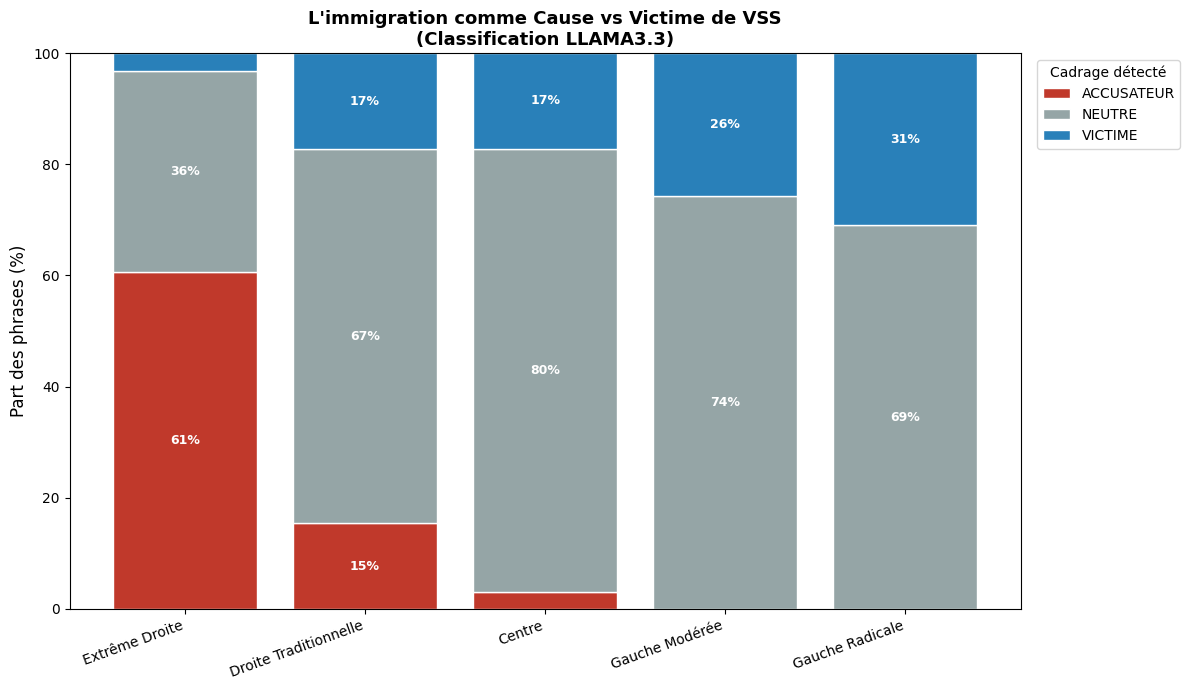

In [41]:
import os
import re
import time
import requests
import urllib3
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm

urllib3.disable_warnings(urllib3.exceptions.InsecureRequestWarning)

URL_OLLAMA = "https://ollama-api.lab.groupe-genes.fr/api/chat"
MODELE_CHOISI = "llama3.3" 

ORDRE_BLOCS = ["Extrême Droite", "Droite Traditionnelle", "Centre", "Gauche Modérée", "Gauche Radicale"]
GROUPES_CIBLES = [
    "immigr", "clandestin", "étranger", "migrant", "réfugié", "exilé", "demandeur d'asile",
    "sans-papier", "sans papier", "oqtf", "expulsion", "frontière", "reconduite", "éloignement",
    "islam", "musulman", "charia", "voile", "abaya", "burqa", "qamis",
    "confession", "séparatisme", "communautarisme", "assimilation", "intégration",
    "maghrébin", "africain", "arabe", "origine étrangère", "civilisation",
    "ensauvagement", "décivilisation", "grand remplacement", "racaille", "délinquan"
]
MOTS_VSS_VIOLENCE = [
    "viol", "agress", "féminicide", "mutilation", "prostitu", "proxénét", "tournante",
    "harcel", "harcèl", "cyberharcèl", "cyber-harcèl",
    "sexuel", "sexis", "conjugal", "inceste", "pédocrimin", "pédophil",
    "patriarca", "misogyn", "machis", "emprise", "soumission", "consentement",
    "stéréotype", "domination masculine", "culture du viol", "me too", "metoo"
]

def extraire_phrases_cibles(df_vss):
    pattern_groupe = re.compile(r'(?i)\b(' + '|'.join([re.escape(m) for m in GROUPES_CIBLES]) + r')\w*\b')
    pattern_vss = re.compile(r'(?i)\b(' + '|'.join([re.escape(m) for m in MOTS_VSS_VIOLENCE]) + r')\w*\b')
    print("🔍 Extraction des phrases croisant VSS et Identitaire/Immigration...")
    resultats = []
    for _, row in tqdm(df_vss.iterrows(), total=len(df_vss), desc="Filtrage"):
        texte, bloc = str(row.get('texte', '')), row.get('bloc')
        if not texte or pd.isna(bloc): continue
        phrases = re.split(r'[.!?;]+', texte)
        for phrase in phrases:
            phrase = phrase.strip()
            if len(phrase.split()) < 6: continue
            if pattern_vss.search(phrase) and pattern_groupe.search(phrase):
                resultats.append({
                    "phrase": phrase, "bloc": bloc,
                    "nom_parti": row.get('nom_parti'), "date": row.get('date')
                })
    df_phrases = pd.DataFrame(resultats)
    print(f"\n✅ {len(df_phrases)} phrases retenues.")
    return df_phrases

def appeler_llm(prompt, role_systeme, max_retries=6):
    payload = {
        "model": MODELE_CHOISI,
        "messages": [
            {"role": "system", "content": role_systeme},
            {"role": "user", "content": prompt}
        ],
        "stream": False,
        "options": {"temperature": 0.0}
    }
    for attempt in range(max_retries):
        try:
            r = requests.post(URL_OLLAMA, json=payload, timeout=90, verify=False)
            r.raise_for_status() 
            return r.json()["message"]["content"]
        except requests.exceptions.HTTPError as e:
            if e.response.status_code == 504:
                time.sleep(30) # Le serveur sature, on patiente
            elif e.response.status_code == 404:
                print(f"\n❌ ERREUR 404 : Le modèle '{MODELE_CHOISI}' n'existe pas sur le serveur ENSAE.")
                return ""
            else:
                time.sleep(10)
        except requests.exceptions.RequestException:
            # En cas de coupure VPN, on attend plus longtemps (30s) pour te laisser le temps de le relancer
            print("\n⚠️ Perte de connexion (VPN tombé ?). Nouvelle tentative dans 30s...")
            time.sleep(30)
    return ""

def classifier_phrases_mistral(df_phrases, fichier_csv):
    print(f"\n🤖 Lancement de la classification {MODELE_CHOISI}...")
    
    # GESTION DE LA SAUVEGARDE ET REPRISE
    phrases_deja_faites = []
    if os.path.exists(fichier_csv):
        df_existant = pd.read_csv(fichier_csv)
        phrases_deja_faites = df_existant['phrase'].tolist()
        print(f"🔄 Reprise : {len(phrases_deja_faites)} phrases déjà trouvées dans le CSV.")
    else:
        colonnes = list(df_phrases.columns) + ['cadrage_mistral', 'score_net', 'justification', 'reponse_brute']
        pd.DataFrame(columns=colonnes).to_csv(fichier_csv, index=False, encoding='utf-8-sig')

    prompt_systeme = (
        "Tu es un chercheur en sociologie politique expert en analyse de discours. "
        "Ton rôle est d'analyser une phrase prononcée à l'Assemblée Nationale et de déterminer "
        "le cadrage politique utilisé par L'ORATEUR concernant le lien entre immigration/minorités et violences sexuelles/agressions (VSS).\n\n"
        "🚨 ATTENTION AUX PIÈGES FRÉQUENTS (À LIRE ATTENTIVEMENT) :\n"
        "- Dénonciation / Réfutation : Si l'orateur dénonce les propos de la droite/extrême droite, "
        "parle de 'récits mensongers', de 'stigmatisation'... L'ORATEUR N'ACCUSE PAS L'IMMIGRATION. La catégorie est NEUTRE. De même, si l'orateur dénonce et critique un texte ou une loi stigmatisant les étrangers, la catégorie est NEUTRE. \n"
        "- Voix passive : Si un étranger ou une minorité 'subit' ou 'est agressé(e)', il est la victime. La catégorie est VICTIME.\n"
        "- Lois et Administration : Les rappels sur les conditions d'éloignement, bracelets anti-rapprochement, etc., sont NEUTRES.\n\n"
        "CATÉGORIES POSSIBLES :\n"
        "1. ACCUSATEUR : L'orateur affirme/sous-entend que l'immigration ou l'islam sont responsables des VSS.\n"
        "2. VICTIME : L'orateur décrit les immigrés/minorités comme victimes d'agressions.\n"
        "3. NEUTRE : Réfutation, fait administratif, ou sans lien causal.\n\n"
        "FORMAT DE RÉPONSE OBLIGATOIRE (en 2 lignes exactes) :\n"
        "ANALYSE : [Explique brièvement]\n"
        "CATEGORIE : [ACCUSATEUR ou VICTIME ou NEUTRE]"
    )

    df_a_traiter = df_phrases[~df_phrases['phrase'].isin(phrases_deja_faites)]
    print(f"🚀 Il reste {len(df_a_traiter)} phrases à classifier.")

    for index, row in tqdm(df_a_traiter.iterrows(), total=len(df_a_traiter), desc="Classification"):
        phrase = row['phrase']
        prompt_user = f"Contexte : Orateur du parti '{row['nom_parti']}'.\nPhrase à analyser :\n\"{phrase}\"\n\nFournis ton ANALYSE puis ta CATEGORIE."
        reponse = appeler_llm(prompt_user, prompt_systeme)
        
        # Si la réponse est vide (erreur 404 ou gros crash), on arrête la boucle proprement
        if not reponse:
            print("\n❌ Arrêt de la classification suite à une erreur critique.")
            break
            
        cadrage, score_net, justification = "NEUTRE", 0, reponse
        match_cat = re.search(r"CATEGORIE\s*:\s*(ACCUSATEUR|VICTIME|NEUTRE)", reponse, re.IGNORECASE)
        if match_cat:
            cadrage = match_cat.group(1).upper()
            if cadrage == "ACCUSATEUR": score_net = 1
            elif cadrage == "VICTIME": score_net = -1
            
        match_ana = re.search(r"ANALYSE\s*:\s*(.*?)(?=\nCATEGORIE|$)", reponse, re.IGNORECASE | re.DOTALL)
        if match_ana: justification = match_ana.group(1).strip()
                
        nouvelle_ligne = row.to_dict()
        nouvelle_ligne.update({
            "cadrage_mistral": cadrage, "score_net": score_net,
            "justification": justification, "reponse_brute": reponse
        })
        
        # Sauvegarde immédiate
        pd.DataFrame([nouvelle_ligne]).to_csv(fichier_csv, mode='a', header=False, index=False, encoding='utf-8-sig')
        time.sleep(0.5)

    return pd.read_csv(fichier_csv)

def tracer_cadrage_par_bloc(df, output_dir=None):
    if output_dir: os.makedirs(output_dir, exist_ok=True)
    counts = df.groupby(['bloc', 'cadrage_mistral']).size().unstack(fill_value=0).reindex([b for b in ORDRE_BLOCS if b in df['bloc'].unique()])
    pct = counts.div(counts.sum(axis=1), axis=0) * 100
    for col in ['ACCUSATEUR', 'NEUTRE', 'VICTIME']:
        if col not in pct.columns: pct[col] = 0

    couleurs = {'ACCUSATEUR': '#C0392B', 'NEUTRE': '#95A5A6', 'VICTIME': '#2980B9'}
    fig, ax = plt.subplots(figsize=(12, 7))
    bottom = np.zeros(len(pct))

    for cadrage in ['ACCUSATEUR', 'NEUTRE', 'VICTIME']:
        vals = pct[cadrage].values
        bars = ax.bar(pct.index, vals, bottom=bottom, color=couleurs[cadrage], label=cadrage, edgecolor='white')
        for i, (v, b) in enumerate(zip(vals, bottom)):
            if v > 4: ax.text(i, b + v / 2, f"{v:.0f}%", ha='center', va='center', fontsize=9, color='white', fontweight='bold')
        bottom += vals

    ax.set_ylim(0, 100)
    ax.set_ylabel("Part des phrases (%)", fontsize=12)
    ax.set_title(f"L'immigration comme Cause vs Victime de VSS\n(Classification {MODELE_CHOISI.upper()})", fontsize=13, fontweight='bold')
    ax.legend(title="Cadrage détecté", bbox_to_anchor=(1.01, 1), loc='upper left')
    plt.xticks(rotation=20, ha='right')
    plt.tight_layout()
    if output_dir: plt.savefig(os.path.join(output_dir, "cadrage_barres.png"), dpi=150)
    plt.show()

if __name__ == "__main__":
    chemin = "/home/onyxia/work/projet_eco_socio/df_vss_propre.pkl"
    output_dir = "/home/onyxia/work/projet_eco_socio/analyses_mistral_classifieur/"
    os.makedirs(output_dir, exist_ok=True)
    fichier_csv = os.path.join(output_dir, "phrases_classifiees.csv")
    
    print("Chargement des données...")
    df_vss = pd.read_pickle(chemin)
    df_phrases = extraire_phrases_cibles(df_vss)
    
    if not df_phrases.empty:
        df_analysee = classifier_phrases_mistral(df_phrases, fichier_csv)
        print(f"\n💾 Données finales dans : {fichier_csv}")
        tracer_cadrage_par_bloc(df_analysee, output_dir=output_dir)

Chargement des données...
10380 prises de parole chargées.
ANALYSE CADRAGE VSS x IMMIGRATION  —  LLAMA3.3
Extraction des contextes VSS x immigration (fenêtre élargie)...


Filtrage: 100%|██████████| 10380/10380 [00:06<00:00, 1660.68it/s]


-> 707 contextes extraits  {'fenetre': 426, 'directe': 281}
bloc
Centre                   195
Gauche Radicale          178
Droite Traditionnelle    126
Extrême Droite           120
Gauche Modérée            88

Lancement de la classification llama3.3...
  707 contextes restants à classifier.


Classification LLM:  50%|█████     | 357/707 [2:33:35<3:35:44, 36.99s/it]


  [504] Serveur saturé, attente 30s... (tentative 1/6)


...


  [504] Serveur saturé, attente 30s... (tentative 1/6)

  [504] Serveur saturé, attente 30s... (tentative 2/6)


Classification LLM:  90%|████████▉ | 633/707 [5:34:28<1:17:01, 62.45s/it]


  [504] Serveur saturé, attente 30s... (tentative 1/6)


Classification LLM: 100%|██████████| 707/707 [6:21:22<00:00, 32.37s/it]  



  Classification terminée : 707 contextes au total.

Distribution des cadrages :
cadrage_llm
NEUTRE        551
ACCUSATEUR     79
VICTIME        77

Génération des graphiques...


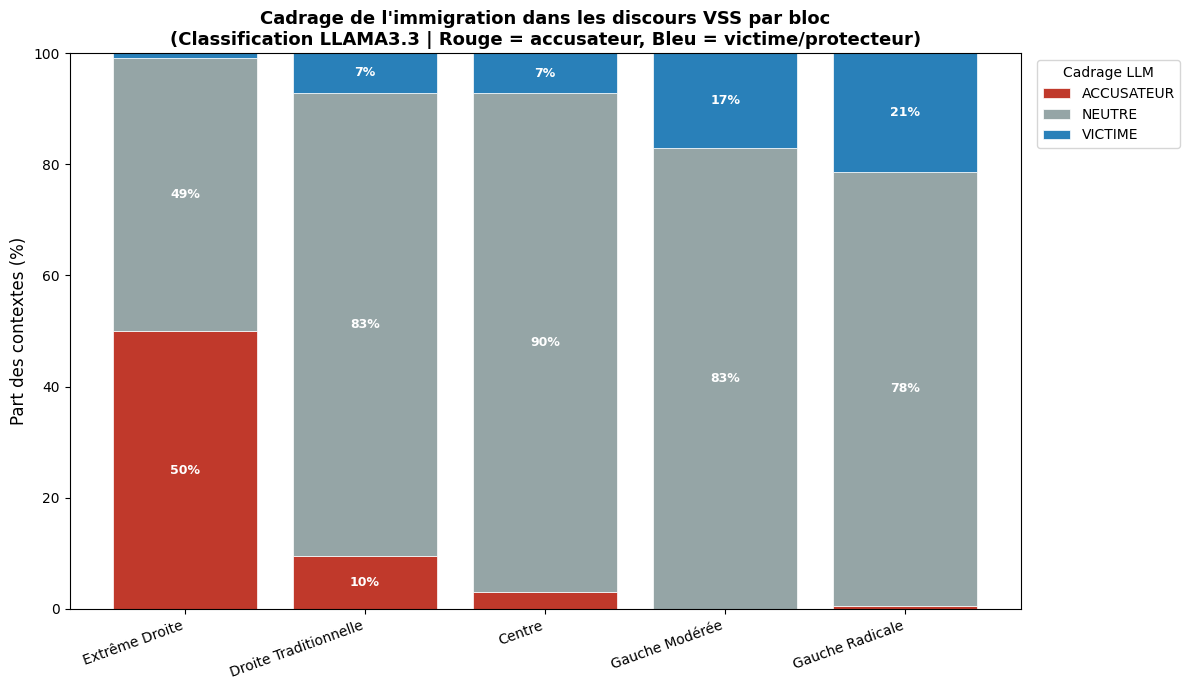

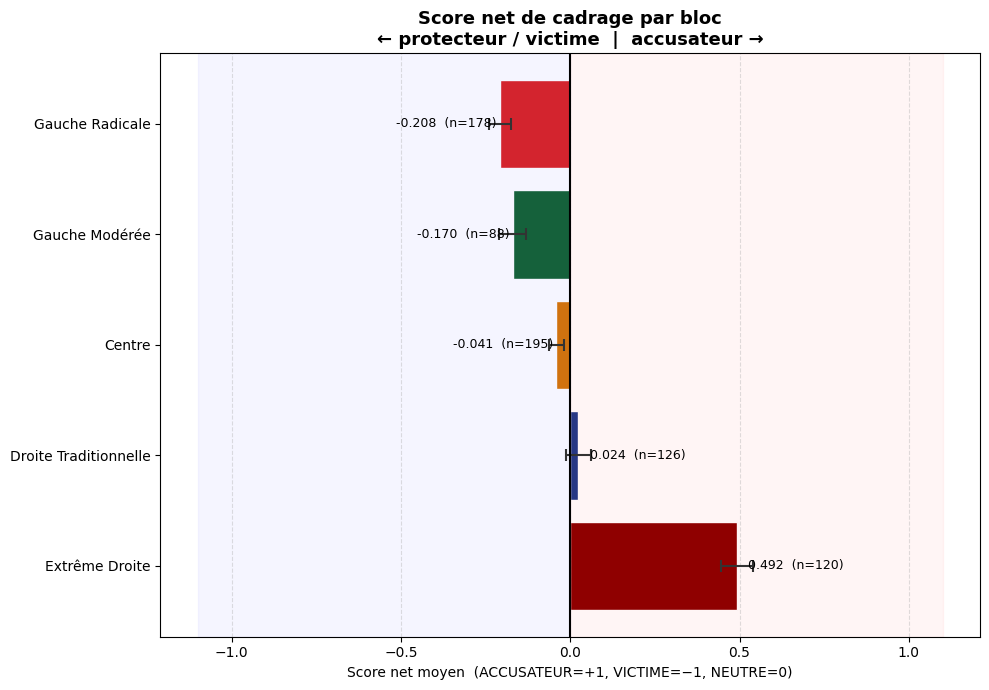

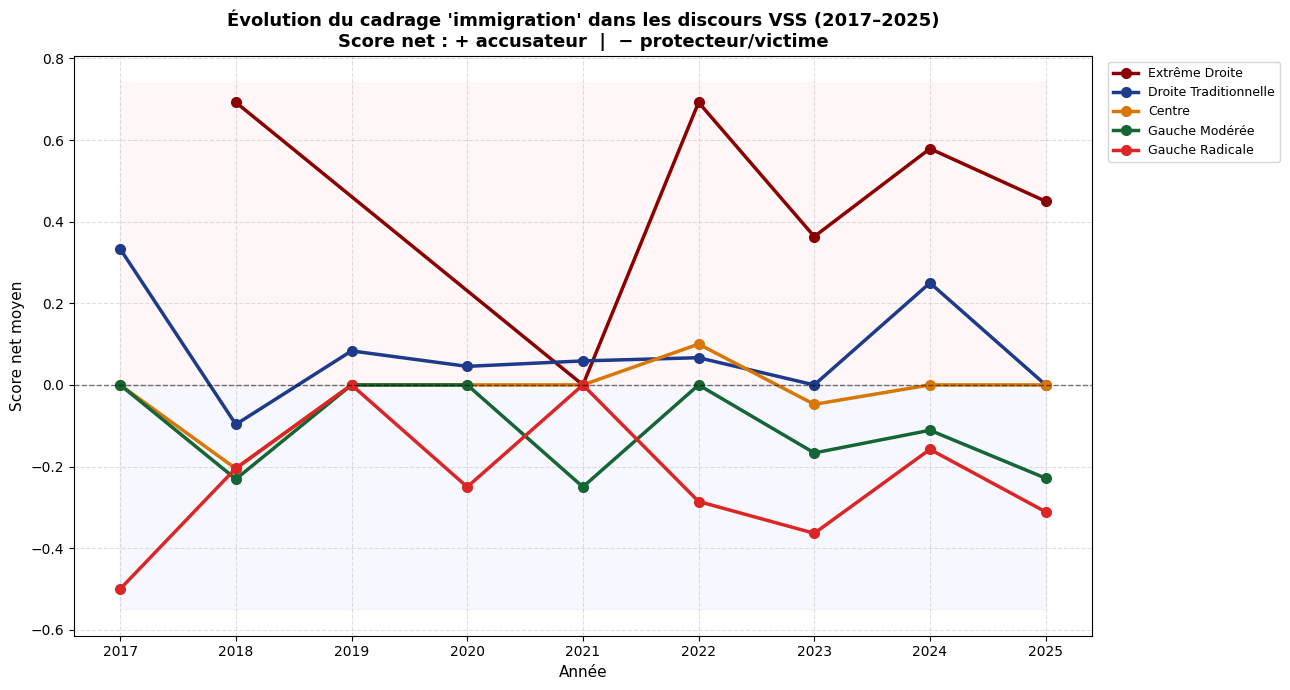

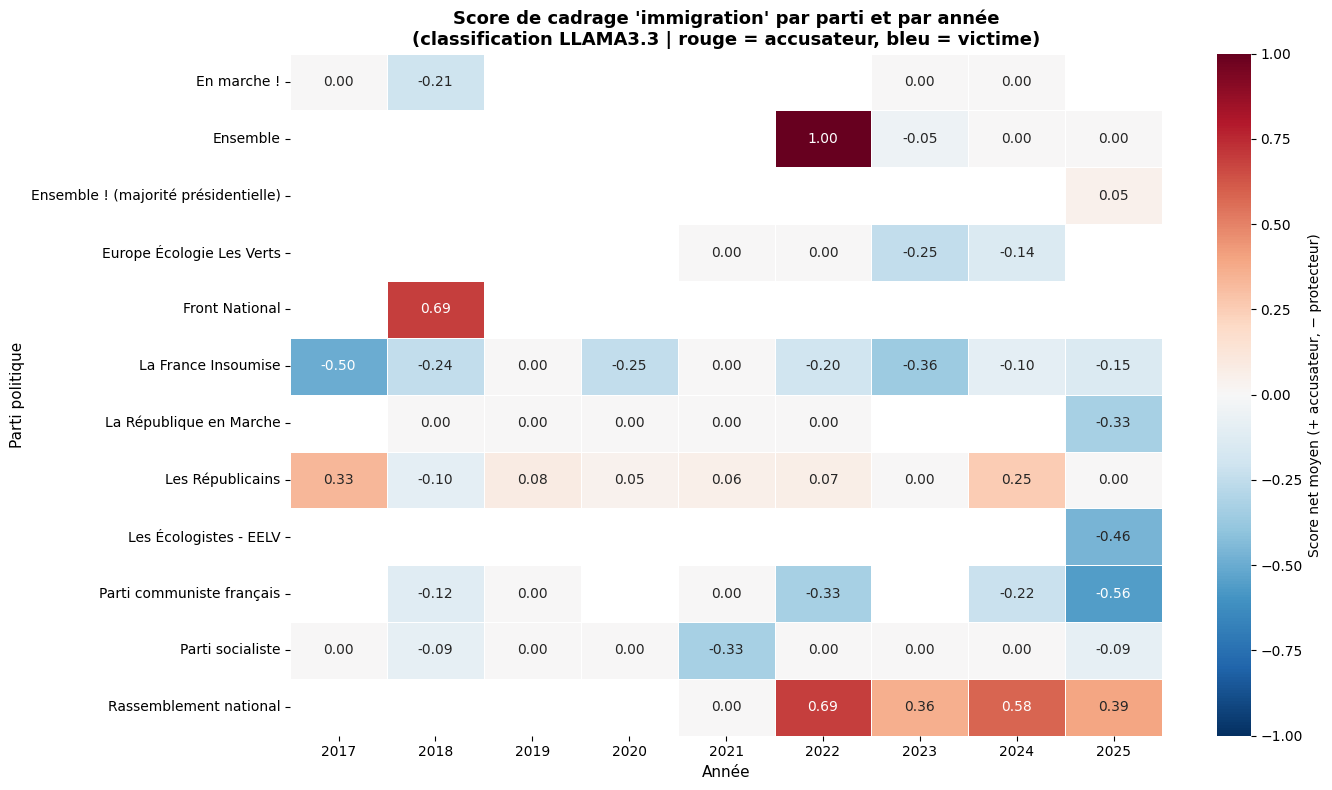

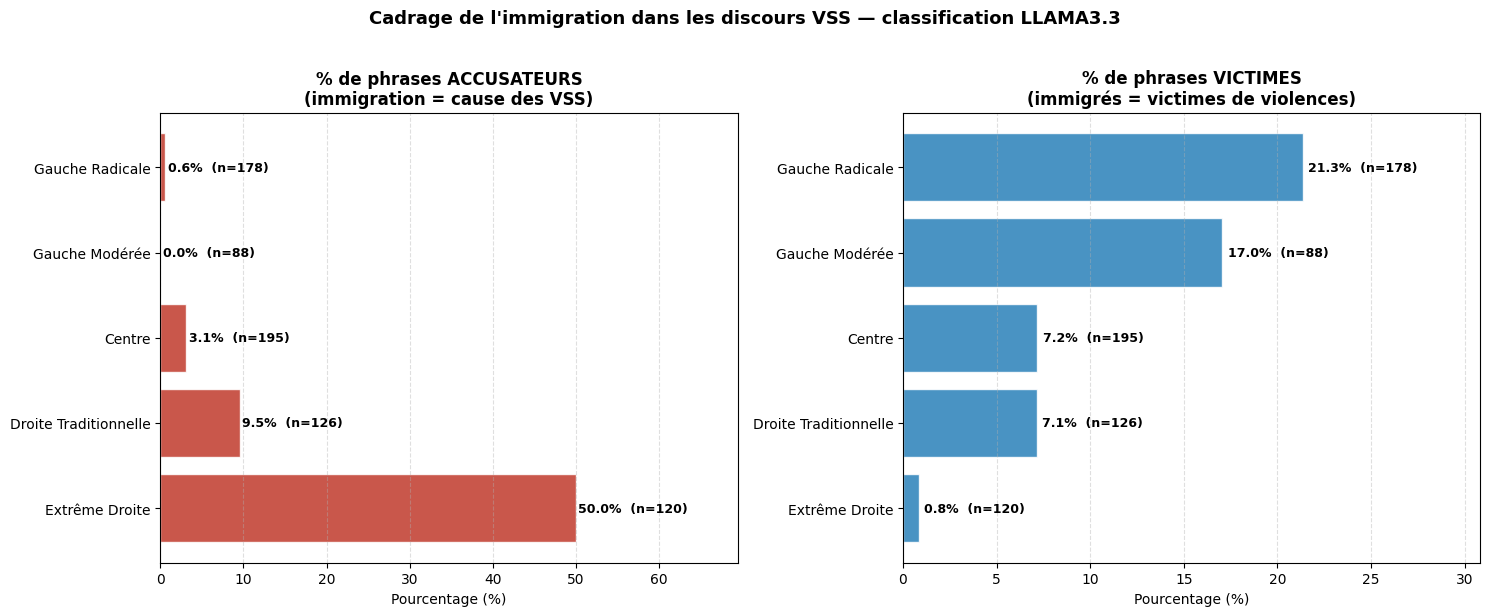


VALIDATION QUALITATIVE — exemples par bloc

─────────────────────────────────────────────────────────────────
  EXTRÊME DROITE  —  120 contextes
  Score net moyen : 0.492
  Cadrages : {'ACCUSATEUR': 60, 'NEUTRE': 59, 'VICTIME': 1}

  [ACCUSATEUR]
    [Front National] "Le récent viol d’une personne âgée par un mineur de seize ans est une abomination qui doit entraîner l’expulsion du mineur étranger dès qu’il aura été jugé"
    => LLM : L'orateur relie directement la nationalité du mineur à la nécessité de son expulsion après jugement, suggérant une causa
    [Front National] "Par cet amendement, nous proposons d’expulser systématiquement tout étranger coupable d’une agression sexuelle"
    => LLM : L'orateur propose une mesure spécifique visant les étrangers coupables d'agressions sexuelles, suggérant un lien entre l

  [VICTIME]
    [Rassemblement national] "…à tous les étudiants juifs de France qui sont agressés, insultés et subissent des discriminations pour la seule raison qu’ils s

In [42]:
"""
============================================================================
ANALYSE DE CADRAGE VSS x IMMIGRATION — LLM (Llama via Ollama ENSAE)
============================================================================
Combine :
  - Extraction large avec fenêtre inter-phrases (v3)
  - Classification LLM avec reprise CSV (ton code Ollama)
  - Toutes les visualisations : barres empilées, score net, évolution, heatmap
============================================================================
"""

import os, re, time, requests, urllib3
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from tqdm import tqdm

urllib3.disable_warnings(urllib3.exceptions.InsecureRequestWarning)

# ============================================================================
# CONFIG
# ============================================================================

URL_OLLAMA    = "https://ollama-api.lab.groupe-genes.fr/api/chat"
MODELE_CHOISI = "llama3.3"

ORDRE_BLOCS = ["Extrême Droite", "Droite Traditionnelle", "Centre", "Gauche Modérée", "Gauche Radicale"]

COULEURS_BLOCS = {
    "Extrême Droite":        "#8B0000",
    "Droite Traditionnelle": "#1E3A8A",
    "Centre":                "#D97706",
    "Gauche Modérée":        "#166534",
    "Gauche Radicale":       "#DC2626",
}

# Groupes cibles — large pour maximiser la couverture
GROUPES_CIBLES = [
    "immigr", "clandestin", "étranger", "migrant", "réfugié", "exilé",
    "demandeur d'asile", "sans-papier", "sans papier", "oqtf",
    "expulsion", "frontière", "reconduite", "éloignement",
    "islam", "musulman", "charia", "voile", "abaya", "burqa",
    "confession", "séparatisme", "communautarisme", "assimilation", "intégration",
    "maghrébin", "africain", "arabe", "origine étrangère", "civilisation",
    "ensauvagement", "grand remplacement", "délinquan",
]

MOTS_VSS = [
    "viol", "agress", "féminicide", "mutilation", "prostitu", "proxénét", "tournante",
    "harcel", "harcèl", "sexuel", "sexis", "conjugal", "inceste",
    "pédocrimin", "pédophil", "patriarca", "misogyn", "machis",
    "emprise", "soumission", "consentement", "domination masculine",
    "culture du viol", "me too", "metoo",
]

# ============================================================================
# PARTIE 1 : EXTRACTION LARGE (fenêtre inter-phrases, héritée de la v3)
# ============================================================================

def extraire_contextes(df_vss, fenetre_phrases=2):
    """
    Extrait les contextes où VSS et groupe cible se croisent.
    - Mode direct  : les deux dans la même phrase
    - Mode fenêtre : groupe cible dans les N phrases voisines d'une phrase VSS
    """
    pat_groupe = re.compile(r"(?i)\b(" + "|".join([re.escape(m) for m in GROUPES_CIBLES]) + r")\w*\b")
    pat_vss    = re.compile(r"(?i)\b(" + "|".join([re.escape(m) for m in MOTS_VSS])        + r")\w*\b")

    print("Extraction des contextes VSS x immigration (fenêtre élargie)...")
    resultats = []

    for _, row in tqdm(df_vss.iterrows(), total=len(df_vss), desc="Filtrage"):
        texte = str(row.get("texte", ""))
        bloc  = row.get("bloc")
        if not texte or pd.isna(bloc):
            continue

        phrases = [p.strip() for p in re.split(r"[.!?;]+", texte) if len(p.strip().split()) >= 5]
        n = len(phrases)

        for i, phrase in enumerate(phrases):
            a_vss    = bool(pat_vss.search(phrase))
            a_groupe = bool(pat_groupe.search(phrase))

            if a_vss and a_groupe:
                # Co-présence directe : on prend la phrase seule
                contexte = phrase
                mode = "directe"
            elif a_vss:
                # La phrase parle de VSS : on cherche un groupe cible dans les voisines
                debut = max(0, i - fenetre_phrases)
                fin   = min(n, i + fenetre_phrases + 1)
                voisines = phrases[debut:i] + phrases[i+1:fin]
                if any(pat_groupe.search(v) for v in voisines):
                    # On retourne le contexte élargi pour que le LLM ait plus d'info
                    contexte = " ".join(phrases[debut:fin])
                    mode = "fenetre"
                else:
                    continue
            else:
                continue

            resultats.append({
                "contexte":  contexte,
                "bloc":      bloc,
                "nom_parti": row.get("nom_parti"),
                "date":      row.get("date"),
                "mode":      mode,
            })

    df = pd.DataFrame(resultats).drop_duplicates(subset="contexte")
    print(f"-> {len(df)} contextes extraits  {df['mode'].value_counts().to_dict()}")
    print(df["bloc"].value_counts().to_string())
    return df


# ============================================================================
# PARTIE 2 : CLASSIFICATION LLM (Llama via Ollama ENSAE)
# ============================================================================

PROMPT_SYSTEME = (
    "Tu es un chercheur en sociologie politique expert en analyse de discours parlementaire français. "
    "Analyse le contexte fourni (extrait d'un débat à l'Assemblée Nationale) et détermine "
    "le cadrage utilisé par l'orateur concernant le lien entre immigration/minorités et violences sexistes/sexuelles (VSS).\n\n"

    "PIEGES FREQUENTS A EVITER ABSOLUMENT :\n"
    "- DENONCIATION : Si l'orateur critique/dénonce l'amalgame immigration-VSS, parle de "
    "  'stigmatisation', 'amalgame', 'récit mensonger', ou défend les immigrés contre des accusations : "
    "  => NEUTRE (l'orateur ne porte PAS l'accusation, il la réfute).\n"
    "- VOIX PASSIVE : Si un étranger ou une minorité 'subit', 'est aggressé(e)', 'est victime' "
    "  => VICTIME (pas ACCUSATEUR).\n"
    "- ADMINISTRATIF : Conditions d'éloignement, titres de séjour, droit d'asile, statistiques "
    "  neutres => NEUTRE.\n"
    "- CONTEXTE ANTI-RACISTE : Phrases dénonçant le racisme ou l'islamophobie => NEUTRE.\n\n"

    "TROIS CATEGORIES EXCLUSIVES :\n"
    "  ACCUSATEUR : L'orateur affirme ou sous-entend que l'immigration ou l'islam CAUSE ou EXPLIQUE les VSS.\n"
    "  VICTIME    : L'orateur présente les immigrés/minorités comme VICTIMES de violences ou discriminations.\n"
    "  NEUTRE     : Réfutation d'amalgame, fait administratif, analyse sans lien causal, contexte anti-raciste.\n\n"

    "REPONSE OBLIGATOIRE en exactement 2 lignes :\n"
    "ANALYSE : [justification courte]\n"
    "CATEGORIE : [ACCUSATEUR ou VICTIME ou NEUTRE]"
)


def appeler_llm(prompt_user, max_retries=6):
    payload = {
        "model":   MODELE_CHOISI,
        "messages": [
            {"role": "system",  "content": PROMPT_SYSTEME},
            {"role": "user",    "content": prompt_user},
        ],
        "stream":  False,
        "options": {"temperature": 0.0},
    }
    for attempt in range(max_retries):
        try:
            r = requests.post(URL_OLLAMA, json=payload, timeout=90, verify=False)
            r.raise_for_status()
            return r.json()["message"]["content"]
        except requests.exceptions.HTTPError as e:
            code = e.response.status_code
            if code == 504:
                print(f"\n  [504] Serveur saturé, attente 30s... (tentative {attempt+1}/{max_retries})")
                time.sleep(30)
            elif code == 404:
                print(f"\n  ERREUR 404 : modèle '{MODELE_CHOISI}' introuvable sur le serveur.")
                return ""
            else:
                time.sleep(10)
        except requests.exceptions.RequestException:
            print(f"\n  Perte de connexion (VPN ?). Attente 30s... (tentative {attempt+1}/{max_retries})")
            time.sleep(30)
    return ""


def parser_reponse(reponse):
    """Parse la réponse LLM et retourne (cadrage, score_net, justification)."""
    cadrage, score_net, justification = "NEUTRE", 0, reponse

    match_cat = re.search(r"CATEGORIE\s*:\s*(ACCUSATEUR|VICTIME|NEUTRE)", reponse, re.IGNORECASE)
    if match_cat:
        cadrage = match_cat.group(1).upper()
        if cadrage == "ACCUSATEUR": score_net =  1
        elif cadrage == "VICTIME":  score_net = -1

    match_ana = re.search(r"ANALYSE\s*:\s*(.*?)(?=\nCATEGORIE|$)", reponse, re.IGNORECASE | re.DOTALL)
    if match_ana:
        justification = match_ana.group(1).strip()

    return cadrage, score_net, justification


def classifier_avec_llm(df_contextes, fichier_csv):
    """
    Lance la classification LLM avec reprise automatique depuis le CSV.
    Sauvegarde phrase par phrase pour ne rien perdre.
    """
    print(f"\nLancement de la classification {MODELE_CHOISI}...")

    # --- Reprise depuis CSV existant ---
    if os.path.exists(fichier_csv):
        df_existant = pd.read_csv(fichier_csv)
        deja_faites = set(df_existant["contexte"].tolist())
        print(f"  Reprise : {len(deja_faites)} contextes déjà classifiés.")
    else:
        deja_faites = set()
        colonnes = list(df_contextes.columns) + ["cadrage_llm", "score_net", "justification", "reponse_brute"]
        pd.DataFrame(columns=colonnes).to_csv(fichier_csv, index=False, encoding="utf-8-sig")

    df_restant = df_contextes[~df_contextes["contexte"].isin(deja_faites)]
    print(f"  {len(df_restant)} contextes restants à classifier.")

    for _, row in tqdm(df_restant.iterrows(), total=len(df_restant), desc="Classification LLM"):
        contexte = row["contexte"]
        prompt_user = (
            f"Parti de l'orateur : '{row['nom_parti']}'\n"
            f"Contexte à analyser :\n\"{contexte}\"\n\n"
            "Fournis ton ANALYSE puis ta CATEGORIE."
        )

        reponse = appeler_llm(prompt_user)
        if not reponse:
            print("\n  Arrêt suite à une erreur critique.")
            break

        cadrage, score_net, justification = parser_reponse(reponse)

        nouvelle_ligne = row.to_dict()
        nouvelle_ligne.update({
            "cadrage_llm":    cadrage,
            "score_net":      score_net,
            "justification":  justification,
            "reponse_brute":  reponse,
        })
        pd.DataFrame([nouvelle_ligne]).to_csv(
            fichier_csv, mode="a", header=False, index=False, encoding="utf-8-sig"
        )
        time.sleep(0.3)

    df_final = pd.read_csv(fichier_csv)
    print(f"\n  Classification terminée : {len(df_final)} contextes au total.")
    return df_final


# ============================================================================
# PARTIE 3 : VISUALISATIONS
# ============================================================================

def tracer_barres_empilees(df, output_dir=None):
    """Barres 100% empilées : répartition des cadrages par bloc."""
    if output_dir: os.makedirs(output_dir, exist_ok=True)

    blocs_presents = [b for b in ORDRE_BLOCS if b in df["bloc"].unique()]
    counts = (
        df.groupby(["bloc", "cadrage_llm"]).size()
        .unstack(fill_value=0)
        .reindex(blocs_presents)
    )
    pct = counts.div(counts.sum(axis=1), axis=0) * 100
    for col in ["ACCUSATEUR", "NEUTRE", "VICTIME"]:
        if col not in pct.columns: pct[col] = 0.0

    coul = {"ACCUSATEUR": "#C0392B", "NEUTRE": "#95A5A6", "VICTIME": "#2980B9"}

    fig, ax = plt.subplots(figsize=(12, 7))
    bottom = np.zeros(len(pct))
    for cat in ["ACCUSATEUR", "NEUTRE", "VICTIME"]:
        vals = pct[cat].values
        ax.bar(pct.index, vals, bottom=bottom, color=coul[cat],
               label=cat, edgecolor="white", lw=0.5)
        for i, (v, b) in enumerate(zip(vals, bottom)):
            if v > 4:
                ax.text(i, b + v / 2, f"{v:.0f}%",
                        ha="center", va="center", fontsize=9,
                        color="white", fontweight="bold")
        bottom += vals

    ax.set_ylim(0, 100)
    ax.set_ylabel("Part des contextes (%)", fontsize=12)
    ax.set_title(
        f"Cadrage de l'immigration dans les discours VSS par bloc\n"
        f"(Classification {MODELE_CHOISI.upper()} | Rouge = accusateur, Bleu = victime/protecteur)",
        fontsize=13, fontweight="bold"
    )
    ax.legend(title="Cadrage LLM", bbox_to_anchor=(1.01, 1), loc="upper left")
    plt.xticks(rotation=20, ha="right")
    plt.tight_layout()

    if output_dir:
        plt.savefig(os.path.join(output_dir, "barres_cadrage_llm.png"), dpi=150, bbox_inches="tight")
    plt.show()


def tracer_score_net_par_bloc(df, output_dir=None):
    """Score net moyen (ACCUSATEUR=+1, VICTIME=-1) avec barres d'erreur."""
    if output_dir: os.makedirs(output_dir, exist_ok=True)

    stats = (
        df.groupby("bloc")["score_net"]
        .agg(["mean", "sem", "count"])
        .rename(columns={"mean": "m", "sem": "e", "count": "n"})
        .reset_index()
    )
    stats = stats[stats["bloc"].isin(ORDRE_BLOCS)]
    stats["bloc"] = pd.Categorical(stats["bloc"], categories=ORDRE_BLOCS, ordered=True)
    stats = stats.sort_values("bloc")
    coul = [COULEURS_BLOCS.get(b, "gray") for b in stats["bloc"]]

    fig, ax = plt.subplots(figsize=(10, 7))
    ax.barh(stats["bloc"], stats["m"], xerr=stats["e"],
            color=coul, edgecolor="white", capsize=4,
            error_kw={"elinewidth": 1.5, "ecolor": "#333", "capthick": 1.5})

    ax.axvline(0, color="black", lw=1.5)
    ax.axvspan(-1.1, 0, alpha=0.04, color="blue")
    ax.axvspan(0, 1.1,  alpha=0.04, color="red")

    for i, row in enumerate(stats.itertuples()):
        x = row.m
        ax.text(x + (0.01 if x >= 0 else -0.01), i,
                f"  {x:.3f}  (n={int(row.n)})",
                va="center", ha="left" if x >= 0 else "right", fontsize=9)

    ax.set_title(
        "Score net de cadrage par bloc\n"
        "← protecteur / victime  |  accusateur →",
        fontsize=13, fontweight="bold"
    )
    ax.set_xlabel("Score net moyen  (ACCUSATEUR=+1, VICTIME=−1, NEUTRE=0)", fontsize=10)
    ax.grid(axis="x", linestyle="--", alpha=0.4)
    plt.tight_layout()

    if output_dir:
        plt.savefig(os.path.join(output_dir, "score_net_llm.png"), dpi=150, bbox_inches="tight")
    plt.show()


def tracer_evolution_temporelle(df, output_dir=None):
    """Évolution annuelle du score net par bloc."""
    if output_dir: os.makedirs(output_dir, exist_ok=True)

    d = df.copy()
    d["date"]  = pd.to_datetime(d["date"], errors="coerce")
    d["annee"] = d["date"].dt.year
    d = d.dropna(subset=["annee"])

    evol = (
        d.groupby(["annee", "bloc"])["score_net"]
        .mean().reset_index()
        .rename(columns={"score_net": "score_moyen"})
    )
    evol = evol[evol["bloc"].isin(ORDRE_BLOCS)]

    fig, ax = plt.subplots(figsize=(13, 7))
    for bloc in ORDRE_BLOCS:
        sub = evol[evol["bloc"] == bloc].sort_values("annee")
        if sub.empty: continue
        ax.plot(sub["annee"], sub["score_moyen"],
                marker="o", label=bloc,
                color=COULEURS_BLOCS.get(bloc, "gray"),
                lw=2.5, markersize=7)

    ax.axhline(0, color="black", lw=1, ls="--", alpha=0.5)
    ax.fill_between(
        sorted(d["annee"].unique()),
        0, evol["score_moyen"].max() + 0.05 if not evol.empty else 0.1,
        alpha=0.03, color="red"
    )
    ax.fill_between(
        sorted(d["annee"].unique()),
        evol["score_moyen"].min() - 0.05 if not evol.empty else -0.1, 0,
        alpha=0.03, color="blue"
    )

    ax.set_title(
        "Évolution du cadrage 'immigration' dans les discours VSS (2017–2025)\n"
        "Score net : + accusateur  |  − protecteur/victime",
        fontsize=13, fontweight="bold"
    )
    ax.set_xlabel("Année", fontsize=11)
    ax.set_ylabel("Score net moyen", fontsize=11)
    ax.legend(bbox_to_anchor=(1.01, 1), loc="upper left", fontsize=9)
    ax.grid(ls="--", alpha=0.4)
    plt.tight_layout()

    if output_dir:
        plt.savefig(os.path.join(output_dir, "evolution_llm.png"), dpi=150, bbox_inches="tight")
    plt.show()


def tracer_heatmap_partis(df, output_dir=None, top_n_partis=12):
    """
    Heatmap : score net moyen par parti ET par année.
    Permet de voir quels partis spécifiques portent le discours accusateur.
    """
    if output_dir: os.makedirs(output_dir, exist_ok=True)

    d = df.copy()
    d["date"]  = pd.to_datetime(d["date"], errors="coerce")
    d["annee"] = d["date"].dt.year.astype("Int64")

    # On garde les partis les plus représentés
    top_partis = d["nom_parti"].value_counts().head(top_n_partis).index.tolist()
    d = d[d["nom_parti"].isin(top_partis)]

    pivot = (
        d.groupby(["nom_parti", "annee"])["score_net"]
        .mean().unstack(fill_value=np.nan)
    )

    fig, ax = plt.subplots(figsize=(14, 8))
    sns.heatmap(
        pivot,
        annot=True, fmt=".2f",
        cmap="RdBu_r",    # Rouge = accusateur, Bleu = protecteur
        center=0,
        vmin=-1, vmax=1,
        linewidths=0.4, linecolor="white",
        ax=ax,
        cbar_kws={"label": "Score net moyen (+ accusateur, − protecteur)"}
    )
    ax.set_title(
        f"Score de cadrage 'immigration' par parti et par année\n"
        f"(classification {MODELE_CHOISI.upper()} | rouge = accusateur, bleu = victime)",
        fontsize=13, fontweight="bold"
    )
    ax.set_xlabel("Année", fontsize=11)
    ax.set_ylabel("Parti politique", fontsize=11)
    plt.tight_layout()

    if output_dir:
        plt.savefig(os.path.join(output_dir, "heatmap_partis_llm.png"), dpi=150, bbox_inches="tight")
    plt.show()


def tracer_pct_accusateur_par_bloc(df, output_dir=None):
    """
    Graphique simple en barres horizontales :
    % de phrases classées ACCUSATEUR par bloc, avec le n total.
    Facile à lire pour un rendu académique.
    """
    if output_dir: os.makedirs(output_dir, exist_ok=True)

    stats = (
        df.groupby("bloc").agg(
            n=("cadrage_llm", "count"),
            pct_acc=("cadrage_llm", lambda x: (x == "ACCUSATEUR").mean() * 100),
            pct_vic=("cadrage_llm", lambda x: (x == "VICTIME").mean()    * 100),
        ).reset_index()
    )
    stats = stats[stats["bloc"].isin(ORDRE_BLOCS)]
    stats["bloc"] = pd.Categorical(stats["bloc"], categories=ORDRE_BLOCS, ordered=True)
    stats = stats.sort_values("bloc")

    fig, axes = plt.subplots(1, 2, figsize=(15, 6))

    for ax, col, titre, coul in [
        (axes[0], "pct_acc", "% de phrases ACCUSATEURS\n(immigration = cause des VSS)", "#C0392B"),
        (axes[1], "pct_vic", "% de phrases VICTIMES\n(immigrés = victimes de violences)", "#2980B9"),
    ]:
        bars = ax.barh(stats["bloc"], stats[col], color=coul, edgecolor="white", alpha=0.85)
        for bar, row in zip(bars, stats.itertuples()):
            ax.text(bar.get_width() + 0.3, bar.get_y() + bar.get_height() / 2,
                    f"{bar.get_width():.1f}%  (n={row.n})",
                    va="center", fontsize=9, fontweight="bold")
        ax.set_title(titre, fontsize=12, fontweight="bold")
        ax.set_xlabel("Pourcentage (%)", fontsize=10)
        ax.set_xlim(0, stats[col].max() * 1.35 + 2)
        ax.grid(axis="x", linestyle="--", alpha=0.4)

    plt.suptitle(
        f"Cadrage de l'immigration dans les discours VSS — classification {MODELE_CHOISI.upper()}",
        fontsize=13, fontweight="bold", y=1.02
    )
    plt.tight_layout()

    if output_dir:
        plt.savefig(os.path.join(output_dir, "pct_accusateur_victime.png"), dpi=150, bbox_inches="tight")
    plt.show()


def afficher_exemples(df, n=2):
    """Validation qualitative : exemples par bloc et par cadrage."""
    print("\n" + "=" * 80)
    print("VALIDATION QUALITATIVE — exemples par bloc")
    print("=" * 80)

    for bloc in ORDRE_BLOCS:
        sub = df[df["bloc"] == bloc]
        if sub.empty: continue

        print(f"\n{'─'*65}")
        print(f"  {bloc.upper()}  —  {len(sub)} contextes")
        print(f"  Score net moyen : {sub['score_net'].mean():.3f}")
        print(f"  Cadrages : {sub['cadrage_llm'].value_counts().to_dict()}")

        for cadrage in ["ACCUSATEUR", "VICTIME"]:
            sous = sub[sub["cadrage_llm"] == cadrage].head(n)
            if sous.empty: continue
            print(f"\n  [{cadrage}]")
            for _, row in sous.iterrows():
                txt = row["contexte"][:220] + "…" if len(row["contexte"]) > 220 else row["contexte"]
                just = str(row.get("justification", ""))[:120]
                print(f"    [{row['nom_parti']}] \"{txt}\"")
                print(f"    => LLM : {just}")


def synthese_par_bloc(df):
    """Affiche et retourne le tableau de synthèse."""
    print("\n📊 SYNTHÈSE PAR BLOC :")
    syn = (
        df.groupby("bloc").agg(
            n=("cadrage_llm", "count"),
            score_net_moyen=("score_net", "mean"),
            pct_accusateur=("cadrage_llm", lambda x: (x == "ACCUSATEUR").mean() * 100),
            pct_victime=   ("cadrage_llm", lambda x: (x == "VICTIME"   ).mean() * 100),
            pct_neutre=    ("cadrage_llm", lambda x: (x == "NEUTRE"    ).mean() * 100),
        ).round(2)
    )
    print(syn.to_string())
    return syn


# ============================================================================
# PIPELINE PRINCIPAL
# ============================================================================

def pipeline_llm(df_vss, output_dir, fichier_csv=None, fenetre=2):
    """
    Pipeline complet :
      1. Extraction large (fenêtre inter-phrases)
      2. Classification LLM avec reprise CSV
      3. 5 visualisations
      4. Validation qualitative + synthèse
    """
    print("=" * 80)
    print(f"ANALYSE CADRAGE VSS x IMMIGRATION  —  {MODELE_CHOISI.upper()}")
    print("=" * 80)

    os.makedirs(output_dir, exist_ok=True)
    if fichier_csv is None:
        fichier_csv = os.path.join(output_dir, "phrases_classifiees_llm.csv")

    if "bloc" not in df_vss.columns:
        raise ValueError("Colonne 'bloc' manquante dans df_vss.")
    df_vss = df_vss.dropna(subset=["bloc"]).copy()

    # 1. Extraction
    df_contextes = extraire_contextes(df_vss, fenetre_phrases=fenetre)
    if df_contextes.empty:
        print("Aucun contexte extrait.")
        return None

    # 2. Classification LLM
    df_final = classifier_avec_llm(df_contextes, fichier_csv)

    # Nettoyage : on s'assure que la colonne cadrage_llm est propre
    df_final["cadrage_llm"] = df_final["cadrage_llm"].str.upper().str.strip()
    df_final["cadrage_llm"] = df_final["cadrage_llm"].where(
        df_final["cadrage_llm"].isin(["ACCUSATEUR", "VICTIME", "NEUTRE"]), "NEUTRE"
    )
    df_final["score_net"] = df_final["cadrage_llm"].map(
        {"ACCUSATEUR": 1, "VICTIME": -1, "NEUTRE": 0}
    )

    print(f"\nDistribution des cadrages :\n{df_final['cadrage_llm'].value_counts().to_string()}")

    # 3. Visualisations
    print("\nGénération des graphiques...")
    tracer_barres_empilees(df_final, output_dir)
    tracer_score_net_par_bloc(df_final, output_dir)
    tracer_evolution_temporelle(df_final, output_dir)
    tracer_heatmap_partis(df_final, output_dir)
    tracer_pct_accusateur_par_bloc(df_final, output_dir)

    # 4. Validation + synthèse
    afficher_exemples(df_final)
    synthese_par_bloc(df_final)

    print(f"\n Sauvegardé dans : {output_dir}")
    print("Analyse terminée.")
    return df_final


# ============================================================================
# POINT D'ENTREE
# ============================================================================

if __name__ == "__main__":

    chemin     = "/home/onyxia/work/projet_eco_socio/df_vss_propre.pkl"
    output_dir = "/home/onyxia/work/projet_eco_socio/analyses_cadrage_llm/"
    fichier_csv = os.path.join(output_dir, "phrases_classifiees_llm.csv")

    print("Chargement des données...")
    df_vss = pd.read_pickle(chemin)
    print(f"{len(df_vss)} prises de parole chargées.")

    # Assurer la colonne bloc si absente
    if "bloc" not in df_vss.columns:
        def _bloc(nom):
            nom = str(nom).lower()
            if any(x in nom for x in ["rassemblement national", "front national", "udr"]): return "Extrême Droite"
            if "républicains" in nom: return "Droite Traditionnelle"
            if any(c in nom for c in ["en marche", "renaissance", "ensemble", "modem", "horizons"]): return "Centre"
            if any(g in nom for g in ["socialiste", "écologistes", "europe écologie", "radical"]): return "Gauche Modérée"
            if any(g in nom for g in ["france insoumise", "communiste", "lfi"]): return "Gauche Radicale"
            return None
        df_vss["bloc"] = df_vss["nom_parti"].apply(_bloc)

    df_final = pipeline_llm(
        df_vss,
        output_dir=output_dir,
        fichier_csv=fichier_csv,
        fenetre=2,         # fenêtre inter-phrases : augmenter si trop peu de contextes
    )

In [ ]:
"""
============================================================================
ANALYSE DE CADRAGE VSS x IMMIGRATION — LLM (Llama via Ollama ENSAE) - ONE SHOT
============================================================================
Combine :
  - Extraction large avec fenêtre inter-phrases (v3)
  - Classification LLM avec reprise CSV (ton code Ollama)
  - Toutes les visualisations : barres empilées, score net, évolution, heatmap
  - Ajoute un contexte mal classé au prompt du LLM 
============================================================================
"""

import os, re, time, requests, urllib3
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from tqdm import tqdm

urllib3.disable_warnings(urllib3.exceptions.InsecureRequestWarning)

# ============================================================================
# CONFIG
# ============================================================================

URL_OLLAMA    = "https://ollama-api.lab.groupe-genes.fr/api/chat"
MODELE_CHOISI = "llama3.3"

ORDRE_BLOCS = ["Extrême Droite", "Droite Traditionnelle", "Centre", "Gauche Modérée", "Gauche Radicale"]

COULEURS_BLOCS = {
    "Extrême Droite":        "#8B0000",
    "Droite Traditionnelle": "#1E3A8A",
    "Centre":                "#D97706",
    "Gauche Modérée":        "#166534",
    "Gauche Radicale":       "#DC2626",
}

# Groupes cibles — large pour maximiser la couverture
GROUPES_CIBLES = [
    "immigr", "clandestin", "étranger", "migrant", "réfugié", "exilé",
    "demandeur d'asile", "sans-papier", "sans papier", "oqtf",
    "expulsion", "frontière", "reconduite", "éloignement",
    "islam", "musulman", "charia", "voile", "abaya", "burqa",
    "confession", "séparatisme", "communautarisme", "assimilation", "intégration",
    "maghrébin", "africain", "arabe", "origine étrangère", "civilisation",
    "ensauvagement", "grand remplacement", "délinquan",
]

MOTS_VSS = [
    "viol", "agress", "féminicide", "mutilation", "prostitu", "proxénét", "tournante",
    "harcel", "harcèl", "sexuel", "sexis", "conjugal", "inceste",
    "pédocrimin", "pédophil", "patriarca", "misogyn", "machis",
    "emprise", "soumission", "consentement", "domination masculine",
    "culture du viol", "me too", "metoo",
]

# ============================================================================
# PARTIE 1 : EXTRACTION LARGE (fenêtre inter-phrases, héritée de la v3)
# ============================================================================

def extraire_contextes(df_vss, fenetre_phrases=2):
    """
    Extrait les contextes où VSS et groupe cible se croisent.
    - Mode direct  : les deux dans la même phrase
    - Mode fenêtre : groupe cible dans les N phrases voisines d'une phrase VSS
    """
    pat_groupe = re.compile(r"(?i)\b(" + "|".join([re.escape(m) for m in GROUPES_CIBLES]) + r")\w*\b")
    pat_vss    = re.compile(r"(?i)\b(" + "|".join([re.escape(m) for m in MOTS_VSS])        + r")\w*\b")

    print("Extraction des contextes VSS x immigration (fenêtre élargie)...")
    resultats = []

    for _, row in tqdm(df_vss.iterrows(), total=len(df_vss), desc="Filtrage"):
        texte = str(row.get("texte", ""))
        bloc  = row.get("bloc")
        if not texte or pd.isna(bloc):
            continue

        phrases = [p.strip() for p in re.split(r"[.!?;]+", texte) if len(p.strip().split()) >= 5]
        n = len(phrases)

        for i, phrase in enumerate(phrases):
            a_vss    = bool(pat_vss.search(phrase))
            a_groupe = bool(pat_groupe.search(phrase))

            if a_vss and a_groupe:
                # Co-présence directe : on prend la phrase seule
                contexte = phrase
                mode = "directe"
            elif a_vss:
                # La phrase parle de VSS : on cherche un groupe cible dans les voisines
                debut = max(0, i - fenetre_phrases)
                fin   = min(n, i + fenetre_phrases + 1)
                voisines = phrases[debut:i] + phrases[i+1:fin]
                if any(pat_groupe.search(v) for v in voisines):
                    # On retourne le contexte élargi pour que le LLM ait plus d'info
                    contexte = " ".join(phrases[debut:fin])
                    mode = "fenetre"
                else:
                    continue
            else:
                continue

            resultats.append({
                "contexte":  contexte,
                "bloc":      bloc,
                "nom_parti": row.get("nom_parti"),
                "date":      row.get("date"),
                "mode":      mode,
            })

    df = pd.DataFrame(resultats).drop_duplicates(subset="contexte")
    print(f"-> {len(df)} contextes extraits  {df['mode'].value_counts().to_dict()}")
    print(df["bloc"].value_counts().to_string())
    return df


# ============================================================================
# PARTIE 2 : CLASSIFICATION LLM (Llama via Ollama ENSAE)
# ============================================================================

PROMPT_SYSTEME = (
    "Tu es un chercheur en sociologie politique expert en analyse de discours parlementaire français. "
    "Analyse le contexte fourni (extrait d'un débat à l'Assemblée Nationale) et détermine "
    "le cadrage utilisé par l'orateur concernant le lien entre immigration/minorités et violences sexistes/sexuelles (VSS).\n\n"

    "PIEGES FREQUENTS A EVITER ABSOLUMENT :\n"
    "- DENONCIATION : Si l'orateur critique/dénonce l'amalgame immigration-VSS, parle de "
    "  'stigmatisation', 'amalgame', 'récit mensonger', ou défend les immigrés contre des accusations : "
    "  => NEUTRE (l'orateur ne porte PAS l'accusation, il la réfute).\n"
    "- VOIX PASSIVE : Si un étranger ou une minorité 'subit', 'est aggressé(e)', 'est victime' "
    "  => VICTIME (pas ACCUSATEUR).\n"
    "- ADMINISTRATIF : Conditions d'éloignement, titres de séjour, droit d'asile, statistiques "
    "  neutres => NEUTRE.\n"
    "- CONTEXTE ANTI-RACISTE : Phrases dénonçant le racisme ou l'islamophobie => NEUTRE.\n\n"

    "TROIS CATEGORIES EXCLUSIVES :\n"
    "  ACCUSATEUR : L'orateur affirme ou sous-entend que l'immigration ou l'islam CAUSE ou EXPLIQUE les VSS.\n"
    "  VICTIME    : L'orateur présente les immigrés/minorités comme VICTIMES de violences ou discriminations.\n"
    "  NEUTRE     : Réfutation d'amalgame, fait administratif, analyse sans lien causal, contexte anti-raciste.\n\n"

    "REPONSE OBLIGATOIRE en exactement 2 lignes :\n"
    "ANALYSE : [justification courte]\n"
    "CATEGORIE : [ACCUSATEUR ou VICTIME ou NEUTRE]"
)

PROMPT_ONE = 'La peur des insultes, menaces, agressions en pleine rue, d’un retour des ratonnades, est très présente parmi les musulmans de France, qui ne se sentent plus en sécurité'
RATING_ONE = ("ANALYSE : les personnes immigrées ou les minorités sont victimes de violences sexuelles et sexistes \n"
              "CATEGORIE : VICTIME")

def appeler_llm(prompt_user, max_retries=6):
    payload = {
        "model":   MODELE_CHOISI,
        "messages": [
            {"role": "system",  "content": PROMPT_SYSTEME},
            {"role": "user", "content": PROMPT_ONE},
            {"role": "assistant", "content": RATING_ONE},
            {"role": "user",    "content": prompt_user},
        ],
        "stream":  False,
        "options": {"temperature": 0.0},
    }
    for attempt in range(max_retries):
        try:
            r = requests.post(URL_OLLAMA, json=payload, timeout=90, verify=False)
            r.raise_for_status()
            return r.json()["message"]["content"]
        except requests.exceptions.HTTPError as e:
            code = e.response.status_code
            if code == 504:
                print(f"\n  [504] Serveur saturé, attente 30s... (tentative {attempt+1}/{max_retries})")
                time.sleep(30)
            elif code == 404:
                print(f"\n  ERREUR 404 : modèle '{MODELE_CHOISI}' introuvable sur le serveur.")
                return ""
            else:
                time.sleep(10)
        except requests.exceptions.RequestException:
            print(f"\n  Perte de connexion (VPN ?). Attente 30s... (tentative {attempt+1}/{max_retries})")
            time.sleep(30)
    return ""


def parser_reponse(reponse):
    """Parse la réponse LLM et retourne (cadrage, score_net, justification)."""
    cadrage, score_net, justification = "NEUTRE", 0, reponse

    match_cat = re.search(r"CATEGORIE\s*:\s*(ACCUSATEUR|VICTIME|NEUTRE)", reponse, re.IGNORECASE)
    if match_cat:
        cadrage = match_cat.group(1).upper()
        if cadrage == "ACCUSATEUR": score_net =  1
        elif cadrage == "VICTIME":  score_net = -1

    match_ana = re.search(r"ANALYSE\s*:\s*(.*?)(?=\nCATEGORIE|$)", reponse, re.IGNORECASE | re.DOTALL)
    if match_ana:
        justification = match_ana.group(1).strip()

    return cadrage, score_net, justification


def classifier_avec_llm(df_contextes, fichier_csv):
    """
    Lance la classification LLM avec reprise automatique depuis le CSV.
    Sauvegarde phrase par phrase pour ne rien perdre.
    """
    print(f"\nLancement de la classification {MODELE_CHOISI}...")

    # --- Reprise depuis CSV existant ---
    if os.path.exists(fichier_csv):
        df_existant = pd.read_csv(fichier_csv)
        deja_faites = set(df_existant["contexte"].tolist())
        print(f"  Reprise : {len(deja_faites)} contextes déjà classifiés.")
    else:
        deja_faites = set()
        colonnes = list(df_contextes.columns) + ["cadrage_llm", "score_net", "justification", "reponse_brute"]
        pd.DataFrame(columns=colonnes).to_csv(fichier_csv, index=False, encoding="utf-8-sig")

    df_restant = df_contextes[~df_contextes["contexte"].isin(deja_faites)]
    print(f"  {len(df_restant)} contextes restants à classifier.")

    for _, row in tqdm(df_restant.iterrows(), total=len(df_restant), desc="Classification LLM"):
        contexte = row["contexte"]
        prompt_user = (
            f"Parti de l'orateur : '{row['nom_parti']}'\n"
            f"Contexte à analyser :\n\"{contexte}\"\n\n"
            "Fournis ton ANALYSE puis ta CATEGORIE."
        )

        reponse = appeler_llm(prompt_user)
        if not reponse:
            print("\n  Arrêt suite à une erreur critique.")
            break

        cadrage, score_net, justification = parser_reponse(reponse)

        nouvelle_ligne = row.to_dict()
        nouvelle_ligne.update({
            "cadrage_llm":    cadrage,
            "score_net":      score_net,
            "justification":  justification,
            "reponse_brute":  reponse,
        })
        pd.DataFrame([nouvelle_ligne]).to_csv(
            fichier_csv, mode="a", header=False, index=False, encoding="utf-8-sig"
        )
        time.sleep(0.3)

    df_final = pd.read_csv(fichier_csv)
    print(f"\n  Classification terminée : {len(df_final)} contextes au total.")
    return df_final


# ============================================================================
# PARTIE 3 : VISUALISATIONS
# ============================================================================

def tracer_barres_empilees(df, output_dir=None):
    """Barres 100% empilées : répartition des cadrages par bloc."""
    if output_dir: os.makedirs(output_dir, exist_ok=True)

    blocs_presents = [b for b in ORDRE_BLOCS if b in df["bloc"].unique()]
    counts = (
        df.groupby(["bloc", "cadrage_llm"]).size()
        .unstack(fill_value=0)
        .reindex(blocs_presents)
    )
    pct = counts.div(counts.sum(axis=1), axis=0) * 100
    for col in ["ACCUSATEUR", "NEUTRE", "VICTIME"]:
        if col not in pct.columns: pct[col] = 0.0

    coul = {"ACCUSATEUR": "#C0392B", "NEUTRE": "#95A5A6", "VICTIME": "#2980B9"}

    fig, ax = plt.subplots(figsize=(12, 7))
    bottom = np.zeros(len(pct))
    for cat in ["ACCUSATEUR", "NEUTRE", "VICTIME"]:
        vals = pct[cat].values
        ax.bar(pct.index, vals, bottom=bottom, color=coul[cat],
               label=cat, edgecolor="white", lw=0.5)
        for i, (v, b) in enumerate(zip(vals, bottom)):
            if v > 4:
                ax.text(i, b + v / 2, f"{v:.0f}%",
                        ha="center", va="center", fontsize=9,
                        color="white", fontweight="bold")
        bottom += vals

    ax.set_ylim(0, 100)
    ax.set_ylabel("Part des contextes (%)", fontsize=12)
    ax.set_title(
        f"Cadrage de l'immigration dans les discours VSS par bloc\n"
        f"(Classification {MODELE_CHOISI.upper()} | Rouge = accusateur, Bleu = victime/protecteur)",
        fontsize=13, fontweight="bold"
    )
    ax.legend(title="Cadrage LLM", bbox_to_anchor=(1.01, 1), loc="upper left")
    plt.xticks(rotation=20, ha="right")
    plt.tight_layout()

    if output_dir:
        plt.savefig(os.path.join(output_dir, "barres_cadrage_llm.png"), dpi=150, bbox_inches="tight")
    plt.show()


def tracer_score_net_par_bloc(df, output_dir=None):
    """Score net moyen (ACCUSATEUR=+1, VICTIME=-1) avec barres d'erreur."""
    if output_dir: os.makedirs(output_dir, exist_ok=True)

    stats = (
        df.groupby("bloc")["score_net"]
        .agg(["mean", "sem", "count"])
        .rename(columns={"mean": "m", "sem": "e", "count": "n"})
        .reset_index()
    )
    stats = stats[stats["bloc"].isin(ORDRE_BLOCS)]
    stats["bloc"] = pd.Categorical(stats["bloc"], categories=ORDRE_BLOCS, ordered=True)
    stats = stats.sort_values("bloc")
    coul = [COULEURS_BLOCS.get(b, "gray") for b in stats["bloc"]]

    fig, ax = plt.subplots(figsize=(10, 7))
    ax.barh(stats["bloc"], stats["m"], xerr=stats["e"],
            color=coul, edgecolor="white", capsize=4,
            error_kw={"elinewidth": 1.5, "ecolor": "#333", "capthick": 1.5})

    ax.axvline(0, color="black", lw=1.5)
    ax.axvspan(-1.1, 0, alpha=0.04, color="blue")
    ax.axvspan(0, 1.1,  alpha=0.04, color="red")

    for i, row in enumerate(stats.itertuples()):
        x = row.m
        ax.text(x + (0.01 if x >= 0 else -0.01), i,
                f"  {x:.3f}  (n={int(row.n)})",
                va="center", ha="left" if x >= 0 else "right", fontsize=9)

    ax.set_title(
        "Score net de cadrage par bloc\n"
        "← protecteur / victime  |  accusateur →",
        fontsize=13, fontweight="bold"
    )
    ax.set_xlabel("Score net moyen  (ACCUSATEUR=+1, VICTIME=−1, NEUTRE=0)", fontsize=10)
    ax.grid(axis="x", linestyle="--", alpha=0.4)
    plt.tight_layout()

    if output_dir:
        plt.savefig(os.path.join(output_dir, "score_net_llm.png"), dpi=150, bbox_inches="tight")
    plt.show()


def tracer_evolution_temporelle(df, output_dir=None):
    """Évolution annuelle du score net par bloc."""
    if output_dir: os.makedirs(output_dir, exist_ok=True)

    d = df.copy()
    d["date"]  = pd.to_datetime(d["date"], errors="coerce")
    d["annee"] = d["date"].dt.year
    d = d.dropna(subset=["annee"])

    evol = (
        d.groupby(["annee", "bloc"])["score_net"]
        .mean().reset_index()
        .rename(columns={"score_net": "score_moyen"})
    )
    evol = evol[evol["bloc"].isin(ORDRE_BLOCS)]

    fig, ax = plt.subplots(figsize=(13, 7))
    for bloc in ORDRE_BLOCS:
        sub = evol[evol["bloc"] == bloc].sort_values("annee")
        if sub.empty: continue
        ax.plot(sub["annee"], sub["score_moyen"],
                marker="o", label=bloc,
                color=COULEURS_BLOCS.get(bloc, "gray"),
                lw=2.5, markersize=7)

    ax.axhline(0, color="black", lw=1, ls="--", alpha=0.5)
    ax.fill_between(
        sorted(d["annee"].unique()),
        0, evol["score_moyen"].max() + 0.05 if not evol.empty else 0.1,
        alpha=0.03, color="red"
    )
    ax.fill_between(
        sorted(d["annee"].unique()),
        evol["score_moyen"].min() - 0.05 if not evol.empty else -0.1, 0,
        alpha=0.03, color="blue"
    )

    ax.set_title(
        "Évolution du cadrage 'immigration' dans les discours VSS (2017–2025)\n"
        "Score net : + accusateur  |  − protecteur/victime",
        fontsize=13, fontweight="bold"
    )
    ax.set_xlabel("Année", fontsize=11)
    ax.set_ylabel("Score net moyen", fontsize=11)
    ax.legend(bbox_to_anchor=(1.01, 1), loc="upper left", fontsize=9)
    ax.grid(ls="--", alpha=0.4)
    plt.tight_layout()

    if output_dir:
        plt.savefig(os.path.join(output_dir, "evolution_llm.png"), dpi=150, bbox_inches="tight")
    plt.show()


def tracer_heatmap_partis(df, output_dir=None, top_n_partis=12):
    """
    Heatmap : score net moyen par parti ET par année.
    Permet de voir quels partis spécifiques portent le discours accusateur.
    """
    if output_dir: os.makedirs(output_dir, exist_ok=True)

    d = df.copy()
    d["date"]  = pd.to_datetime(d["date"], errors="coerce")
    d["annee"] = d["date"].dt.year.astype("Int64")

    # On garde les partis les plus représentés
    top_partis = d["nom_parti"].value_counts().head(top_n_partis).index.tolist()
    d = d[d["nom_parti"].isin(top_partis)]

    pivot = (
        d.groupby(["nom_parti", "annee"])["score_net"]
        .mean().unstack(fill_value=np.nan)
    )

    fig, ax = plt.subplots(figsize=(14, 8))
    sns.heatmap(
        pivot,
        annot=True, fmt=".2f",
        cmap="RdBu_r",    # Rouge = accusateur, Bleu = protecteur
        center=0,
        vmin=-1, vmax=1,
        linewidths=0.4, linecolor="white",
        ax=ax,
        cbar_kws={"label": "Score net moyen (+ accusateur, − protecteur)"}
    )
    ax.set_title(
        f"Score de cadrage 'immigration' par parti et par année\n"
        f"(classification {MODELE_CHOISI.upper()} | rouge = accusateur, bleu = victime)",
        fontsize=13, fontweight="bold"
    )
    ax.set_xlabel("Année", fontsize=11)
    ax.set_ylabel("Parti politique", fontsize=11)
    plt.tight_layout()

    if output_dir:
        plt.savefig(os.path.join(output_dir, "heatmap_partis_llm.png"), dpi=150, bbox_inches="tight")
    plt.show()


def tracer_pct_accusateur_par_bloc(df, output_dir=None):
    """
    Graphique simple en barres horizontales :
    % de phrases classées ACCUSATEUR par bloc, avec le n total.
    Facile à lire pour un rendu académique.
    """
    if output_dir: os.makedirs(output_dir, exist_ok=True)

    stats = (
        df.groupby("bloc").agg(
            n=("cadrage_llm", "count"),
            pct_acc=("cadrage_llm", lambda x: (x == "ACCUSATEUR").mean() * 100),
            pct_vic=("cadrage_llm", lambda x: (x == "VICTIME").mean()    * 100),
        ).reset_index()
    )
    stats = stats[stats["bloc"].isin(ORDRE_BLOCS)]
    stats["bloc"] = pd.Categorical(stats["bloc"], categories=ORDRE_BLOCS, ordered=True)
    stats = stats.sort_values("bloc")

    fig, axes = plt.subplots(1, 2, figsize=(15, 6))

    for ax, col, titre, coul in [
        (axes[0], "pct_acc", "% de phrases ACCUSATEURS\n(immigration = cause des VSS)", "#C0392B"),
        (axes[1], "pct_vic", "% de phrases VICTIMES\n(immigrés = victimes de violences)", "#2980B9"),
    ]:
        bars = ax.barh(stats["bloc"], stats[col], color=coul, edgecolor="white", alpha=0.85)
        for bar, row in zip(bars, stats.itertuples()):
            ax.text(bar.get_width() + 0.3, bar.get_y() + bar.get_height() / 2,
                    f"{bar.get_width():.1f}%  (n={row.n})",
                    va="center", fontsize=9, fontweight="bold")
        ax.set_title(titre, fontsize=12, fontweight="bold")
        ax.set_xlabel("Pourcentage (%)", fontsize=10)
        ax.set_xlim(0, stats[col].max() * 1.35 + 2)
        ax.grid(axis="x", linestyle="--", alpha=0.4)

    plt.suptitle(
        f"Cadrage de l'immigration dans les discours VSS — classification {MODELE_CHOISI.upper()}",
        fontsize=13, fontweight="bold", y=1.02
    )
    plt.tight_layout()

    if output_dir:
        plt.savefig(os.path.join(output_dir, "pct_accusateur_victime.png"), dpi=150, bbox_inches="tight")
    plt.show()


def afficher_exemples(df, n=2):
    """Validation qualitative : exemples par bloc et par cadrage."""
    print("\n" + "=" * 80)
    print("VALIDATION QUALITATIVE — exemples par bloc")
    print("=" * 80)

    for bloc in ORDRE_BLOCS:
        sub = df[df["bloc"] == bloc]
        if sub.empty: continue

        print(f"\n{'─'*65}")
        print(f"  {bloc.upper()}  —  {len(sub)} contextes")
        print(f"  Score net moyen : {sub['score_net'].mean():.3f}")
        print(f"  Cadrages : {sub['cadrage_llm'].value_counts().to_dict()}")

        for cadrage in ["ACCUSATEUR", "VICTIME"]:
            sous = sub[sub["cadrage_llm"] == cadrage].head(n)
            if sous.empty: continue
            print(f"\n  [{cadrage}]")
            for _, row in sous.iterrows():
                txt = row["contexte"][:220] + "…" if len(row["contexte"]) > 220 else row["contexte"]
                just = str(row.get("justification", ""))[:120]
                print(f"    [{row['nom_parti']}] \"{txt}\"")
                print(f"    => LLM : {just}")


def synthese_par_bloc(df):
    """Affiche et retourne le tableau de synthèse."""
    print("\n📊 SYNTHÈSE PAR BLOC :")
    syn = (
        df.groupby("bloc").agg(
            n=("cadrage_llm", "count"),
            score_net_moyen=("score_net", "mean"),
            pct_accusateur=("cadrage_llm", lambda x: (x == "ACCUSATEUR").mean() * 100),
            pct_victime=   ("cadrage_llm", lambda x: (x == "VICTIME"   ).mean() * 100),
            pct_neutre=    ("cadrage_llm", lambda x: (x == "NEUTRE"    ).mean() * 100),
        ).round(2)
    )
    print(syn.to_string())
    return syn


# ============================================================================
# PIPELINE PRINCIPAL
# ============================================================================

def pipeline_llm(df_vss, output_dir, fichier_csv=None, fenetre=2):
    """
    Pipeline complet :
      1. Extraction large (fenêtre inter-phrases)
      2. Classification LLM avec reprise CSV
      3. 5 visualisations
      4. Validation qualitative + synthèse
    """
    print("=" * 80)
    print(f"ANALYSE CADRAGE VSS x IMMIGRATION  —  {MODELE_CHOISI.upper()}")
    print("=" * 80)

    os.makedirs(output_dir, exist_ok=True)
    if fichier_csv is None:
        fichier_csv = os.path.join(output_dir, "phrases_classifiees_llm.csv")

    if "bloc" not in df_vss.columns:
        raise ValueError("Colonne 'bloc' manquante dans df_vss.")
    df_vss = df_vss.dropna(subset=["bloc"]).copy()

    # 1. Extraction
    df_contextes = extraire_contextes(df_vss, fenetre_phrases=fenetre)
    if df_contextes.empty:
        print("Aucun contexte extrait.")
        return None
    
    # 2. Classification LLM
    df_final = classifier_avec_llm(df_contextes, fichier_csv)

    # Nettoyage : on s'assure que la colonne cadrage_llm est propre
    df_final["cadrage_llm"] = df_final["cadrage_llm"].str.upper().str.strip()
    df_final["cadrage_llm"] = df_final["cadrage_llm"].where(
        df_final["cadrage_llm"].isin(["ACCUSATEUR", "VICTIME", "NEUTRE"]), "NEUTRE"
    )
    df_final["score_net"] = df_final["cadrage_llm"].map(
        {"ACCUSATEUR": 1, "VICTIME": -1, "NEUTRE": 0}
    )

    print(f"\nDistribution des cadrages :\n{df_final['cadrage_llm'].value_counts().to_string()}")

    # 3. Visualisations
    print("\nGénération des graphiques...")
    tracer_barres_empilees(df_final, output_dir)
    tracer_score_net_par_bloc(df_final, output_dir)
    tracer_evolution_temporelle(df_final, output_dir)
    tracer_heatmap_partis(df_final, output_dir)
    tracer_pct_accusateur_par_bloc(df_final, output_dir)

    # 4. Validation + synthèse
    afficher_exemples(df_final)
    synthese_par_bloc(df_final)

    print(f"\n Sauvegardé dans : {output_dir}")
    print("Analyse terminée.")
    return df_final


# ============================================================================
# POINT D'ENTREE
# ============================================================================

if __name__ == "__main__":

    chemin     = "/home/onyxia/work/projet_eco_socio/df_vss_propre.pkl"
    output_dir = "/home/onyxia/work/projet_eco_socio/analyses_cadrage_one_shot/"
    fichier_csv = os.path.join(output_dir, "phrases_classifiees_llm.csv")

    print("Chargement des données...")
    df_vss = pd.read_pickle(chemin)
    print(f"{len(df_vss)} prises de parole chargées.")

    # Assurer la colonne bloc si absente
    if "bloc" not in df_vss.columns:
        def _bloc(nom):
            nom = str(nom).lower()
            if any(x in nom for x in ["rassemblement national", "front national", "udr"]): return "Extrême Droite"
            if "républicains" in nom: return "Droite Traditionnelle"
            if any(c in nom for c in ["en marche", "renaissance", "ensemble", "modem", "horizons"]): return "Centre"
            if any(g in nom for g in ["socialiste", "écologistes", "europe écologie", "radical"]): return "Gauche Modérée"
            if any(g in nom for g in ["france insoumise", "communiste", "lfi"]): return "Gauche Radicale"
            return None
        df_vss["bloc"] = df_vss["nom_parti"].apply(_bloc)

    df_final = pipeline_llm(
        df_vss,
        output_dir=output_dir,
        fichier_csv=fichier_csv,
        fenetre=2,         # fenêtre inter-phrases : augmenter si trop peu de contextes
    )

In [ ]:
"""
============================================================================
ANALYSE DE CADRAGE VSS x IMMIGRATION — LLM (Llama via Ollama ENSAE) - FEW SHOT
============================================================================
Combine :
  - Extraction large avec fenêtre inter-phrases (v3)
  - Classification LLM avec reprise CSV (ton code Ollama)
  - Toutes les visualisations : barres empilées, score net, évolution, heatmap
  - Ajoute 5 contextes mal classés au prompt du LLM 
============================================================================
"""

import os, re, time, requests, urllib3
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from tqdm import tqdm

urllib3.disable_warnings(urllib3.exceptions.InsecureRequestWarning)

# ============================================================================
# CONFIG
# ============================================================================

URL_OLLAMA    = "https://ollama-api.lab.groupe-genes.fr/api/chat"
MODELE_CHOISI = "llama3.3"

ORDRE_BLOCS = ["Extrême Droite", "Droite Traditionnelle", "Centre", "Gauche Modérée", "Gauche Radicale"]

COULEURS_BLOCS = {
    "Extrême Droite":        "#8B0000",
    "Droite Traditionnelle": "#1E3A8A",
    "Centre":                "#D97706",
    "Gauche Modérée":        "#166534",
    "Gauche Radicale":       "#DC2626",
}

# Groupes cibles — large pour maximiser la couverture
GROUPES_CIBLES = [
    "immigr", "clandestin", "étranger", "migrant", "réfugié", "exilé",
    "demandeur d'asile", "sans-papier", "sans papier", "oqtf",
    "expulsion", "frontière", "reconduite", "éloignement",
    "islam", "musulman", "charia", "voile", "abaya", "burqa",
    "confession", "séparatisme", "communautarisme", "assimilation", "intégration",
    "maghrébin", "africain", "arabe", "origine étrangère", "civilisation",
    "ensauvagement", "grand remplacement", "délinquan",
]

MOTS_VSS = [
    "viol", "agress", "féminicide", "mutilation", "prostitu", "proxénét", "tournante",
    "harcel", "harcèl", "sexuel", "sexis", "conjugal", "inceste",
    "pédocrimin", "pédophil", "patriarca", "misogyn", "machis",
    "emprise", "soumission", "consentement", "domination masculine",
    "culture du viol", "me too", "metoo",
]

# ============================================================================
# PARTIE 1 : EXTRACTION LARGE (fenêtre inter-phrases, héritée de la v3)
# ============================================================================

def extraire_contextes(df_vss, fenetre_phrases=2):
    """
    Extrait les contextes où VSS et groupe cible se croisent.
    - Mode direct  : les deux dans la même phrase
    - Mode fenêtre : groupe cible dans les N phrases voisines d'une phrase VSS
    """
    pat_groupe = re.compile(r"(?i)\b(" + "|".join([re.escape(m) for m in GROUPES_CIBLES]) + r")\w*\b")
    pat_vss    = re.compile(r"(?i)\b(" + "|".join([re.escape(m) for m in MOTS_VSS])        + r")\w*\b")

    print("Extraction des contextes VSS x immigration (fenêtre élargie)...")
    resultats = []

    for _, row in tqdm(df_vss.iterrows(), total=len(df_vss), desc="Filtrage"):
        texte = str(row.get("texte", ""))
        bloc  = row.get("bloc")
        if not texte or pd.isna(bloc):
            continue

        phrases = [p.strip() for p in re.split(r"[.!?;]+", texte) if len(p.strip().split()) >= 5]
        n = len(phrases)

        for i, phrase in enumerate(phrases):
            a_vss    = bool(pat_vss.search(phrase))
            a_groupe = bool(pat_groupe.search(phrase))

            if a_vss and a_groupe:
                # Co-présence directe : on prend la phrase seule
                contexte = phrase
                mode = "directe"
            elif a_vss:
                # La phrase parle de VSS : on cherche un groupe cible dans les voisines
                debut = max(0, i - fenetre_phrases)
                fin   = min(n, i + fenetre_phrases + 1)
                voisines = phrases[debut:i] + phrases[i+1:fin]
                if any(pat_groupe.search(v) for v in voisines):
                    # On retourne le contexte élargi pour que le LLM ait plus d'info
                    contexte = " ".join(phrases[debut:fin])
                    mode = "fenetre"
                else:
                    continue
            else:
                continue

            resultats.append({
                "contexte":  contexte,
                "bloc":      bloc,
                "nom_parti": row.get("nom_parti"),
                "date":      row.get("date"),
                "mode":      mode,
            })

    df = pd.DataFrame(resultats).drop_duplicates(subset="contexte")
    print(f"-> {len(df)} contextes extraits  {df['mode'].value_counts().to_dict()}")
    print(df["bloc"].value_counts().to_string())
    return df


# ============================================================================
# PARTIE 2 : CLASSIFICATION LLM (Llama via Ollama ENSAE)
# ============================================================================

PROMPT_SYSTEME = (
    "Tu es un chercheur en sociologie politique expert en analyse de discours parlementaire français. "
    "Analyse le contexte fourni (extrait d'un débat à l'Assemblée Nationale) et détermine "
    "le cadrage utilisé par l'orateur concernant le lien entre immigration/minorités et violences sexistes/sexuelles (VSS).\n\n"

    "PIEGES FREQUENTS A EVITER ABSOLUMENT :\n"
    "- DENONCIATION : Si l'orateur critique/dénonce l'amalgame immigration-VSS, parle de "
    "  'stigmatisation', 'amalgame', 'récit mensonger', ou défend les immigrés contre des accusations : "
    "  => NEUTRE (l'orateur ne porte PAS l'accusation, il la réfute).\n"
    "- VOIX PASSIVE : Si un étranger ou une minorité 'subit', 'est aggressé(e)', 'est victime' "
    "  => VICTIME (pas ACCUSATEUR).\n"
    "- ADMINISTRATIF : Conditions d'éloignement, titres de séjour, droit d'asile, statistiques "
    "  neutres => NEUTRE.\n"
    "- CONTEXTE ANTI-RACISTE : Phrases dénonçant le racisme ou l'islamophobie => NEUTRE.\n\n"

    "TROIS CATEGORIES EXCLUSIVES :\n"
    "  ACCUSATEUR : L'orateur affirme ou sous-entend que l'immigration ou l'islam CAUSE ou EXPLIQUE les VSS.\n"
    "  VICTIME    : L'orateur présente les immigrés/minorités comme VICTIMES de violences ou discriminations.\n"
    "  NEUTRE     : Réfutation d'amalgame, fait administratif, analyse sans lien causal, contexte anti-raciste.\n\n"

    "REPONSE OBLIGATOIRE en exactement 2 lignes :\n"
    "ANALYSE : [justification courte]\n"
    "CATEGORIE : [ACCUSATEUR ou VICTIME ou NEUTRE]"
)

PROMPT_1 = ('Mais combien de Mila inconnues ont besoin de notre soutien face à la violence de l’islam radical')
RATING_1 = ("ANALYSE : l'immigration ou la culture étrangère est la cause des violences sexuelles et sexistes \n", "CATEGORIE : ACCUSATEUR")
PROMPT_2 = ('J’en profite pour vous alerter, et revenir sur un épisode historique : il n’y a pas si longtemps, de nombreux étrangers sont arrivés en France parce qu’ils étaient pourchassés ou victimes de discriminations, notamment pendant la seconde guerre mondiale')
RATING_2 = ("ANALYSE : les personnes immigrées ou les minorités sont victimes de violences sexuelles et sexistes \n", "CATEGORIE : VICTIME")
PROMPT_3 = ('La peur des insultes, menaces, agressions en pleine rue, d’un retour des ratonnades, est très présente parmi les musulmans de France, qui ne se sentent plus en sécurité')
RATING_3 = ("ANALYSE : les personnes immigrées ou les minorités sont victimes de violences sexuelles et sexistes \n", "CATEGORIE : VICTIME")
PROMPT_4 = ('Par ailleurs, il me semble aussi tout à fait normal de prononcer une peine d’interdiction du territoire français à l’égard d’un étranger qui a agressé un élu – on parle de faits de violence')
RATING_4 = ("ANALYSE : l'immigration ou la culture étrangère est la cause des violences sexuelles et sexistes \n", "CATEGORIE : ACCUSATEUR")
PROMPT_5 = ('Le 11 octobre 2022, un migrant sous le coup d’une OQTF est interpellé et mis en prison car il est suspecté d’avoir violemment agressé un homme à Brest fin juillet 2022')
RATING_5 = ("ANALYSE : la déclaration est neutre, administrative ou évoque l'immigration sans l'accuser ni la victimiser \n", "CATEGORIE : NEUTRE")

def appeler_llm(prompt_user, max_retries=6):
    payload = {
        "model":   MODELE_CHOISI,
        "messages": [
            {"role": "system",  "content": PROMPT_SYSTEME},
            {"role": "user", "content": PROMPT_1},
            {"role": "assistant", "content": RATING_1},
            {"role": "user", "content": PROMPT_2},
            {"role": "assistant", "content": RATING_2},
            {"role": "user", "content": PROMPT_3},
            {"role": "assistant", "content": RATING_3},
            {"role": "user", "content": PROMPT_4},
            {"role": "assistant", "content": RATING_4},
            {"role": "user", "content": PROMPT_5},
            {"role": "assistant", "content": RATING_5},
            
            {"role": "user",    "content": prompt_user},
        ],
        "stream":  False,
        "options": {"temperature": 0.0},
    }
    for attempt in range(max_retries):
        try:
            r = requests.post(URL_OLLAMA, json=payload, timeout=90, verify=False)
            r.raise_for_status()
            return r.json()["message"]["content"]
        except requests.exceptions.HTTPError as e:
            code = e.response.status_code
            if code == 504:
                print(f"\n  [504] Serveur saturé, attente 30s... (tentative {attempt+1}/{max_retries})")
                time.sleep(30)
            elif code == 404:
                print(f"\n  ERREUR 404 : modèle '{MODELE_CHOISI}' introuvable sur le serveur.")
                return ""
            else:
                time.sleep(10)
        except requests.exceptions.RequestException:
            print(f"\n  Perte de connexion (VPN ?). Attente 30s... (tentative {attempt+1}/{max_retries})")
            time.sleep(30)
    return ""


def parser_reponse(reponse):
    """Parse la réponse LLM et retourne (cadrage, score_net, justification)."""
    cadrage, score_net, justification = "NEUTRE", 0, reponse

    match_cat = re.search(r"CATEGORIE\s*:\s*(ACCUSATEUR|VICTIME|NEUTRE)", reponse, re.IGNORECASE)
    if match_cat:
        cadrage = match_cat.group(1).upper()
        if cadrage == "ACCUSATEUR": score_net =  1
        elif cadrage == "VICTIME":  score_net = -1

    match_ana = re.search(r"ANALYSE\s*:\s*(.*?)(?=\nCATEGORIE|$)", reponse, re.IGNORECASE | re.DOTALL)
    if match_ana:
        justification = match_ana.group(1).strip()

    return cadrage, score_net, justification


def classifier_avec_llm(df_contextes, fichier_csv):
    """
    Lance la classification LLM avec reprise automatique depuis le CSV.
    Sauvegarde phrase par phrase pour ne rien perdre.
    """
    print(f"\nLancement de la classification {MODELE_CHOISI}...")

    # --- Reprise depuis CSV existant ---
    if os.path.exists(fichier_csv):
        df_existant = pd.read_csv(fichier_csv)
        deja_faites = set(df_existant["contexte"].tolist())
        print(f"  Reprise : {len(deja_faites)} contextes déjà classifiés.")
    else:
        deja_faites = set()
        colonnes = list(df_contextes.columns) + ["cadrage_llm", "score_net", "justification", "reponse_brute"]
        pd.DataFrame(columns=colonnes).to_csv(fichier_csv, index=False, encoding="utf-8-sig")

    df_restant = df_contextes[~df_contextes["contexte"].isin(deja_faites)]
    print(f"  {len(df_restant)} contextes restants à classifier.")

    for _, row in tqdm(df_restant.iterrows(), total=len(df_restant), desc="Classification LLM"):
        contexte = row["contexte"]
        prompt_user = (
            f"Parti de l'orateur : '{row['nom_parti']}'\n"
            f"Contexte à analyser :\n\"{contexte}\"\n\n"
            "Fournis ton ANALYSE puis ta CATEGORIE."
        )

        reponse = appeler_llm(prompt_user)
        if not reponse:
            print("\n  Arrêt suite à une erreur critique.")
            break

        cadrage, score_net, justification = parser_reponse(reponse)

        nouvelle_ligne = row.to_dict()
        nouvelle_ligne.update({
            "cadrage_llm":    cadrage,
            "score_net":      score_net,
            "justification":  justification,
            "reponse_brute":  reponse,
        })
        pd.DataFrame([nouvelle_ligne]).to_csv(
            fichier_csv, mode="a", header=False, index=False, encoding="utf-8-sig"
        )
        time.sleep(0.3)

    df_final = pd.read_csv(fichier_csv)
    print(f"\n  Classification terminée : {len(df_final)} contextes au total.")
    return df_final


# ============================================================================
# PARTIE 3 : VISUALISATIONS
# ============================================================================

def tracer_barres_empilees(df, output_dir=None):
    """Barres 100% empilées : répartition des cadrages par bloc."""
    if output_dir: os.makedirs(output_dir, exist_ok=True)

    blocs_presents = [b for b in ORDRE_BLOCS if b in df["bloc"].unique()]
    counts = (
        df.groupby(["bloc", "cadrage_llm"]).size()
        .unstack(fill_value=0)
        .reindex(blocs_presents)
    )
    pct = counts.div(counts.sum(axis=1), axis=0) * 100
    for col in ["ACCUSATEUR", "NEUTRE", "VICTIME"]:
        if col not in pct.columns: pct[col] = 0.0

    coul = {"ACCUSATEUR": "#C0392B", "NEUTRE": "#95A5A6", "VICTIME": "#2980B9"}

    fig, ax = plt.subplots(figsize=(12, 7))
    bottom = np.zeros(len(pct))
    for cat in ["ACCUSATEUR", "NEUTRE", "VICTIME"]:
        vals = pct[cat].values
        ax.bar(pct.index, vals, bottom=bottom, color=coul[cat],
               label=cat, edgecolor="white", lw=0.5)
        for i, (v, b) in enumerate(zip(vals, bottom)):
            if v > 4:
                ax.text(i, b + v / 2, f"{v:.0f}%",
                        ha="center", va="center", fontsize=9,
                        color="white", fontweight="bold")
        bottom += vals

    ax.set_ylim(0, 100)
    ax.set_ylabel("Part des contextes (%)", fontsize=12)
    ax.set_title(
        f"Cadrage de l'immigration dans les discours VSS par bloc\n"
        f"(Classification {MODELE_CHOISI.upper()} | Rouge = accusateur, Bleu = victime/protecteur)",
        fontsize=13, fontweight="bold"
    )
    ax.legend(title="Cadrage LLM", bbox_to_anchor=(1.01, 1), loc="upper left")
    plt.xticks(rotation=20, ha="right")
    plt.tight_layout()

    if output_dir:
        plt.savefig(os.path.join(output_dir, "barres_cadrage_llm.png"), dpi=150, bbox_inches="tight")
    plt.show()


def tracer_score_net_par_bloc(df, output_dir=None):
    """Score net moyen (ACCUSATEUR=+1, VICTIME=-1) avec barres d'erreur."""
    if output_dir: os.makedirs(output_dir, exist_ok=True)

    stats = (
        df.groupby("bloc")["score_net"]
        .agg(["mean", "sem", "count"])
        .rename(columns={"mean": "m", "sem": "e", "count": "n"})
        .reset_index()
    )
    stats = stats[stats["bloc"].isin(ORDRE_BLOCS)]
    stats["bloc"] = pd.Categorical(stats["bloc"], categories=ORDRE_BLOCS, ordered=True)
    stats = stats.sort_values("bloc")
    coul = [COULEURS_BLOCS.get(b, "gray") for b in stats["bloc"]]

    fig, ax = plt.subplots(figsize=(10, 7))
    ax.barh(stats["bloc"], stats["m"], xerr=stats["e"],
            color=coul, edgecolor="white", capsize=4,
            error_kw={"elinewidth": 1.5, "ecolor": "#333", "capthick": 1.5})

    ax.axvline(0, color="black", lw=1.5)
    ax.axvspan(-1.1, 0, alpha=0.04, color="blue")
    ax.axvspan(0, 1.1,  alpha=0.04, color="red")

    for i, row in enumerate(stats.itertuples()):
        x = row.m
        ax.text(x + (0.01 if x >= 0 else -0.01), i,
                f"  {x:.3f}  (n={int(row.n)})",
                va="center", ha="left" if x >= 0 else "right", fontsize=9)

    ax.set_title(
        "Score net de cadrage par bloc\n"
        "← protecteur / victime  |  accusateur →",
        fontsize=13, fontweight="bold"
    )
    ax.set_xlabel("Score net moyen  (ACCUSATEUR=+1, VICTIME=−1, NEUTRE=0)", fontsize=10)
    ax.grid(axis="x", linestyle="--", alpha=0.4)
    plt.tight_layout()

    if output_dir:
        plt.savefig(os.path.join(output_dir, "score_net_llm.png"), dpi=150, bbox_inches="tight")
    plt.show()


def tracer_evolution_temporelle(df, output_dir=None):
    """Évolution annuelle du score net par bloc."""
    if output_dir: os.makedirs(output_dir, exist_ok=True)

    d = df.copy()
    d["date"]  = pd.to_datetime(d["date"], errors="coerce")
    d["annee"] = d["date"].dt.year
    d = d.dropna(subset=["annee"])

    evol = (
        d.groupby(["annee", "bloc"])["score_net"]
        .mean().reset_index()
        .rename(columns={"score_net": "score_moyen"})
    )
    evol = evol[evol["bloc"].isin(ORDRE_BLOCS)]

    fig, ax = plt.subplots(figsize=(13, 7))
    for bloc in ORDRE_BLOCS:
        sub = evol[evol["bloc"] == bloc].sort_values("annee")
        if sub.empty: continue
        ax.plot(sub["annee"], sub["score_moyen"],
                marker="o", label=bloc,
                color=COULEURS_BLOCS.get(bloc, "gray"),
                lw=2.5, markersize=7)

    ax.axhline(0, color="black", lw=1, ls="--", alpha=0.5)
    ax.fill_between(
        sorted(d["annee"].unique()),
        0, evol["score_moyen"].max() + 0.05 if not evol.empty else 0.1,
        alpha=0.03, color="red"
    )
    ax.fill_between(
        sorted(d["annee"].unique()),
        evol["score_moyen"].min() - 0.05 if not evol.empty else -0.1, 0,
        alpha=0.03, color="blue"
    )

    ax.set_title(
        "Évolution du cadrage 'immigration' dans les discours VSS (2017–2025)\n"
        "Score net : + accusateur  |  − protecteur/victime",
        fontsize=13, fontweight="bold"
    )
    ax.set_xlabel("Année", fontsize=11)
    ax.set_ylabel("Score net moyen", fontsize=11)
    ax.legend(bbox_to_anchor=(1.01, 1), loc="upper left", fontsize=9)
    ax.grid(ls="--", alpha=0.4)
    plt.tight_layout()

    if output_dir:
        plt.savefig(os.path.join(output_dir, "evolution_llm.png"), dpi=150, bbox_inches="tight")
    plt.show()


def tracer_heatmap_partis(df, output_dir=None, top_n_partis=12):
    """
    Heatmap : score net moyen par parti ET par année.
    Permet de voir quels partis spécifiques portent le discours accusateur.
    """
    if output_dir: os.makedirs(output_dir, exist_ok=True)

    d = df.copy()
    d["date"]  = pd.to_datetime(d["date"], errors="coerce")
    d["annee"] = d["date"].dt.year.astype("Int64")

    # On garde les partis les plus représentés
    top_partis = d["nom_parti"].value_counts().head(top_n_partis).index.tolist()
    d = d[d["nom_parti"].isin(top_partis)]

    pivot = (
        d.groupby(["nom_parti", "annee"])["score_net"]
        .mean().unstack(fill_value=np.nan)
    )

    fig, ax = plt.subplots(figsize=(14, 8))
    sns.heatmap(
        pivot,
        annot=True, fmt=".2f",
        cmap="RdBu_r",    # Rouge = accusateur, Bleu = protecteur
        center=0,
        vmin=-1, vmax=1,
        linewidths=0.4, linecolor="white",
        ax=ax,
        cbar_kws={"label": "Score net moyen (+ accusateur, − protecteur)"}
    )
    ax.set_title(
        f"Score de cadrage 'immigration' par parti et par année\n"
        f"(classification {MODELE_CHOISI.upper()} | rouge = accusateur, bleu = victime)",
        fontsize=13, fontweight="bold"
    )
    ax.set_xlabel("Année", fontsize=11)
    ax.set_ylabel("Parti politique", fontsize=11)
    plt.tight_layout()

    if output_dir:
        plt.savefig(os.path.join(output_dir, "heatmap_partis_llm.png"), dpi=150, bbox_inches="tight")
    plt.show()


def tracer_pct_accusateur_par_bloc(df, output_dir=None):
    """
    Graphique simple en barres horizontales :
    % de phrases classées ACCUSATEUR par bloc, avec le n total.
    Facile à lire pour un rendu académique.
    """
    if output_dir: os.makedirs(output_dir, exist_ok=True)

    stats = (
        df.groupby("bloc").agg(
            n=("cadrage_llm", "count"),
            pct_acc=("cadrage_llm", lambda x: (x == "ACCUSATEUR").mean() * 100),
            pct_vic=("cadrage_llm", lambda x: (x == "VICTIME").mean()    * 100),
        ).reset_index()
    )
    stats = stats[stats["bloc"].isin(ORDRE_BLOCS)]
    stats["bloc"] = pd.Categorical(stats["bloc"], categories=ORDRE_BLOCS, ordered=True)
    stats = stats.sort_values("bloc")

    fig, axes = plt.subplots(1, 2, figsize=(15, 6))

    for ax, col, titre, coul in [
        (axes[0], "pct_acc", "% de phrases ACCUSATEURS\n(immigration = cause des VSS)", "#C0392B"),
        (axes[1], "pct_vic", "% de phrases VICTIMES\n(immigrés = victimes de violences)", "#2980B9"),
    ]:
        bars = ax.barh(stats["bloc"], stats[col], color=coul, edgecolor="white", alpha=0.85)
        for bar, row in zip(bars, stats.itertuples()):
            ax.text(bar.get_width() + 0.3, bar.get_y() + bar.get_height() / 2,
                    f"{bar.get_width():.1f}%  (n={row.n})",
                    va="center", fontsize=9, fontweight="bold")
        ax.set_title(titre, fontsize=12, fontweight="bold")
        ax.set_xlabel("Pourcentage (%)", fontsize=10)
        ax.set_xlim(0, stats[col].max() * 1.35 + 2)
        ax.grid(axis="x", linestyle="--", alpha=0.4)

    plt.suptitle(
        f"Cadrage de l'immigration dans les discours VSS — classification {MODELE_CHOISI.upper()}",
        fontsize=13, fontweight="bold", y=1.02
    )
    plt.tight_layout()

    if output_dir:
        plt.savefig(os.path.join(output_dir, "pct_accusateur_victime.png"), dpi=150, bbox_inches="tight")
    plt.show()


def afficher_exemples(df, n=2):
    """Validation qualitative : exemples par bloc et par cadrage."""
    print("\n" + "=" * 80)
    print("VALIDATION QUALITATIVE — exemples par bloc")
    print("=" * 80)

    for bloc in ORDRE_BLOCS:
        sub = df[df["bloc"] == bloc]
        if sub.empty: continue

        print(f"\n{'─'*65}")
        print(f"  {bloc.upper()}  —  {len(sub)} contextes")
        print(f"  Score net moyen : {sub['score_net'].mean():.3f}")
        print(f"  Cadrages : {sub['cadrage_llm'].value_counts().to_dict()}")

        for cadrage in ["ACCUSATEUR", "VICTIME"]:
            sous = sub[sub["cadrage_llm"] == cadrage].head(n)
            if sous.empty: continue
            print(f"\n  [{cadrage}]")
            for _, row in sous.iterrows():
                txt = row["contexte"][:220] + "…" if len(row["contexte"]) > 220 else row["contexte"]
                just = str(row.get("justification", ""))[:120]
                print(f"    [{row['nom_parti']}] \"{txt}\"")
                print(f"    => LLM : {just}")


def synthese_par_bloc(df):
    """Affiche et retourne le tableau de synthèse."""
    print("\n📊 SYNTHÈSE PAR BLOC :")
    syn = (
        df.groupby("bloc").agg(
            n=("cadrage_llm", "count"),
            score_net_moyen=("score_net", "mean"),
            pct_accusateur=("cadrage_llm", lambda x: (x == "ACCUSATEUR").mean() * 100),
            pct_victime=   ("cadrage_llm", lambda x: (x == "VICTIME"   ).mean() * 100),
            pct_neutre=    ("cadrage_llm", lambda x: (x == "NEUTRE"    ).mean() * 100),
        ).round(2)
    )
    print(syn.to_string())
    return syn


# ============================================================================
# PIPELINE PRINCIPAL
# ============================================================================

def pipeline_llm(df_vss, output_dir, fichier_csv=None, fenetre=2):
    """
    Pipeline complet :
      1. Extraction large (fenêtre inter-phrases)
      2. Classification LLM avec reprise CSV
      3. 5 visualisations
      4. Validation qualitative + synthèse
    """
    print("=" * 80)
    print(f"ANALYSE CADRAGE VSS x IMMIGRATION  —  {MODELE_CHOISI.upper()}")
    print("=" * 80)

    os.makedirs(output_dir, exist_ok=True)
    if fichier_csv is None:
        fichier_csv = os.path.join(output_dir, "phrases_classifiees_llm.csv")

    if "bloc" not in df_vss.columns:
        raise ValueError("Colonne 'bloc' manquante dans df_vss.")
    df_vss = df_vss.dropna(subset=["bloc"]).copy()

    # 1. Extraction
    df_contextes = extraire_contextes(df_vss, fenetre_phrases=fenetre)
    if df_contextes.empty:
        print("Aucun contexte extrait.")
        return None
    
    # 2. Classification LLM
    df_final = classifier_avec_llm(df_contextes, fichier_csv)

    # Nettoyage : on s'assure que la colonne cadrage_llm est propre
    df_final["cadrage_llm"] = df_final["cadrage_llm"].str.upper().str.strip()
    df_final["cadrage_llm"] = df_final["cadrage_llm"].where(
        df_final["cadrage_llm"].isin(["ACCUSATEUR", "VICTIME", "NEUTRE"]), "NEUTRE"
    )
    df_final["score_net"] = df_final["cadrage_llm"].map(
        {"ACCUSATEUR": 1, "VICTIME": -1, "NEUTRE": 0}
    )

    print(f"\nDistribution des cadrages :\n{df_final['cadrage_llm'].value_counts().to_string()}")

    # 3. Visualisations
    print("\nGénération des graphiques...")
    tracer_barres_empilees(df_final, output_dir)
    tracer_score_net_par_bloc(df_final, output_dir)
    tracer_evolution_temporelle(df_final, output_dir)
    tracer_heatmap_partis(df_final, output_dir)
    tracer_pct_accusateur_par_bloc(df_final, output_dir)

    # 4. Validation + synthèse
    afficher_exemples(df_final)
    synthese_par_bloc(df_final)

    print(f"\n Sauvegardé dans : {output_dir}")
    print("Analyse terminée.")
    return df_final


# ============================================================================
# POINT D'ENTREE
# ============================================================================

if __name__ == "__main__":

    chemin     = "/home/onyxia/work/projet_eco_socio/df_vss_propre.pkl"
    output_dir = "/home/onyxia/work/projet_eco_socio/analyses_cadrage_few_shot/"
    fichier_csv = os.path.join(output_dir, "phrases_classifiees_llm.csv")

    print("Chargement des données...")
    df_vss = pd.read_pickle(chemin)
    print(f"{len(df_vss)} prises de parole chargées.")

    # Assurer la colonne bloc si absente
    if "bloc" not in df_vss.columns:
        def _bloc(nom):
            nom = str(nom).lower()
            if any(x in nom for x in ["rassemblement national", "front national", "udr"]): return "Extrême Droite"
            if "républicains" in nom: return "Droite Traditionnelle"
            if any(c in nom for c in ["en marche", "renaissance", "ensemble", "modem", "horizons"]): return "Centre"
            if any(g in nom for g in ["socialiste", "écologistes", "europe écologie", "radical"]): return "Gauche Modérée"
            if any(g in nom for g in ["france insoumise", "communiste", "lfi"]): return "Gauche Radicale"
            return None
        df_vss["bloc"] = df_vss["nom_parti"].apply(_bloc)

    df_final = pipeline_llm(
        df_vss,
        output_dir=output_dir,
        fichier_csv=fichier_csv,
        fenetre=2,         # fenêtre inter-phrases : augmenter si trop peu de contextes
    )